In [549]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


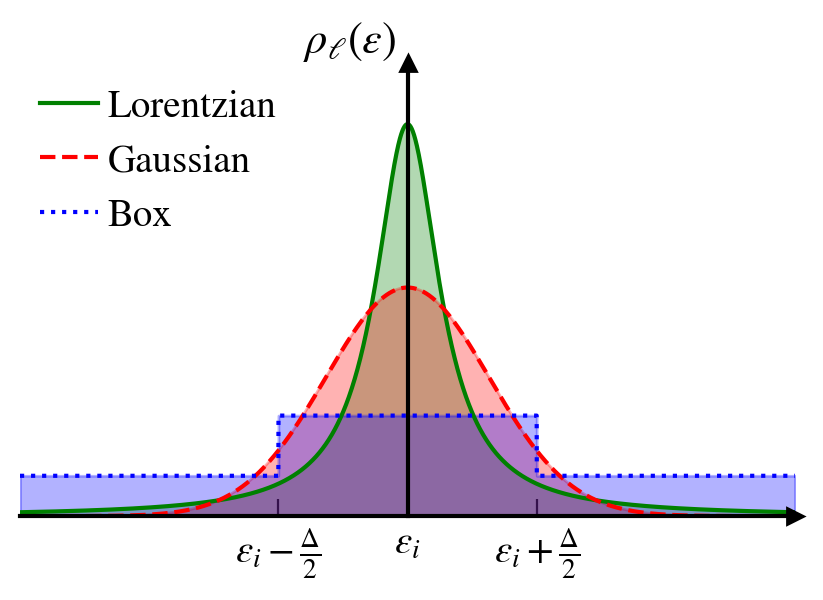

In [654]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

Gamma = 0.03
sigma = 0.002
x0 = 0.0

x = np.linspace(-1, 1, 10000)
# x = np.linspace(-0.3, 0.3, 10000)
curve1 = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve1 = curve1 / np.trapz(curve1, x)
axis.plot(x, curve1, color='green', label=r"Lorentzian")
axis.fill_between(x, 0, curve1, color='green', alpha=0.3)

x0 = -0.0
curve2 = 1 / np.sqrt(2*np.pi*sigma**2) * np.exp(-(x-x0)**2 / (2*sigma*2))
curve2 = curve2 / np.trapz(curve2, x)
axis.plot(x, curve2, color='red', ls='--', label=r"Gaussian")
axis.fill_between(x, 0, curve2, color='red', alpha=0.3)

x = np.linspace(-0.3, 0.3, 10000)
Gamma = 0.1
sig2 = 0.67
curve3 = (np.heaviside(Gamma - x,0) + np.heaviside(Gamma + x,0)) - 1 + sig2
curve3 = curve3 / np.trapz(curve3, x)
axis.plot(x, curve3, color='blue', ls=':', label=r"Box")
axis.fill_between(x, 0, curve3, color='blue', alpha=0.3)

fig_help.set_plot_elements(axis, ylabel=r"", xlabel=r"", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(axis, loc='upper left', fontsize=14)
axis.set_ylim(1e-6, 12.5)
axis.set_ylabel(r'$\rho_\ell(\epsilon)$', loc='top', rotation=0)
# axis.set_ylabel(r'$\left|c_\alpha(\epsilon_i)\right|^2$', loc='top', rotation=0)
axis.xaxis.set_label_coords(1, 0.15)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['left'].set_position('zero')
axis.spines['bottom'].set_visible(True)
axis.xaxis.set_ticks_position('bottom')
axis.yaxis.set_ticks_position('left')
axis.set_xticks([-Gamma, 0, Gamma])
axis.set_xticklabels([r"$\epsilon_i-\frac{\Delta}{2}$", r"$\epsilon_i$", r"$\epsilon_i+\frac{\Delta}{2}$"])
axis.set_yticks([])
axis.spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis.spines['bottom'].set_linewidth(1.5)  # Thicker x-axis

axis.set_xlim(-0.3, 0.3)
# axis.set_ylim(1e-1, 20)

# Add arrows at the ends of the axes
axis.plot(1, 0, ">k", transform=axis.get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis.plot(0, 1, "^k", transform=axis.get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
fig.savefig("figure.pdf", bbox_inches = 'tight', pad_inches=0.02)


In [550]:
alfac = 1/np.sqrt(2)
gammas = np.arange(1.2, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gammas - 1) * np.log(alfac**2) ) )

print(gammas, alfas)

[1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] [0.93303299 0.90125046 0.87055056 0.84089642 0.8122524  0.7845841
 0.75785828 0.73204285 0.70710678]


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


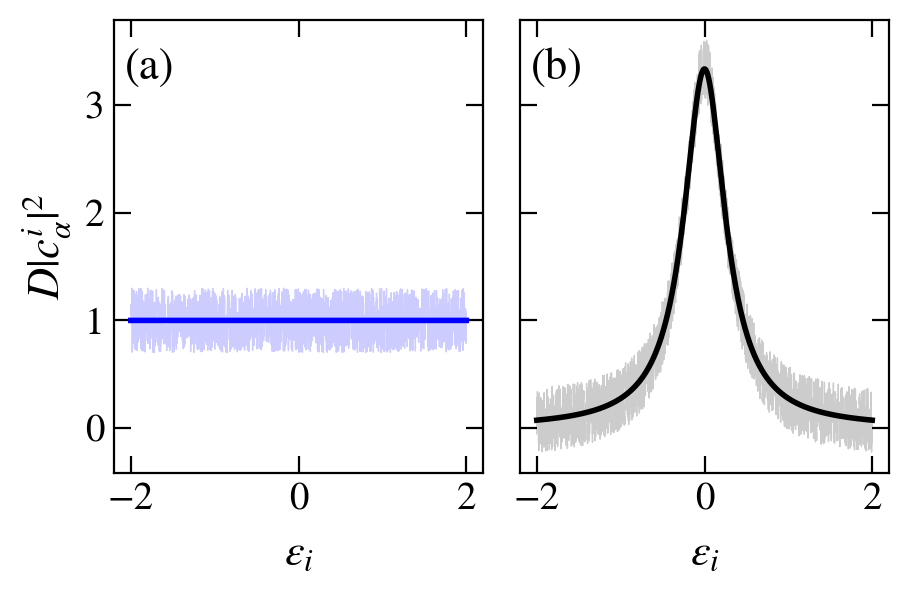

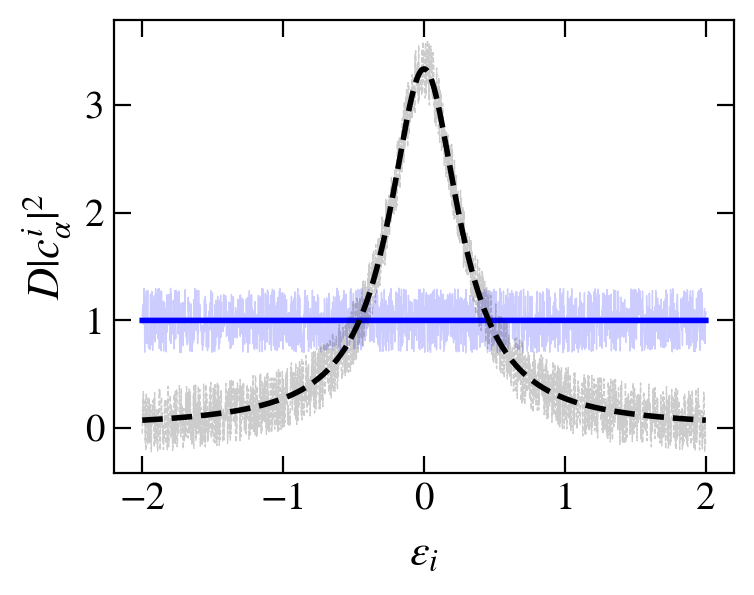

In [1591]:
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(5,3), dpi = 200, sharey = True)
fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharey = True)

Gamma = 0.3
sigma = 0.002
x0 = 0.
noise = 0.3

dim = 2**11

x = np.linspace(-2, 2, dim)

curve = np.ones(x.shape)
curve = curve / np.trapz(curve / (max(x) - min(x)), x)
axis[0].plot(x, curve, color='blue', ls='-', lw=2)
ax.plot(x, curve, color='blue', ls='-', lw=2)
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[0].scatter(x, fluct, s=1, color='blue', alpha=0.1)
axis[0].plot(x, fluct, lw=0.5, color='blue', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='blue', alpha=0.2)


curve = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve = curve / np.trapz(curve * np.exp(-x**2 / 2) / np.sqrt(2*np.pi), x)
axis[1].plot(x, curve, color='k', lw=2)
ax.plot(x, curve, color='k', lw=2, ls='--')
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[1].scatter(x, fluct, s=1, color='k', alpha=0.1)
axis[1].plot(x, fluct, lw=0.5, color='k', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='k', ls='--', alpha=0.2)

fig_help.set_plot_elements(axis[0], ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax, ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')

# axis.set_xlim(-0.3, 0.3)
# axis[0].set_ylim(0, 2)

fig.subplots_adjust(wspace = 0.1, hspace=0.05)
axis[0].annotate(r"(a)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')

fig.savefig("PLOTS_FADING/BEYOND_RMT/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)


## COMPARING UM AND RP

No handles with labels found to put in legend.


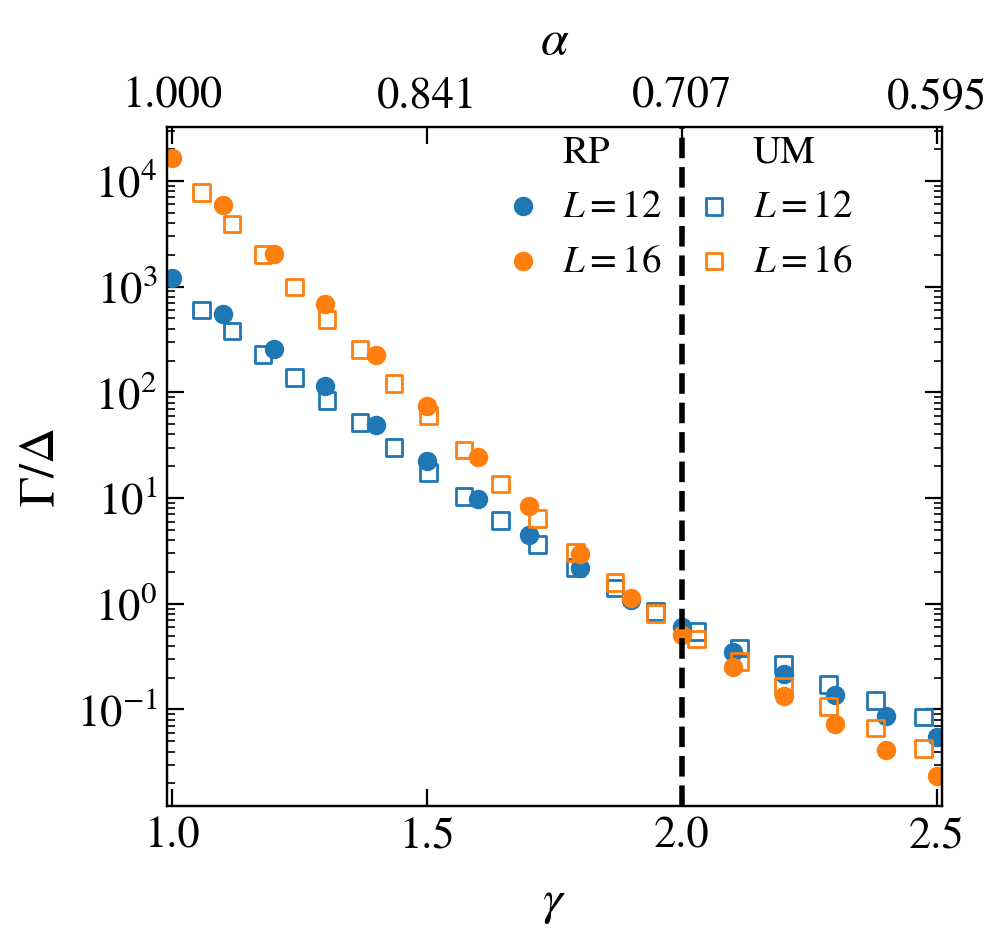

In [1436]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4.5), dpi = 200, sharex=False, sharey=False)

# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(1.0, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

handles = []
for L in [12, 16]:
    dim = 2**L
    col = next(colors_ls_cyc)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    E_th = np.zeros(gammas.shape)
    for iig, gx in enumerate(gammas):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-1]
                # dE  = np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # tH = 2 * np.pi / wH
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                # wH = dE / dim / 2 * np.pi
                
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                # xx = omegax#[indices]
                # yy = yy0#[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = omegax,
                #             ydata = yy0,
                #             maxfev = 20000)
                # G = np.abs(pars[-1])
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                E_th[iig] = G / wH * np.sqrt(1 + dim**(1-gx))
        else:
            print(name)
    line = axis.scatter(gammas, E_th, color = col, label=r"$L=%d$"%L)
    handles.append(line)
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfas = np.array(file.get('Sz/0/alphas/mean'))
            # indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
            # alfas = alfas[indices]
            
            _alfas_ = []
            _gammas_ = []
            E_th2 = []
            iicons = 0
            for iia, alfa in enumerate(alfas):
                if alfa >= 0.591 and alfa < 1:
                    idxa = np.argmin( np.abs(alfas - alfa) )
                    omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))
                    spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
                    
                    name_out2 = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
                    if exists(name_out2):
                        with h5py.File(name_out2, "r") as fileee:
                            alfasdasdas = np.array(fileee.get('alphas'))
                            idxa2 = np.argmin( np.abs(alfasdasdas - alfa) )
                            wH = np.array(fileee.get('mean_lvl/1.00/mean'))[idxa2]
                            dE = np.array(fileee.get('bandwidth/mean'))[idxa2]
                            dE = np.array(fileee.get('variance/1.00/mean'))[idxa2]
                            # wH = dE / dim
                            # print(L, alfa, sig)
                    else:
                        print(name_out2)
                         
                    # wH = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                    xx = omegas
                    yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    idxG = np.argmin( np.abs(yy - 0.5) )
                    E_th2.append( omegas[1:][idxG] / wH * dE)
                    _gammas_.append(1 + np.log(alfa**2) / np.log(alfac**2))
                    _alfas_.append(alfa)
                    
                
            # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
            line = axis.scatter(_gammas_, E_th2, color=col, facecolor='None', marker='s', label=r"$L=%d$"%L)
            handles.append(line)
    else:
        print(name_out)
        
    _alfas_ = np.array(_alfas_) 
    # axis.plot(gammas, dim**(1-gammas) )
axis.set_xlim(0.99, 2.51)
# axis.set_ylim(1e-3, 3e4)

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$\Gamma/\Delta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_legend(axis, fontsize=14, loc='upper right', anchor=(0.93, 1.04), ncol = 2, handles = _handle_shit, columnspacing=0.6)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

fig.subplots_adjust(wspace = 0.1, hspace=0.34)


No handles with labels found to put in legend.


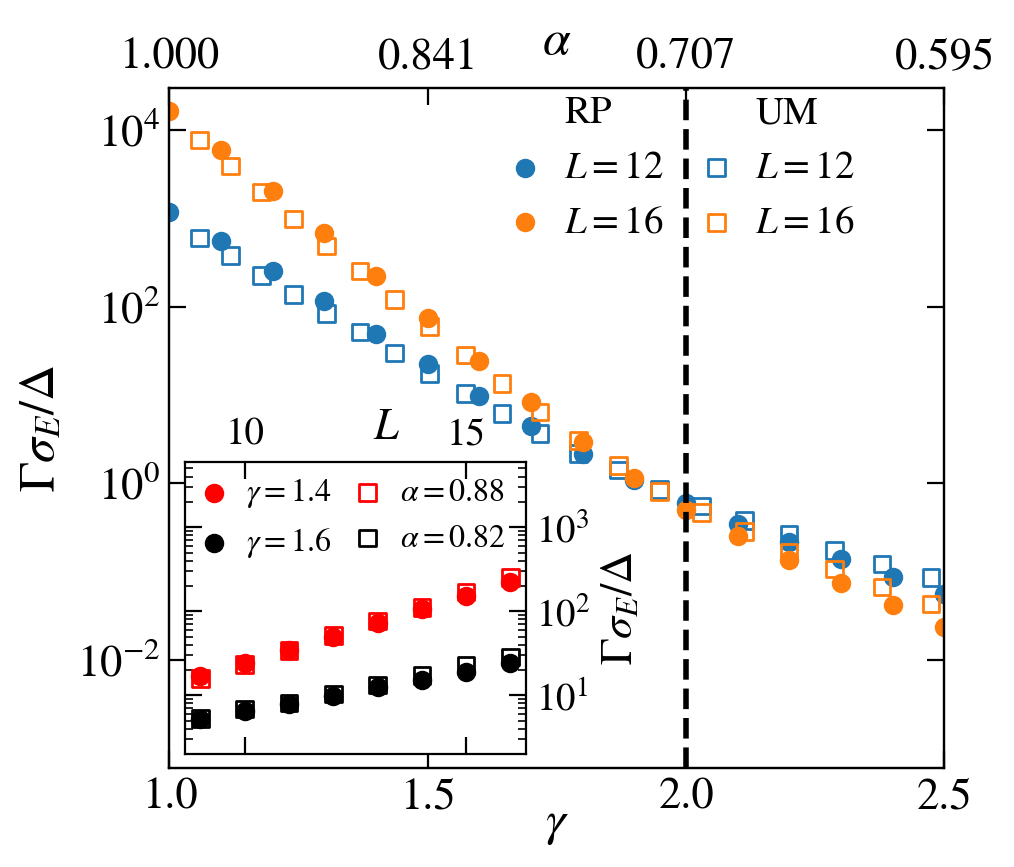

In [1794]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4.5), dpi = 200, sharex=False, sharey=False)
inset = axis.inset_axes([0.02, 0.02, 0.44, 0.43])
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(1.0, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

handles = []
for L in [12, 16]:
    dim = 2**L
    col = next(colors_ls_cyc)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    E_th = np.zeros(gammas.shape)
    for iig, gx in enumerate(gammas):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-1]
                dE  = np.mean(np.array(file.get('stddev')))#np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # tH = 2 * np.pi / wH
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                # wH = dE / dim / 2 * np.pi
                
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.mean(np.array(file.get('stddev')))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                # xx = omegax#[indices]
                # yy = yy0#[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = omegax,
                #             ydata = yy0,
                #             maxfev = 20000)
                # G = np.abs(pars[-1])
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                # E_th[iig] = G / wH /dE
                E_th[iig] = G / wH * sig
                # E_th[iig] = G / wH
        else:
            print(name)
    line = axis.scatter(gammas, E_th, color = col, label=r"$L=%d$"%L)
    handles.append(line)
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfas = np.array(file.get('Sz/0/alphas/mean'))
            # indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
            # alfas = alfas[indices]
            
            _alfas_ = []
            _gammas_ = []
            E_th2 = []
            iicons = 0
            for iia, alfa in enumerate(alfas):
                if alfa >= 0.591 and alfa < 1:
                    idxa = np.argmin( np.abs(alfas - alfa) )
                    omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))
                    spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
                    
                    name_out2 = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
                    if exists(name_out2):
                        with h5py.File(name_out2, "r") as fileee:
                            alfasdasdas = np.array(fileee.get('alphas'))
                            idxa2 = np.argmin( np.abs(alfasdasdas - alfa) )
                            wH = np.array(fileee.get('mean_lvl/1.00/mean'))[idxa2]
                            dE = np.array(fileee.get('bandwidth/mean'))[idxa2]
                            sig = np.array(fileee.get('variance/1.00/mean'))[idxa2]
                            # wH = dE / dim
                            # print(L, alfa, sig)
                    else:
                        print(name_out2)
                         
                    # wH = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                    xx = omegas
                    yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    idxG = np.argmin( np.abs(yy - 0.5) )
                    E_th2.append( omegas[1:][idxG] / wH * sig)
                    # E_th2.append( omegas[1:][idxG] / wH)
                    # E_th2.append( omegas[1:][idxG] / dE * sig)
                    
                    _gammas_.append(1 + np.log(alfa**2) / np.log(alfac**2))
                    _alfas_.append(alfa)
                    
                
            # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
            line = axis.scatter(_gammas_, E_th2, color=col, facecolor='None', marker='s', label=r"$L=%d$"%L)
            handles.append(line)
    else:
        print(name_out)
        
    _alfas_ = np.array(_alfas_) 
    # axis.plot(gammas, dim**(1-gammas) )
axis.set_xlim(1, 2.5)
axis.set_ylim(6e-4, 3e4)

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$\Gamma\sigma_E/\Delta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_legend(axis, fontsize=14, loc='upper right', anchor=(0.93, 1.04), ncol = 2, handles = _handle_shit, columnspacing=0.6)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

s_m_g = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(gammas), vmax=max(gammas)))
s_m_g.set_array([])

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=min(_alfas_), vmax=max(_alfas_)))
s_m_a.set_array([])

gammas = [1.4, 1.6]
handles = []
for iig, gx in enumerate(gammas):
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    
    E_th_RP = np.zeros(sizes.shape)
    E_th_UM = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        dim = 2**L
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                wH        = np.array(file.get('wH'))[-1]
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                
                tH        = 2 * np.pi / wH
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.mean(np.array(file.get('stddev')))# np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # wH = dE / dim
                
                omegax = np.array(file.get('omegas'))# / wH
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                
                # E_th_RP[iiL] = xx[1:][idxG] / wH
                E_th_RP[iiL] = xx[1:][idxG] / wH * sig
                # E_th_RP[iiL] = xx[1:][idxG] / dE * sig
        # ------------------------------------------------------------ ULTRAMETRIC MODEL
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                wH = np.array(file.get('mean_lvl/1.00/mean'))[idxa]
                dE = np.array(file.get('bandwidth/mean'))[idxa]
                sig = np.array(file.get('variance/1.00/mean'))[idxa]
                # print(L, alfa, sig)
        else:
            print(name_out)
            
        name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 1e-2:
                    print(alfa, name_out)
                    continue
                alfax = _alfas_[idxa]
                E_th        = np.array(file.get('Sz/0/gamma/mean'))
                # wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                # tH        = 2 * np.pi / wH
                # idxa = np.argmin( np.abs(E_th - G) )
                # print(alfa, _alfas_[idxa])
                E_th = E_th[idxa]
                omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                xx = omegas
                yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                # E_th_UM[iiL] = omegas[1:][idxG] / wH
                E_th_UM[iiL] = omegas[1:][idxG] / wH * sig
                # E_th_UM[iiL] = omegas[1:][idxG] / dE * sig
        else:
            print(name_out)
    col = 'k' if iig else 'red'
    line = inset.scatter(sizes, E_th_RP, color=col, label=r"$\gamma=%g$"%gx)
    handles.append(line)
    
    line = inset.scatter(sizes, E_th_UM, marker='s', color=col, facecolor='None', label=r"$\alpha=%g$"%alfax)
    handles.append(line)


# line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
# handles.append(line)
# line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
# handles.append(line)
indices = np.array([0,2, 1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )  
inset.xaxis.set_label_coords(0.59, 1.08)

axis.xaxis.set_label_coords(.5, -0.05)
axis2.xaxis.set_label_coords(.5, 1.05)
inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
inset.yaxis.set_ticks_position('right')
inset.yaxis.set_label_position('right')

inset.set_ylim(2e0, 6e3)
fig_help.set_plot_elements(inset, ylabel=r"$\Gamma\sigma_E/\Delta$", xlabel=r"$L$", font_size=14, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(inset, fontsize=11.5, loc='upper left', anchor=(-0.07, 1.05), ncol = 2, handles = _handle_shit, columnspacing=0.4)
# inset.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))
# inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))

fig.subplots_adjust(wspace = 0.1, hspace=0.34)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)


No handles with labels found to put in legend.


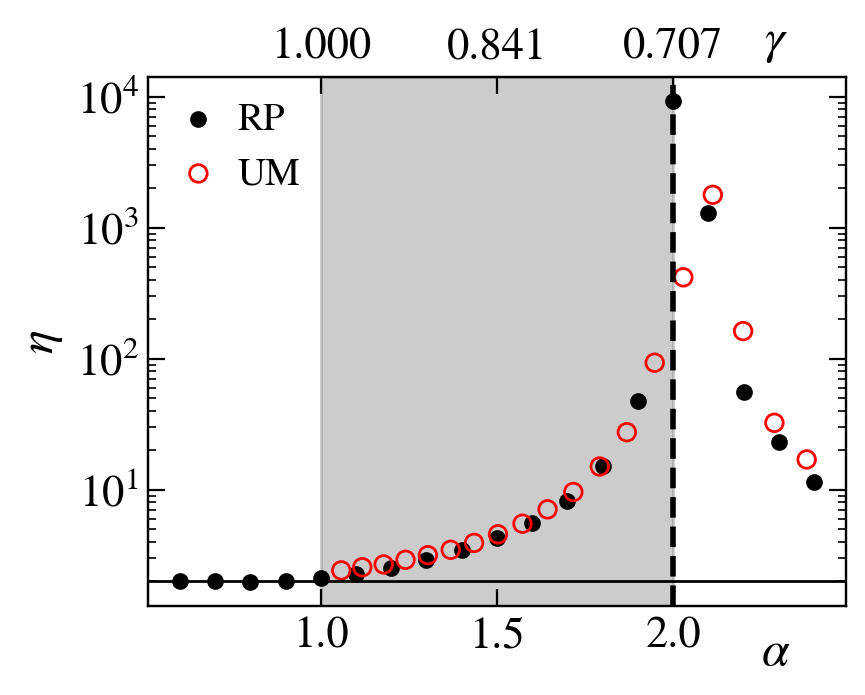

In [1498]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(6, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(0.6, 2.5, 0.1)

ymin = 1e6
axis2 = axis.twiny()

# ------------------------------------------------------------ ROZENZWEIG-PORTER
def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-eta)

etaRP = np.zeros(gammas.shape)
for iig, gx in enumerate(gammas):
    DOS = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for iiL, L in enumerate( sizes ):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
                _DOS = np.array(file.get('DOS'))[idx]
                DOS[iiL] = _DOS
                wHx = np.array(file.get('wH_density'))[idx]
                yy0 = spec_fun
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wHx * G)))
                
                spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[ max(0, idx_spec - 20) : min(idx_spec + 20, yy0.size)]) )
        else:
            print(name)
    DOS = DOS[~np.isnan(spec_at_wH_G)]
    sizes = sizes[~np.isnan(spec_at_wH_G)]
    spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]

    pars, pconv= fit(matelem_fit,
                xdata = DOS[-4:],
                ydata = spec_at_wH_G[-4:],
                maxfev = 20000)
    etaRP[iig] = 1 / np.abs(pars[-1])
    # a1 = -1 / ( (np.log(spec_at_wH_G[-1]) - np.log(spec_at_wH_G[-2])) / (np.log(DOS[-1]) - np.log(DOS[-2])) )
    # a2 = -1 / ( (np.log(spec_at_wH_G[-2]) - np.log(spec_at_wH_G[-3])) / (np.log(DOS[-2]) - np.log(DOS[-3])) )
    # etaRP[iig] = (a1 + a2)/2
axis.scatter(gammas, etaRP, label=r"RP", zorder=0, color='k', s=25)
    
# ------------------------------------------------------------ ULTRAMETRIC MODEL
name_out = "./UM results/SpectralFun/etas.h5"
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        alfas = np.array(file.get('Sz/0/etas/mean'))[:, 0]
        _gammas_ = 1 + np.log(alfas**2) / np.log(alfac**2)
        
        etas = np.array(file.get('Sz/0/etas/mean'))[:, 1]
        indices = np.argwhere( np.logical_and(alfas >= 0.617, alfas < 1.1) )
        axis.scatter(_gammas_[indices], etas[indices], label=r"UM", zorder=1, color='red', facecolor='None', s=40)
        
else:
    print(name_out)
        

axis.axvline(x=2, ls='--', color='k', lw=2)
axis.axvspan(xmin=1, xmax=2, color='gray', alpha=0.4, zorder=-1)
axis.axhline(y=2, ls='-', color='k', lw=1)

fig_help.set_plot_elements(axis, ylabel=r"$\eta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, loc='upper left', fontsize=14)

fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

axis.xaxis.set_label_coords(.9, 1.11)
axis2.xaxis.set_label_coords(.9, -0.11)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.9012504626108302 10.657132148742676
16 0.8705505632961241 10.165755271911621


No handles with labels found to put in legend.


16 0.8408964152537145 9.769786834716797


No handles with labels found to put in legend.


16 0.8122523963562355 9.496708869934082
16 0.7845840978967507 9.137992858886719


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.757858283255199 9.036253929138184
16 0.7320428479728127 8.820806503295898


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.7071067811865475 8.627921104431152


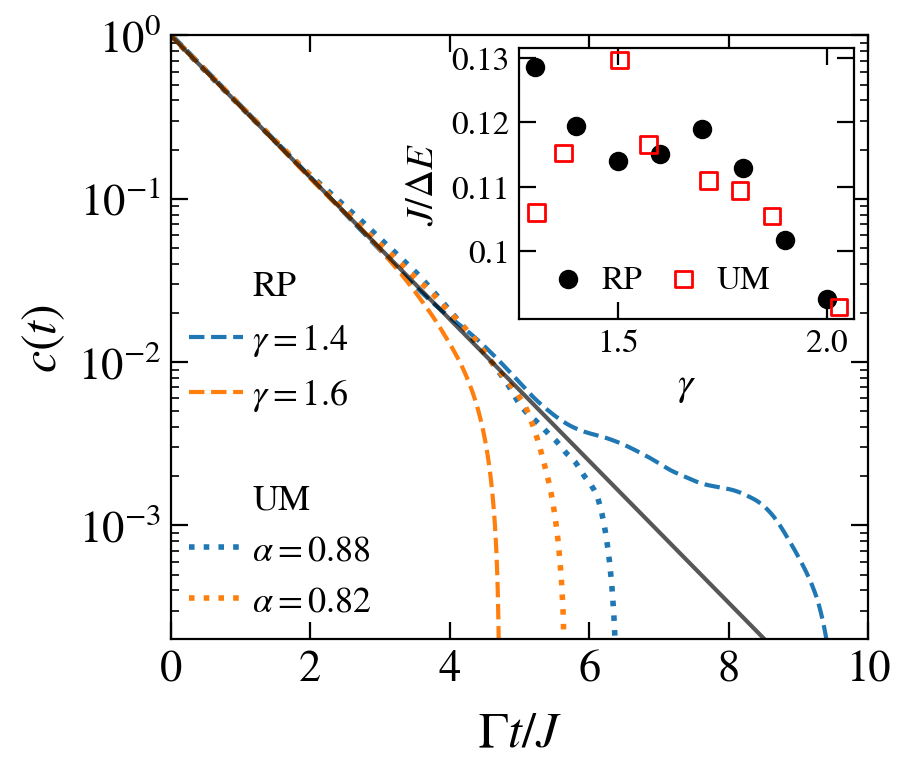

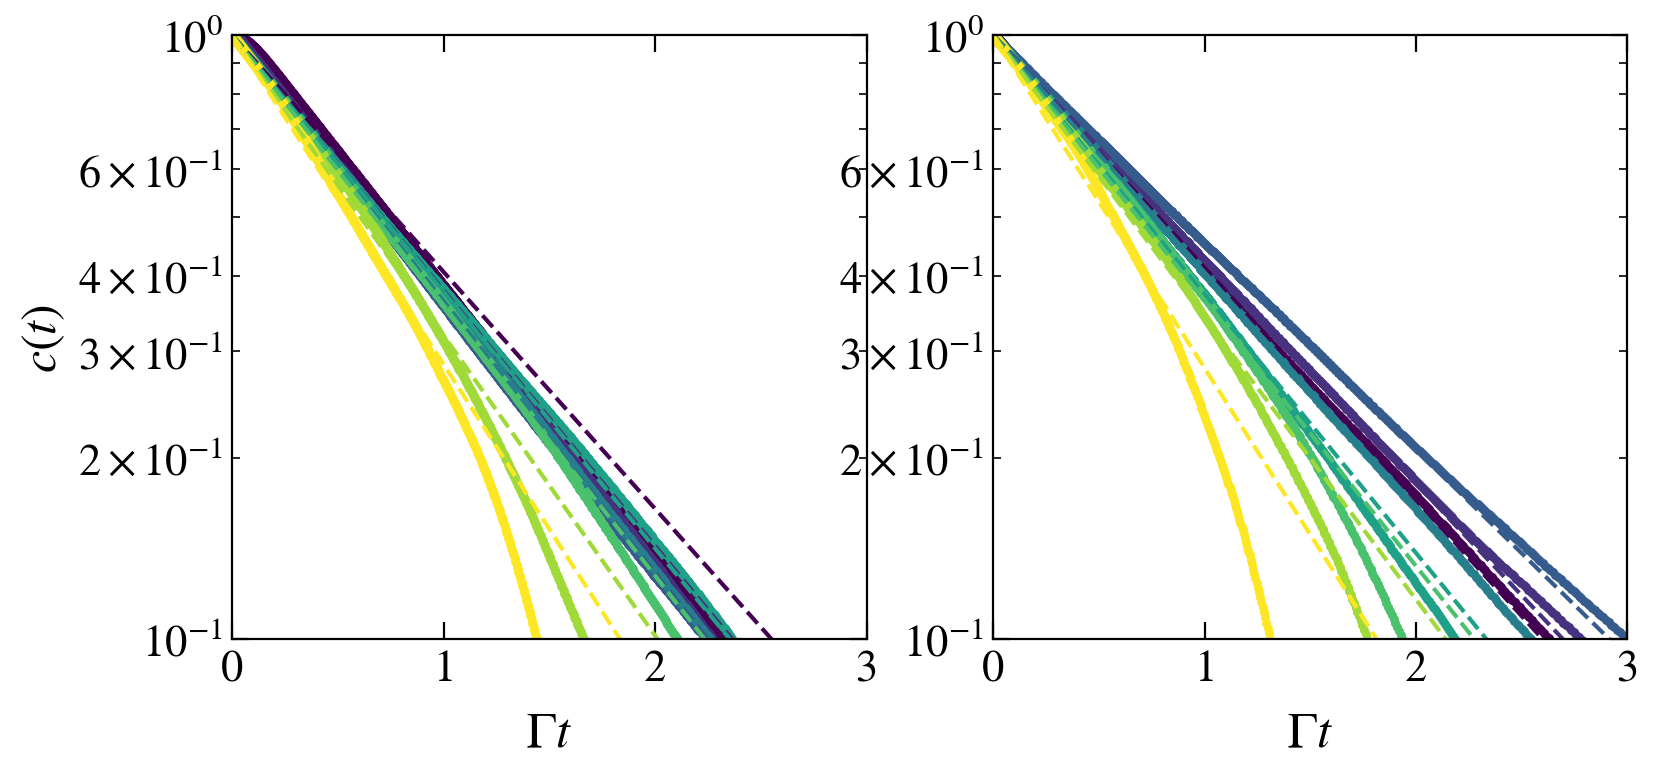

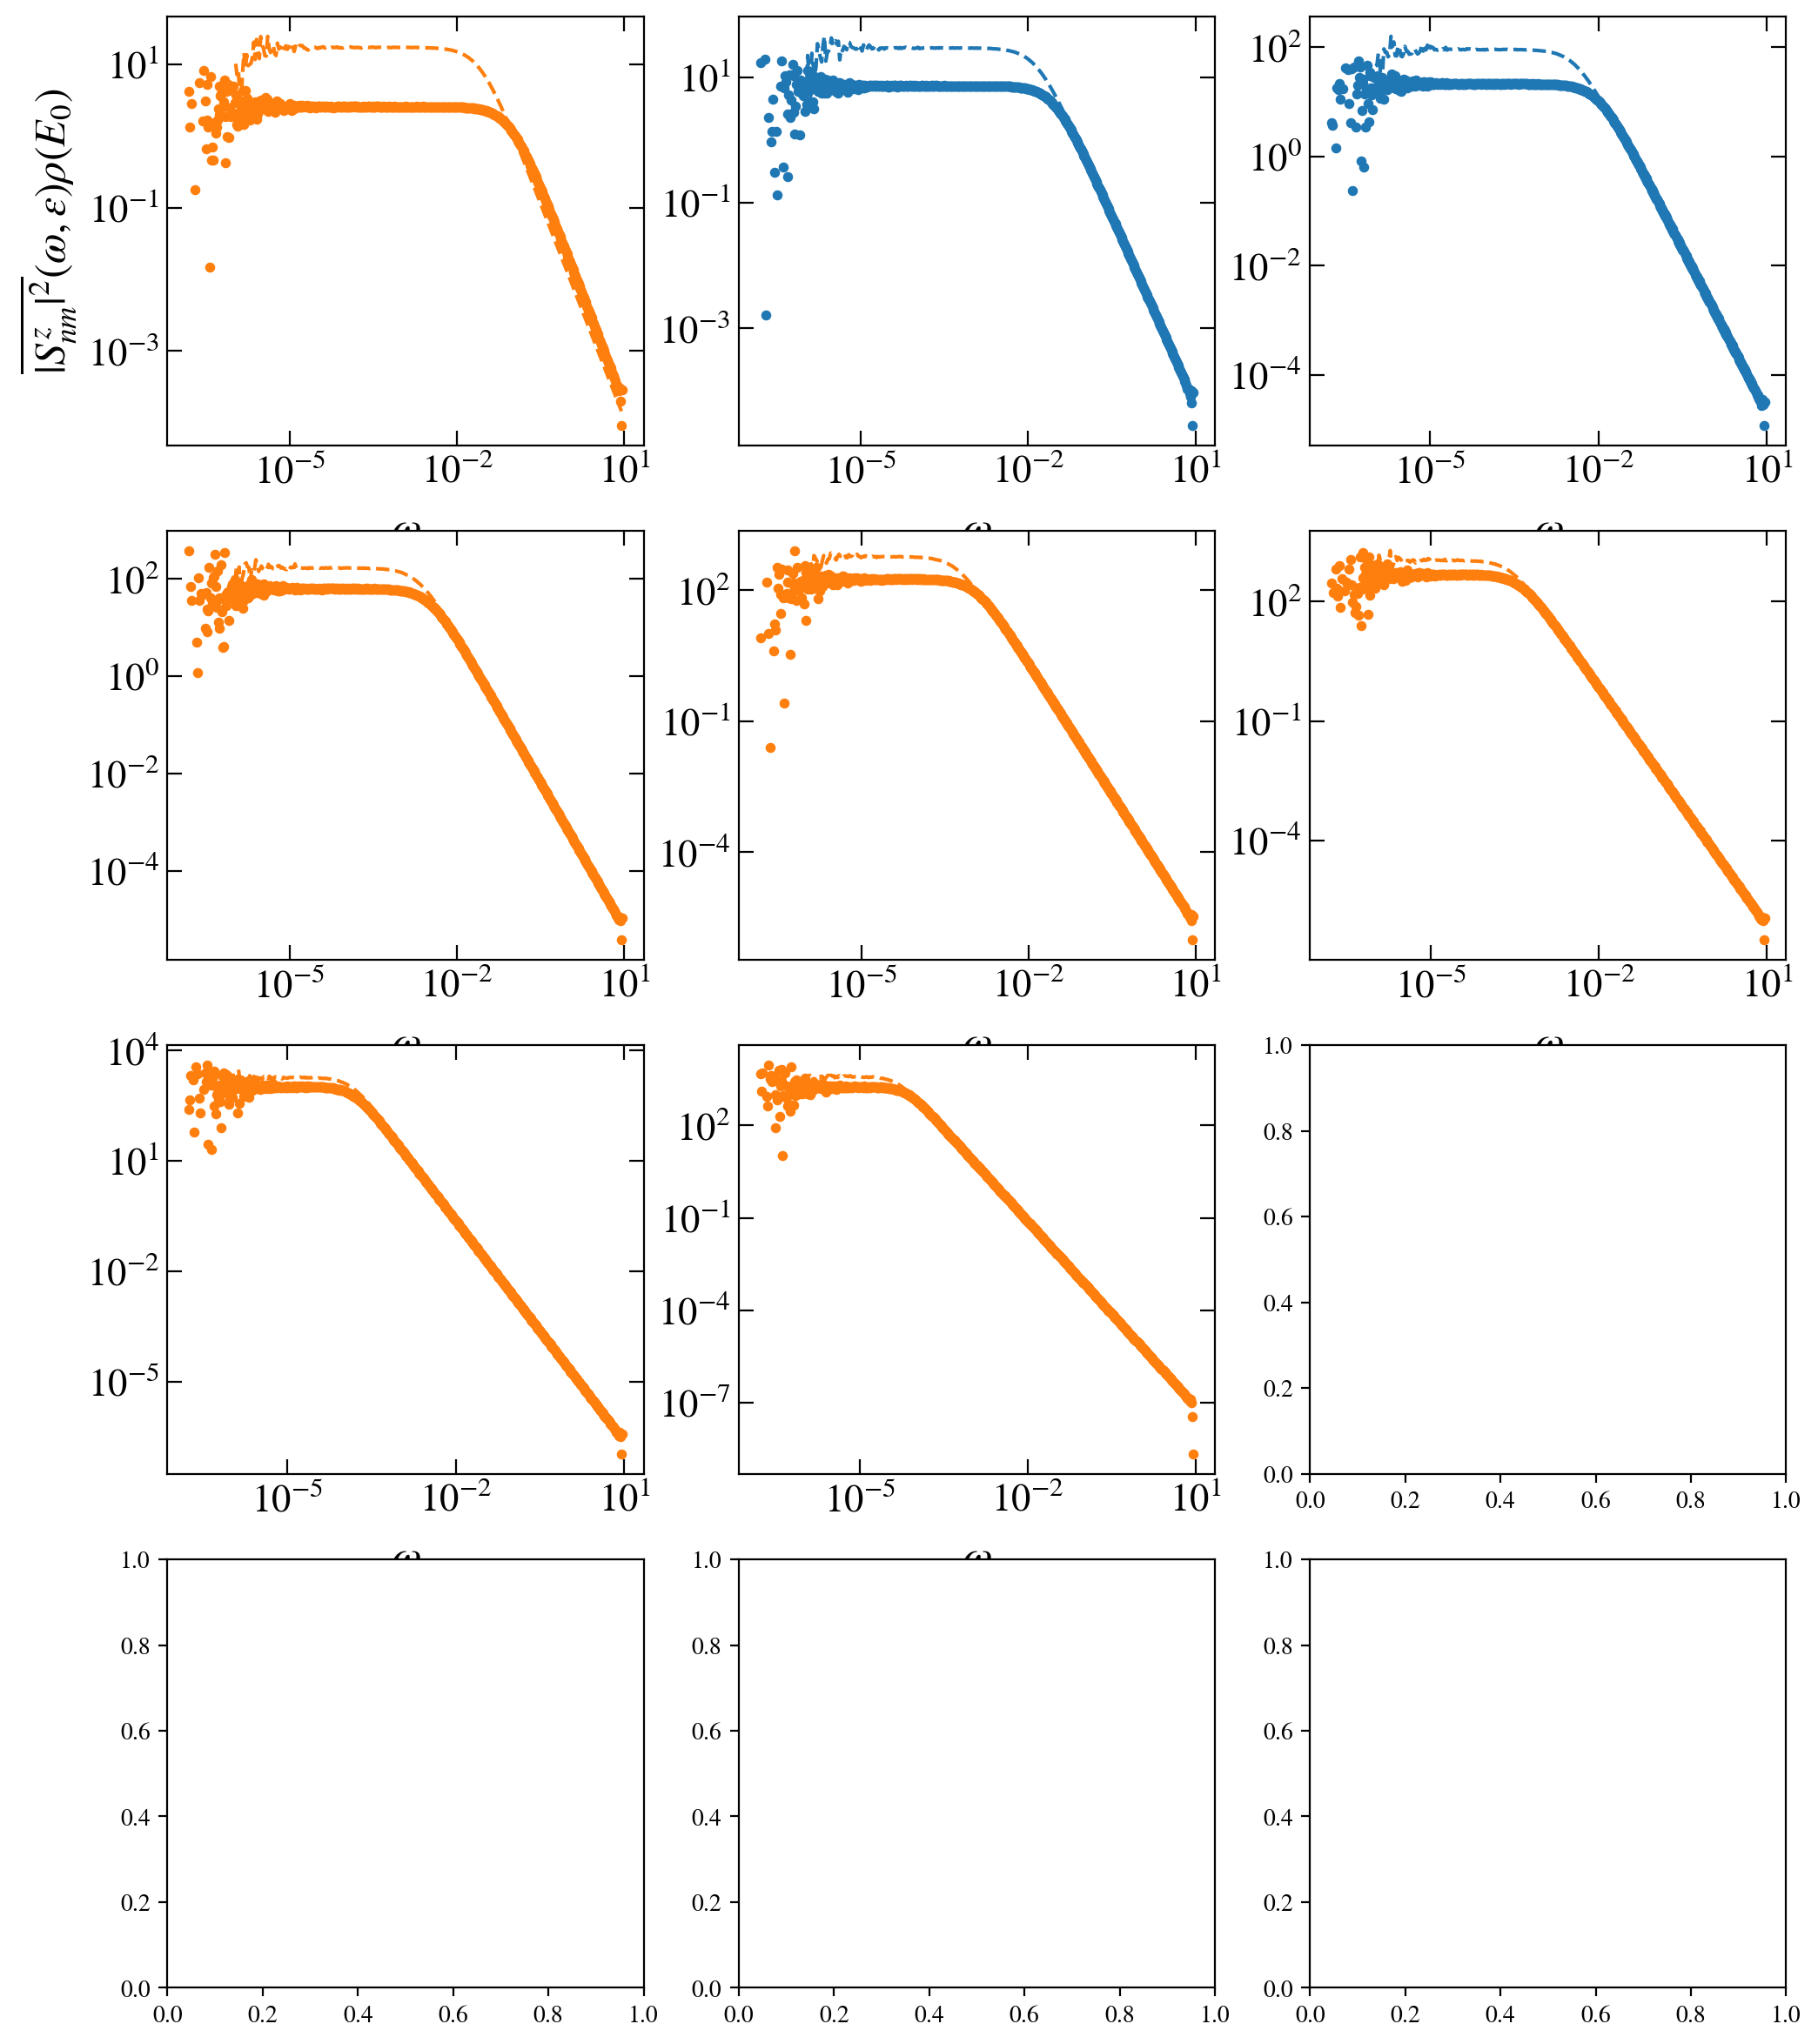

In [1500]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(7, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 200, sharex=False, sharey=False)

fig_test, axis_test = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200, sharex=False, sharey=False)
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])


fig2, axis2 = plt.subplots( nrows=4, ncols=3, figsize=(12,15), dpi = 200, sharex=False, sharey=False)
axis2 = axis2.flatten()

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)


r_idx = 5
corr = 0
gx = 1.5
window = 80

L = 16
eps = 0.5
alfac = 1/np.sqrt(2)

gamma_vals = np.arange(1.3, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gamma_vals - 1) * np.log(alfac**2) ) )
dim = 2**L

def funn(obs, DE):
    return (obs - DE) / (obs[0] - DE)
    # return obs / obs[0]

con = 0.115

ymin = 1e6

handles = []

def exp_fit(x, J):
    """Exponential function to fit and find decay rate"""
    return np.exp(- x / J)

norm = matplotlib.colors.Normalize(
        vmin=min(gamma_vals),
        vmax=max(gamma_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])
# for iig, gx in enumerate([1.4, 1.6]):

energy_scale_RP = []
energy_scale_UM = []
_gammas_ = []
for iig, gx in enumerate(gamma_vals):
    gx = np.round(gx, 1)
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    if gx == 1.4 or gx == 1.6:
        col = next(colors_ls_cyc)
    col2 = s_m.to_rgba(gx)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            wH        = np.array(file.get('wH'))[-2]
            tH        = 2 * np.pi / wH
            
            omegax = np.array(file.get('omegas'))# / wH
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx]
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
            yy0 = spec_fun * 2**L
            
            omegax = omegax[~np.isnan(yy0)]
            spec_fun = spec_fun[~np.isnan(yy0)]
            spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            axis2[iig].scatter(omegax, yy0, color=col, s=10)
            xx = omegax
            yy = integrate.cumulative_trapezoid(yy0, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            
            dE  = np.mean( np.array(file.get('bandwidth')) )
            # dE  = wH * dim
            G = xx[1:][idxG]#np.sqrt(1 + dim**(1-gx))
            
    else:
        print(name)       
    
    name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            times    = np.array(file.get('TIMES/L=%d'%L))# / tH
            quench = np.array(file.get('QUENCH/L=%d'%L))
            autocorr = np.array(file.get('AUTOCORR/L=%d'%L))
            
            quench = tools.remove_fluctuations(quench, bucket_size=window)[window//2:-window//2]
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            DE = np.mean(obs[-1000 : -100])
            obs = funn(obs, DE)
            
            indices = (obs > 0.01)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G)[indices],
                            ydata = obs[indices],
                            full_output=True, maxfev=10000)
            
            axis_test[0].scatter((times * G)[indices], obs[indices], color=col2, s = 5)
            x = np.linspace(0, 10, 1000)
            axis_test[0].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            energy_scale_RP.append(pars[0] / dE)
            
            if gx == 1.4 or gx == 1.6:
                line, = axis.plot((times * G) / dE / con, obs, color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx)
                handles.append(line)
            # if np.min( np.abs(obs[times < 10/wH/G]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G]) )
    else:
        print(name_out)
    
    
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            E_th        = np.array(file.get('Sz/0/gamma/mean'))
            wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
            tH        = 2 * np.pi / wH
            # idxa = np.argmin( np.abs(E_th - G) )
            # print(alfa, _alfas_[idxa])
            E_th = E_th[idxa]
            omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]# / wH
            spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
            axis2[iig].plot(omegas, spec_fun, color=col, ls='--')
            xx = omegas
            yy = integrate.cumulative_trapezoid(spec_fun, omegas)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G_UM = omegas[1:][idxG]
            # print(alfa, _alfas_[idxa], G, G_UM, E_th)
    else:
        print(name_out)
        
    name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            # sig = np.array(file.get('variance/1.00/mean'))[idxa]
            sig = np.array(file.get('bandwidth/mean'))[idxa]
            # sig = np.array(file.get('mean_lvl/0.50/mean'))[idxa] * dim
            print(L, alfa, sig)
    else:
        print(name_out)
            
    name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            times = np.array(file.get('Sz/0/ME/autocorr/%d/times'%(idxa) ))# / tH
            autocorr = np.array(file.get('Sz/0/ME/autocorr/%d/mean'%(idxa) )) / 4
            
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            DE = np.mean(obs[-1000 : -100])
            obs = funn(obs, DE)
            
            indices = (obs > 0.01)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G_UM)[indices],
                            ydata = obs[indices],
                            full_output=True, maxfev=10000)
            
            axis_test[1].scatter((times * G_UM)[indices], obs[indices], color=col2, s = 5)
            x = np.linspace(0, 10, 1000)
            axis_test[1].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            _gammas_.append(1 + np.log(_alfas_[idxa]) / np.log(alfac))
            energy_scale_UM.append(pars[0] / sig)
            
            if gx == 1.4 or gx == 1.6:
                # DE = np.array(file.get('Sz/0/ME/stat/lt/ac/typical' ))[idxa]
                line, = axis.plot((times * G_UM) / sig / con, obs, color=col, ls=':', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]))
                handles.append(line)
            
            # if np.min( np.abs(obs[times < 10/wH/G_UM]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G_UM]) )
    else:
        print(name_out)
    
    fig_help.set_plot_elements(axis2[iig], ylabel=r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)\rho(E_0)$" if iig==0 else "", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"$\ $")
handles.append(line)
indices = np.array([5,0,2, 6, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    
fig_help.set_plot_elements(axis, ylabel=r"$c(t)$", xlabel=r"$\Gamma t/J$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=13, loc='lower left', ncol = 1, handles = _handle_shit, columnspacing=0.5)
axis.set_xlim(0, 10)

times = np.linspace(0, 10, 1000)
axis.plot(times, np.exp(-times), ls='-', color='k', alpha=0.66)
# axis.plot(times, np.exp(-0.9*times), ls='-', color='red', alpha=0.5)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')
axis.set_ylim(2e-4, 1)
cbar = None

inset = axis.inset_axes([0.5, 0.53, 0.48, 0.45])
inset.scatter(gamma_vals, energy_scale_RP, color='k', marker='o', label=r"RP")
inset.scatter(_gammas_, energy_scale_UM, color='red', marker='s', facecolor='None', label=r"UM")
fig_help.set_plot_elements(inset, ylabel=r"$J/\Delta E$", xlabel=r"$\gamma$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='lower left', ncol = 2, columnspacing=0.5)
inset.set_yticks([0.1, 0.11, 0.12, 0.13])
inset.set_yticklabels(["0.1", "0.11", "0.12", "0.13"])
inset.minorticks_off()

fig.subplots_adjust(wspace = 0.1, hspace=0.17)

fig_help.set_plot_elements(axis_test[0], ylabel=r"$c(t)$", xlabel=r"$\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis_test[0].set_xlim(0, 3)
axis_test[0].set_ylim(1e-1, 1)
fig_help.set_plot_elements(axis_test[1], ylabel=r"", xlabel=r"$\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis_test[1].set_xlim(0, 3)
axis_test[1].set_ylim(1e-1, 1)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# DIVIDE Gamma / J, J = bandwidth, if does not work find prefactor which can be different for both models

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
1.0 3.645164537452073 0.9549296585513722
1.1 3.316595284552252 0.9549296585513722
1.2000000000000002 2.5607270621172322 0.9549296585513722
1.3000000000000003 1.7859291583953094 0.9549296585513722
1.4000000000000004 1.252741342068969 0.9549296585513722
1.5000000000000004 1.0290587852046646 0.9549296585513722
1.6000000000000005 0.8790151464158785 0.9549296585513722
1.7000000000000006 0.7622182785094404 0.9549296585513722
1.8000000000000007 0.6944813611383358 0.9549296585513722
1.9000000000000008 0.4506988636278627 0.9549296585513722
2.000000000000001 0.3267194790046762 0.9549296585513722
RP:  AAAA [ 1.00011705  0.97296472  0.89833937  0.78143246  0.65469198  0.53340568
  0.41906588  0.2891699   0.16902522  0.04312466 -0.05114788]
RP:  BBBB [ 0.99537752  0.94974986  0.86440668  0.74801062  0.61984562  0.50379367
  0.38958492  0.27772498  0.1772451   0.05137283 -0.03944023]


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


UM:  AAAA [0.40479093 0.51045686 0.6120673  0.7836408  0.80652228 0.88369917
 0.9417856  0.95259137 0.9840514  1.01458821 1.00280755 1.00553702
 1.00017589 0.98718047 0.99829326]
UM:  BBBB [0.49541389 0.64513024 0.78229527 0.88524801 0.93936452 0.98593269
 1.00539354 1.01227272 1.01467037 1.01729144 1.01717297 1.0169908
 1.01651885 1.01552675 1.01558931]


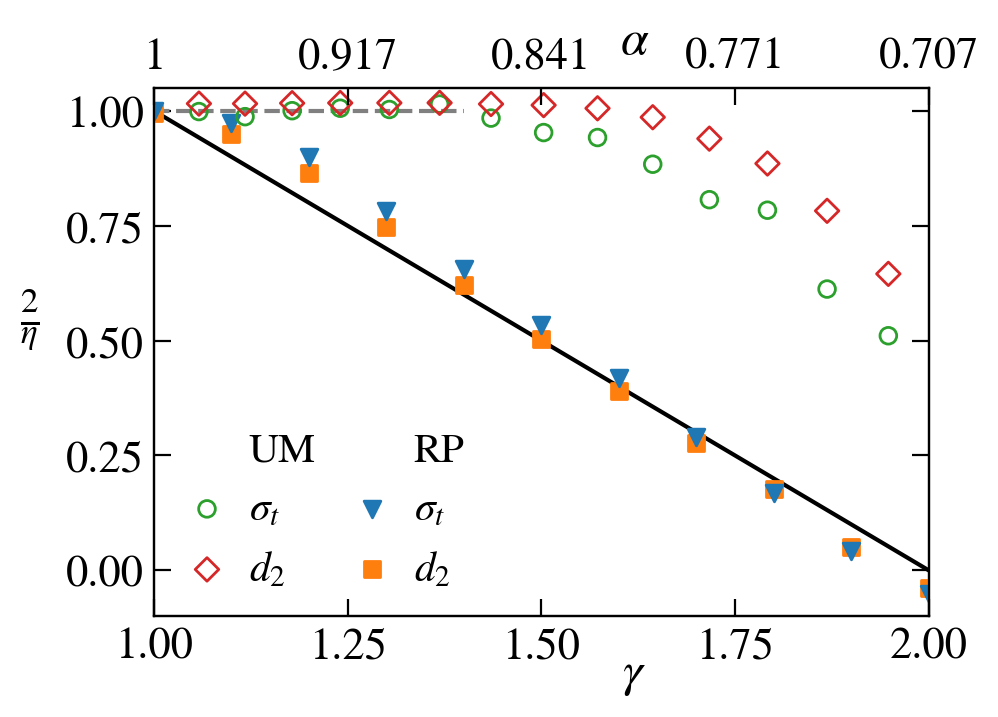

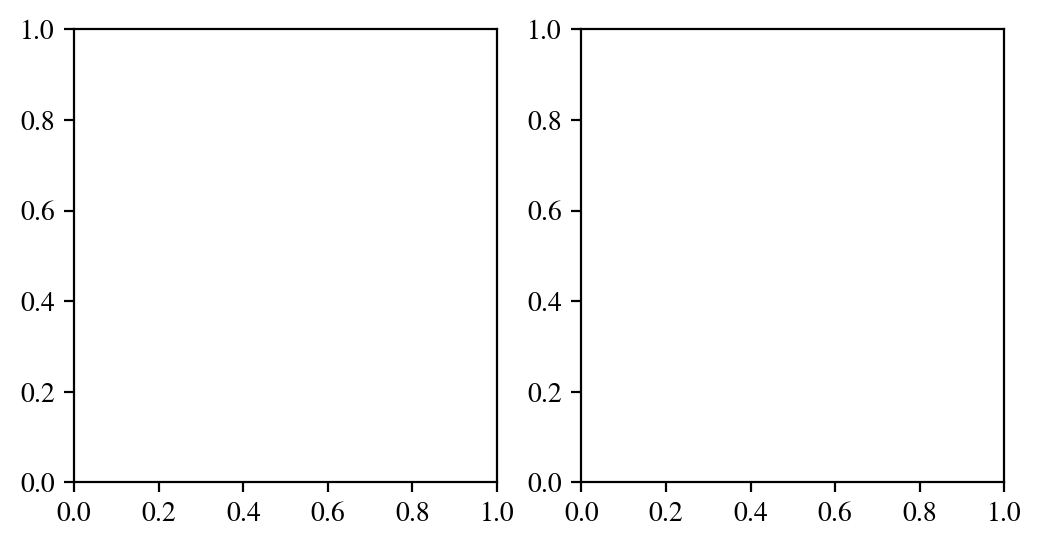

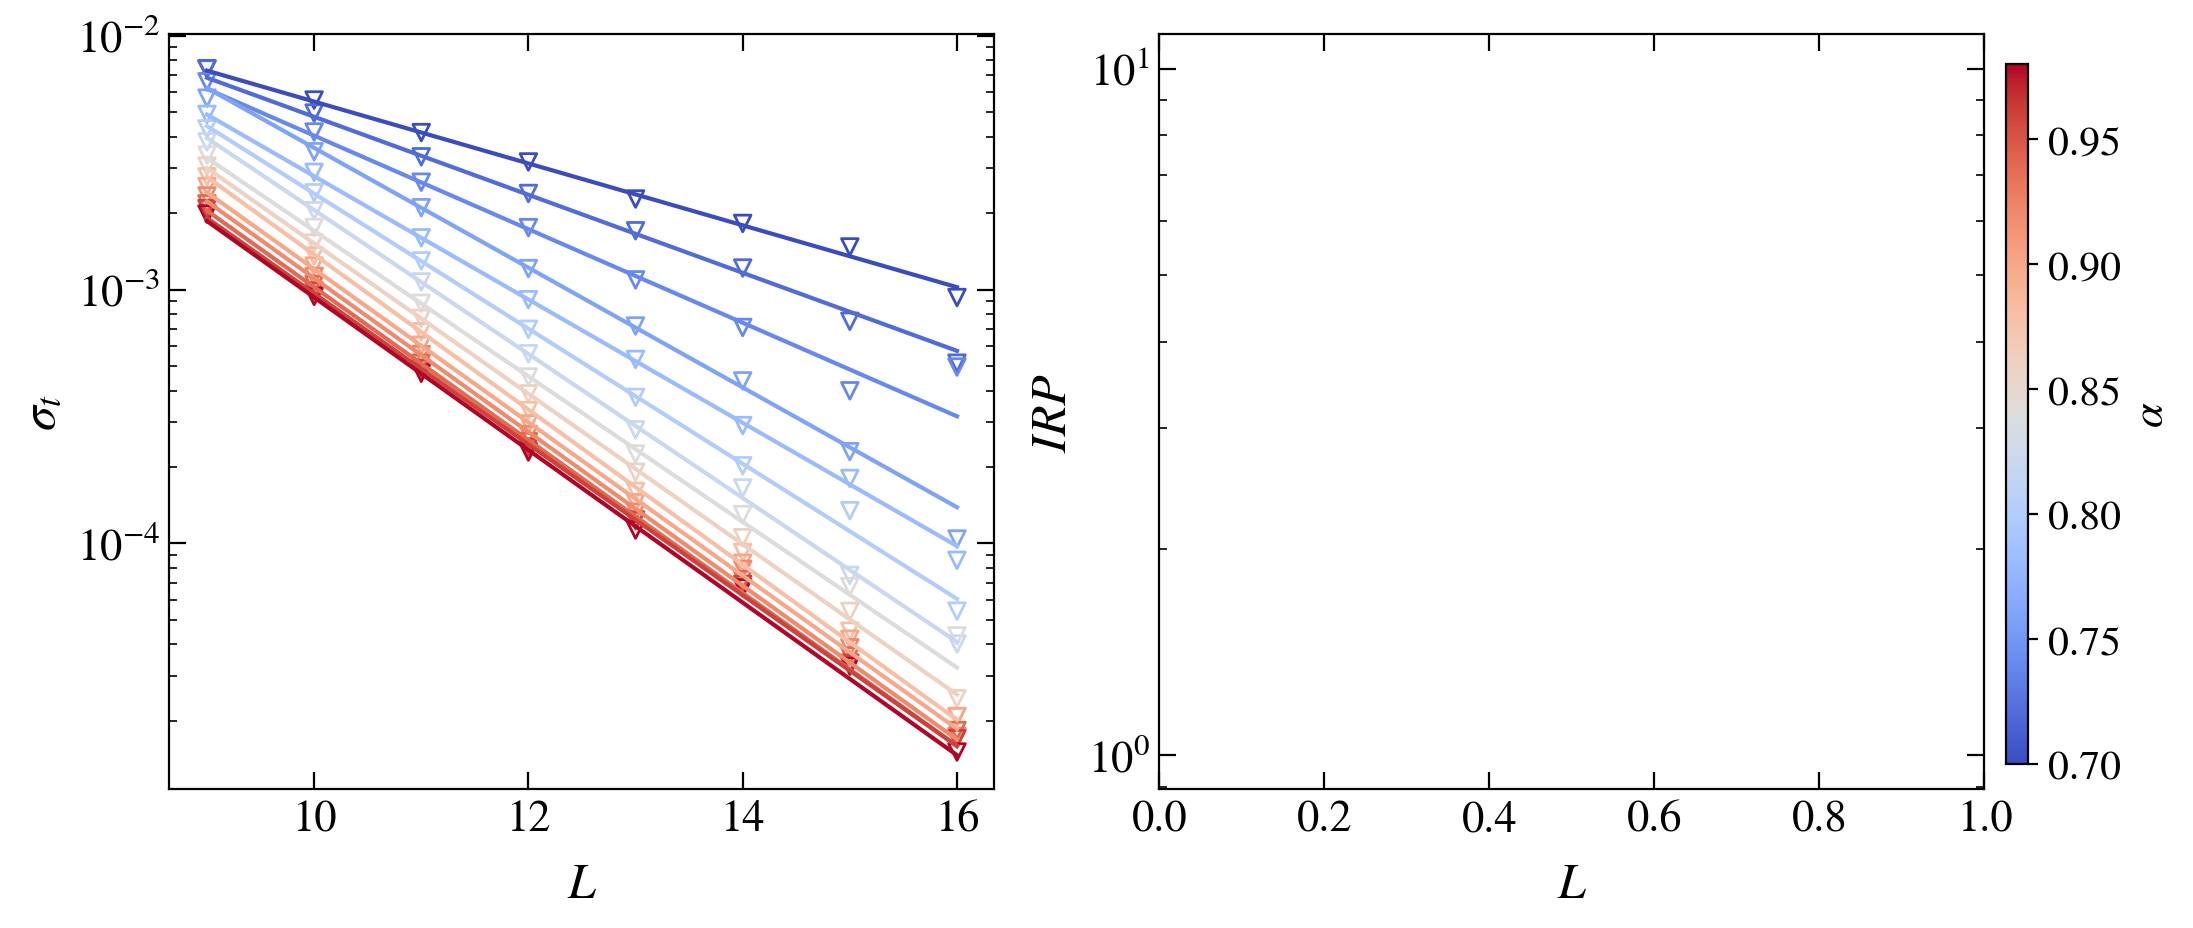

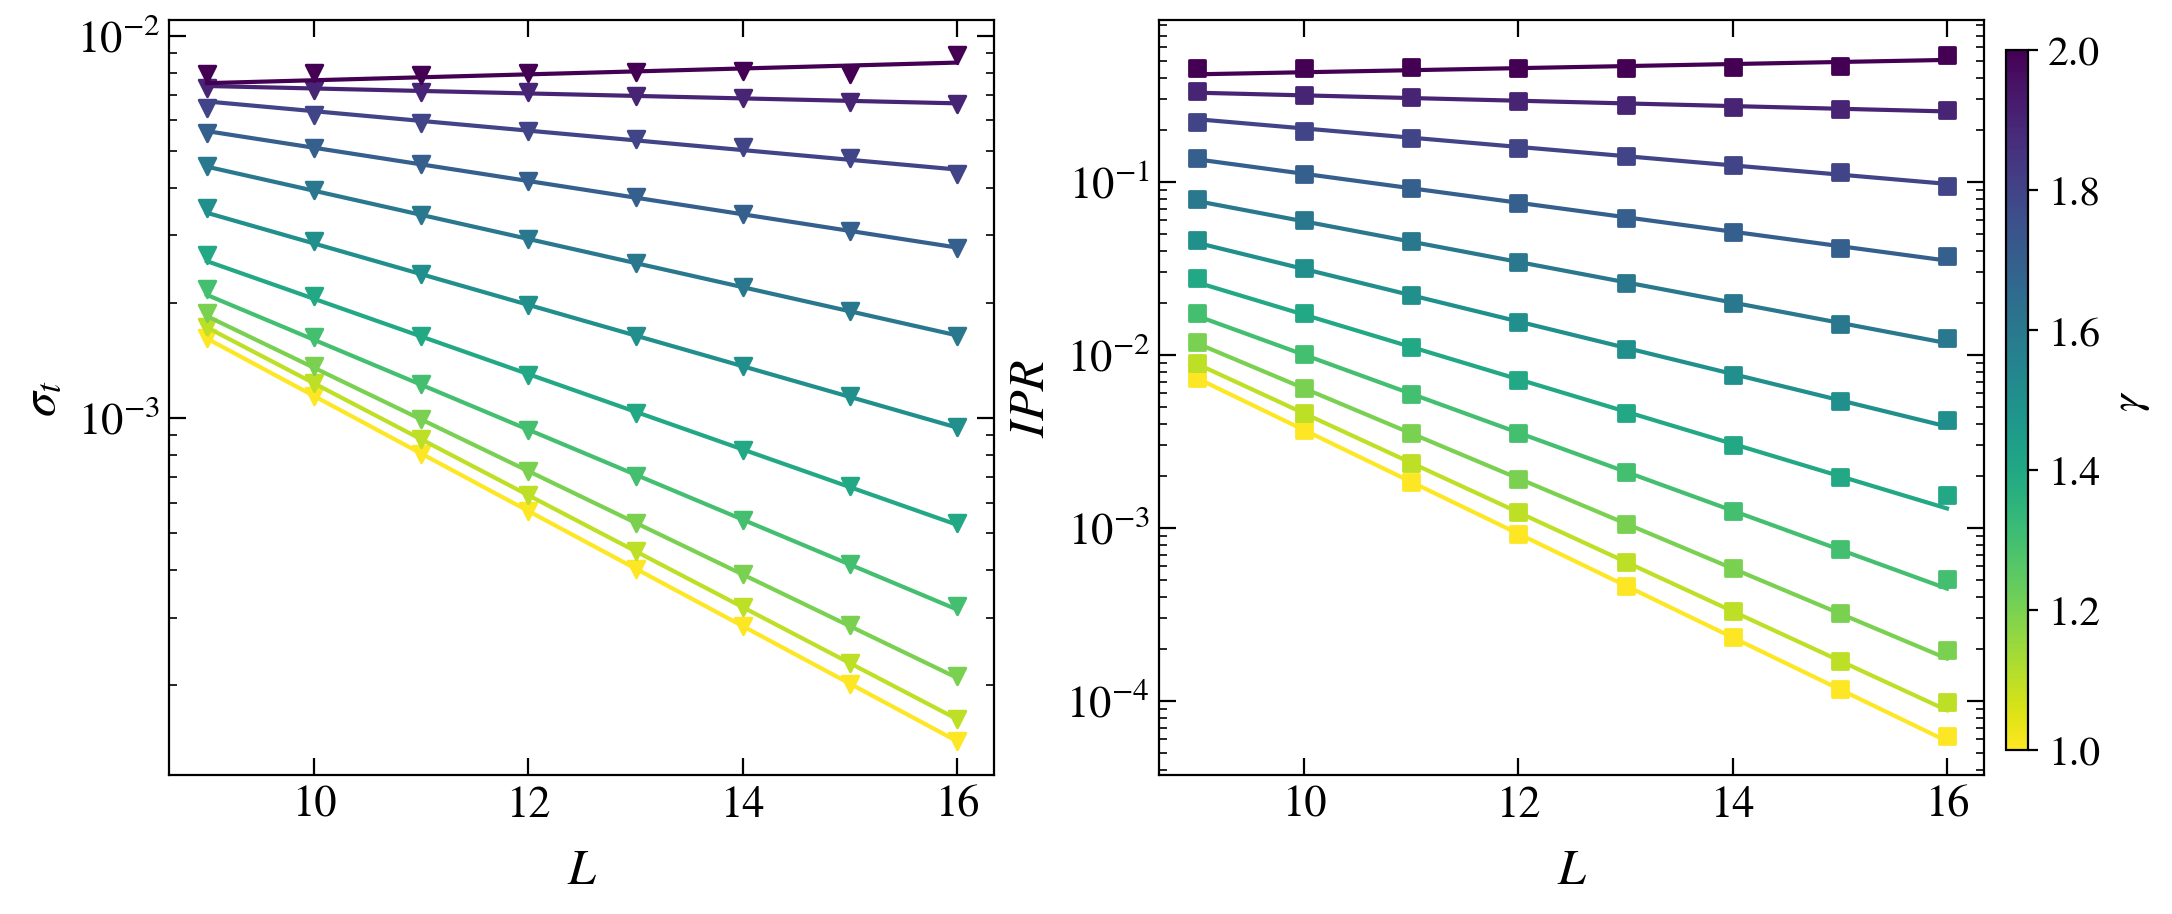

In [1798]:


L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig_end, axes = plt.subplots( nrows=1, ncols=1, figsize=(5,3.5), dpi = 200)
figoshi, axisshi = plt.subplots( nrows=1, ncols=2, figsize=(6,3), dpi = 200)
ax1 = axisshi[0];   ax2 = axisshi[1]
# fig_end = plt.figure(figsize=(7.5,4), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, width_ratios=[3, 2])
# axes = fig_end.add_subplot(gs[:,0])
# ax = fig_end.add_subplot(gs[0,1])
# ax2 = fig_end.add_subplot(gs[1,1])

fig, axis1 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)
fig2, axis2 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)

axis = [*axis1, *axis2]

# gammas = np.array( [*np.arange(0.5, 2.0, 0.1), *np.arange(2.1, 2.2, 0.1)] )
gammas = np.arange(1, 2.01, 0.1)
g_crit = 2
alfac = 1 / np.sqrt(2)

print(gammas)

norm = matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis_r', norm=norm)
s_m.set_array([])


def fading_erg(x, eta, a):
    return a * 2**(-x * eta)

def fading_loc(x, eta, a):
    return a * 2**(x * eta)


qs = np.array( [0.5, 1.0, 1.5, 2.0, 3.0] )
q = 2

colors = []
eta_fluct = []
eta_ipr = []

handles = []
handles2 = []
gammas_plot = [1.4, 1.6]
# ------------------------------------------------------------ ROZENZWEIG-PORTER~
eps = 0.5
for iia, gx in enumerate(gammas):
    name_out = prefix +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    col = s_m.to_rgba(gx)
    colors.append(col)
    
    fading_fit = fading_erg #if gx <= g_crit else fading_loc
    

    typ_susc = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for ii, L in enumerate(sizes):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if not exists(name):
        #     name = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                    
                typ_susc[ii] = 1/np.array(file.get('TYP_SUSC'))[-2]
                wH_typ[ii] = np.array(file.get('wH_typ'))[-2]
    tH = 2 * np.pi / wH_typ
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            # print(sizes, np.array(file.get('sizes'))[3:])
            sizes = np.array(file.get('sizes'))[3:]
            realis = np.array(file.get('realisations'))[3:]
            idx = np.argmin( np.abs(Ex - eps) )
            ipr = np.array(file.get('ipr'))[np.argmin(np.abs(qs - q))][3:]
            temp_fluct = np.zeros(sizes.shape)
            for ii, L in enumerate(sizes):
                times= np.array(file.get('TIMES/L=%d'%L))#[:-50]
                idx1 = np.argmin( np.abs(times - tH[ii] * 5))
                idx2 = np.argmin( np.abs(times - tH[ii] * 5))
                sig = np.array(file.get('temporal fluctuations'))[3 + ii]
                temp_fluct[ii] = np.mean( sig[idx1 : -100] )**0.5
            # temp_fluct = np.zeros(sizes.shape)
            axis[2].scatter(sizes, temp_fluct, color=col, marker='v')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[~np.isnan(temp_fluct)][-6:],
                            ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                            full_output=True, maxfev=10000)
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[2].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            # print(gx, *pars)
            _etaX_ = pars[0]
            if _etaX_ > 1e6 or gx >= 2.5: 
                _etaX_ = np.nan
            eta_fluct.append(_etaX_)
            
            axis[3].scatter(sizes, ipr, color=col, marker='s')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[-6:],
                            ydata = ipr[-6:],
                            full_output=True, maxfev=10000)
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[3].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            print(gx, pars[1], gamma_fun(q - 0.5) * gamma_fun(q + 0.5) / gamma_fun(q) / np.pi / np.sqrt(np.pi / 8)**(2*q-2))
            _etaX_ = (pars[0])
            if _etaX_ > 1e6: _etaX_ = np.nan
            eta_ipr.append(_etaX_)
            
            ax.scatter(sizes, temp_fluct**2 / ipr, marker='v', color=col)
    else:   
        print(name_out)


eta_fluct   = 2*np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr) / (q-1)
print("RP:  AAAA", eta_fluct)
print("RP:  BBBB", eta_ipr)
colors_ls_cyc = itertools.cycle(colors_ls)
line = axes.scatter(gammas, eta_fluct, marker='v', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10)
handles.append(line)

line = axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
handles.append(line)

fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

axes2 = axes.twiny()
# ------------------------------------------------------------ ULTRAMETRIC MODEL
eta_fluct = []
eta_ipr = []
sizes = np.arange(9, 17, 1)
alfas = np.arange(0.7, 0.99, 0.02)
norm = matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas))
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=norm)
s_m.set_array([])

for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    temp_fluct = np.zeros((sizes.size))
    for ii, L in enumerate(sizes):
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                tH = 2 * np.pi / np.array(file.get('mean_lvl/0.50/mean'))[idxa]
        else:
            print(name_out)
        name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 5e-3:
                    print(alfa, name_out)
                    continue
                times = np.array(file.get('Sz/0/ME/fluct/%d/times'%(idxa) ))
                idx1 = np.argmin( np.abs(times - tH))
                # temp_fluct[ii] = np.mean(np.array(file.get('Sz/0/ME/fluct/%d/mean'%(idxa) ))[idx1 : -100]**2)
                temp_fluct[ii] = np.array(file.get('Sz/0/ME/stat/lt/evo/fluct'))[idxa]
        else:
            print(name_out)
    
    line = axis[0].scatter(sizes, temp_fluct, color=col, marker='v', facecolor='None')
    pars, pconv, fit_info, msg, _ = fit(fading_fit,
                    xdata = sizes[~np.isnan(temp_fluct)][-6:],
                    ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                    full_output=True, maxfev=10000)
    # print(J, alfa, fit_info['fvec'])
    dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
    axis[0].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
    # print(gx, *pars)
    _etaX_ = pars[0]
    if _etaX_ > 1e6 or gx >= 2.5: 
        _etaX_ = np.nan
    eta_fluct.append(_etaX_)
    name_out = "./UM results/fractal/_Ngrain=1/fractal_dimension.h5"
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ns = np.array(file.get('4/a=%.3f/Ns'%alfa))
            d2 = np.array(file.get('4/a=%.3f/q=2.00'%alfa))
            # d2 = (16*d2[-1] + 15*d2[-2] + 14*d2[-4]+ 13*d2[-4]) / 4
            d2 = np.sum(Ns[-4:] * d2[-4:]) / np.sum(Ns[-4:])
            eta_ipr.append(d2)
    else:
        print(name_out)
        eta_ipr.append(np.nan)
    
_gammas_ = 1 + np.log(alfas) / np.log(alfac) 
eta_fluct   = np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr)
print("UM:  AAAA", eta_fluct)
print("UM:  BBBB", eta_ipr)
line = axes.scatter(_gammas_, eta_fluct, marker='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10, facecolor='None')
handles.append(line)
line = axes.scatter(_gammas_, eta_ipr, marker='D', color=next(colors_ls_cyc), label=r"$d_2$", zorder=10, facecolor='None')
handles.append(line)
# axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
# fig_help.set_plot_elements(axis[0], ylabel=r"$\mathcal{Q}_{\infty}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[0], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$IRP$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[3], ylabel=r"$IPR$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')

line, = axes.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axes.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([4,2, 3, 5, 0, 1])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    

xx = np.linspace(1, g_crit-0.0, 1000)
axes.plot(xx, (2 - xx), ls='-', color='k')
xx = np.linspace(2, max(gammas), 1000)
axes.plot(xx, [0]*xx.size, ls='-', color='k')
axes.axhline(y=1, xmax=0.4, ls='--', color='gray')

fig_help.set_plot_elements(axes2, ylabel=r"", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axes, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

fig_help.set_legend(axes, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))
axes.set_ylabel(r"$\frac{2}{\eta}$", rotation=0, fontsize=18)
axes.yaxis.set_label_coords(-0.16, 0.5)
axes.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axes2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_plot_elements(ax, ylabel=r"$P_2,\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# fig_help.set_legend(ax, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))

axes.set_xlim(1, 2.0)
axes.set_xticks([1, 1.25, 1.5, 1.75, 2])

ax1Ticks = axes.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return [("%g" % z if z == 1 else "%.3f"%z) for z in V]

axes2.set_xticks(ax2Ticks)
axes2.set_xbound(axes.get_xbound())
axes2.set_xticklabels(tick_function(ax2Ticks))

axes.set_ylim(-0.1, 1.05)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)
fig2.subplots_adjust(wspace = 0.2, hspace=0.2)
# fig2.savefig("PLOTS_FADING/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)
fig_end.subplots_adjust(wspace = 0.3, hspace=0.02)

axes.xaxis.set_label_coords(.62, 1.13)
axes2.xaxis.set_label_coords(.62, -0.13)

fig_end.savefig("PLOTS_FADING/ANOMALOUS/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' or model == 'SYK2' else  f"dim={d}/") + ( '' if model == 'RP' or model == 'SYK2' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


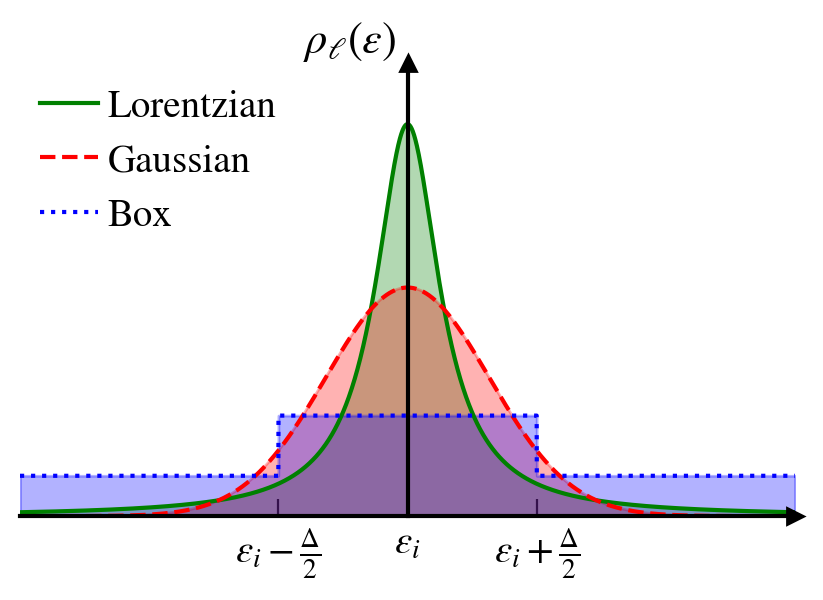

In [ ]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

Gamma = 0.03
sigma = 0.002
x0 = 0.0

x = np.linspace(-1, 1, 10000)
# x = np.linspace(-0.3, 0.3, 10000)
curve1 = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve1 = curve1 / np.trapz(curve1, x)
axis.plot(x, curve1, color='green', label=r"Lorentzian")
axis.fill_between(x, 0, curve1, color='green', alpha=0.3)

x0 = -0.0
curve2 = 1 / np.sqrt(2*np.pi*sigma**2) * np.exp(-(x-x0)**2 / (2*sigma*2))
curve2 = curve2 / np.trapz(curve2, x)
axis.plot(x, curve2, color='red', ls='--', label=r"Gaussian")
axis.fill_between(x, 0, curve2, color='red', alpha=0.3)

x = np.linspace(-0.3, 0.3, 10000)
Gamma = 0.1
sig2 = 0.67
curve3 = (np.heaviside(Gamma - x,0) + np.heaviside(Gamma + x,0)) - 1 + sig2
curve3 = curve3 / np.trapz(curve3, x)
axis.plot(x, curve3, color='blue', ls=':', label=r"Box")
axis.fill_between(x, 0, curve3, color='blue', alpha=0.3)

fig_help.set_plot_elements(axis, ylabel=r"", xlabel=r"", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(axis, loc='upper left', fontsize=14)
axis.set_ylim(1e-6, 12.5)
axis.set_ylabel(r'$\rho_\ell(\epsilon)$', loc='top', rotation=0)
# axis.set_ylabel(r'$\left|c_\alpha(\epsilon_i)\right|^2$', loc='top', rotation=0)
axis.xaxis.set_label_coords(1, 0.15)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['left'].set_position('zero')
axis.spines['bottom'].set_visible(True)
axis.xaxis.set_ticks_position('bottom')
axis.yaxis.set_ticks_position('left')
axis.set_xticks([-Gamma, 0, Gamma])
axis.set_xticklabels([r"$\epsilon_i-\frac{\Delta}{2}$", r"$\epsilon_i$", r"$\epsilon_i+\frac{\Delta}{2}$"])
axis.set_yticks([])
axis.spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis.spines['bottom'].set_linewidth(1.5)  # Thicker x-axis

axis.set_xlim(-0.3, 0.3)
# axis.set_ylim(1e-1, 20)

# Add arrows at the ends of the axes
axis.plot(1, 0, ">k", transform=axis.get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis.plot(0, 1, "^k", transform=axis.get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
fig.savefig("figure.pdf", bbox_inches = 'tight', pad_inches=0.02)


In [ ]:
alfac = 1/np.sqrt(2)
gammas = np.arange(1.2, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gammas - 1) * np.log(alfac**2) ) )

print(gammas, alfas)

[1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] [0.93303299 0.90125046 0.87055056 0.84089642 0.8122524  0.7845841
 0.75785828 0.73204285 0.70710678]


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


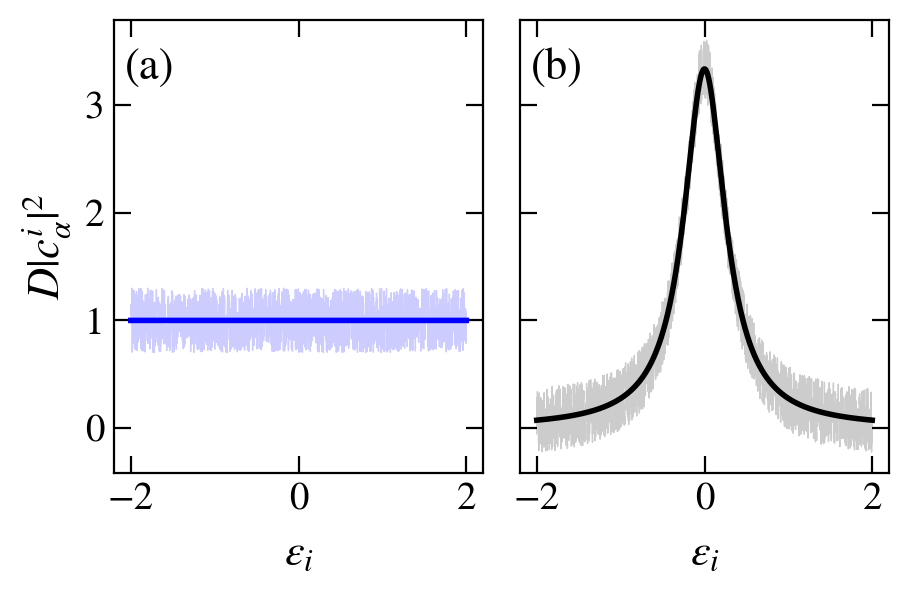

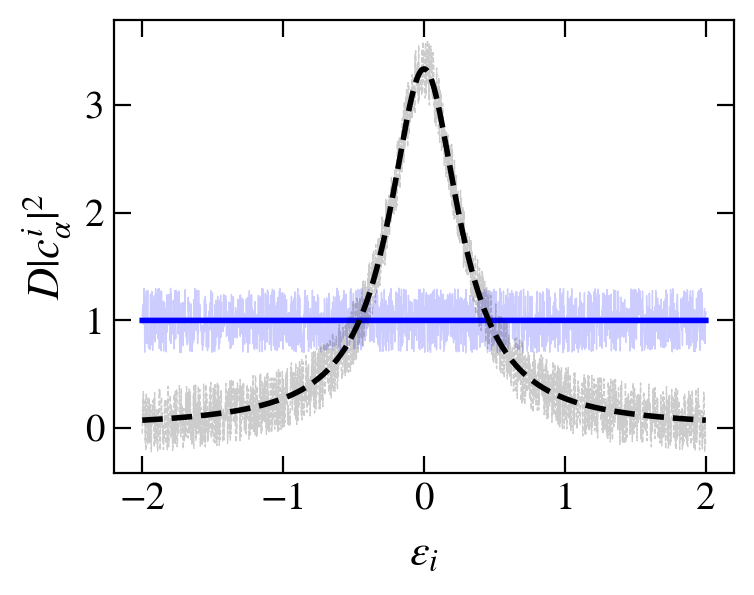

In [ ]:
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(5,3), dpi = 200, sharey = True)
fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharey = True)

Gamma = 0.3
sigma = 0.002
x0 = 0.
noise = 0.3

dim = 2**11

x = np.linspace(-2, 2, dim)

curve = np.ones(x.shape)
curve = curve / np.trapz(curve / (max(x) - min(x)), x)
axis[0].plot(x, curve, color='blue', ls='-', lw=2)
ax.plot(x, curve, color='blue', ls='-', lw=2)
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[0].scatter(x, fluct, s=1, color='blue', alpha=0.1)
axis[0].plot(x, fluct, lw=0.5, color='blue', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='blue', alpha=0.2)


curve = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve = curve / np.trapz(curve * np.exp(-x**2 / 2) / np.sqrt(2*np.pi), x)
axis[1].plot(x, curve, color='k', lw=2)
ax.plot(x, curve, color='k', lw=2, ls='--')
fluct = curve + noise * (np.random.random(curve.size)-0.5)*2
# axis[1].scatter(x, fluct, s=1, color='k', alpha=0.1)
axis[1].plot(x, fluct, lw=0.5, color='k', alpha=0.2)
ax.plot(x, fluct, lw=0.5, color='k', ls='--', alpha=0.2)

fig_help.set_plot_elements(axis[0], ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax, ylabel=r"$D|c_\alpha^i|^2$", xlabel=r"$\epsilon_i$", font_size=14, set_legend=1, xscale='linear', yscale='linear')

# axis.set_xlim(-0.3, 0.3)
# axis[0].set_ylim(0, 2)

fig.subplots_adjust(wspace = 0.1, hspace=0.05)
axis[0].annotate(r"(a)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=16, xy=(0.03, 0.87), xycoords='axes fraction')

fig.savefig("PLOTS_FADING/BEYOND_RMT/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)


## COMPARING UM AND RP

No handles with labels found to put in legend.


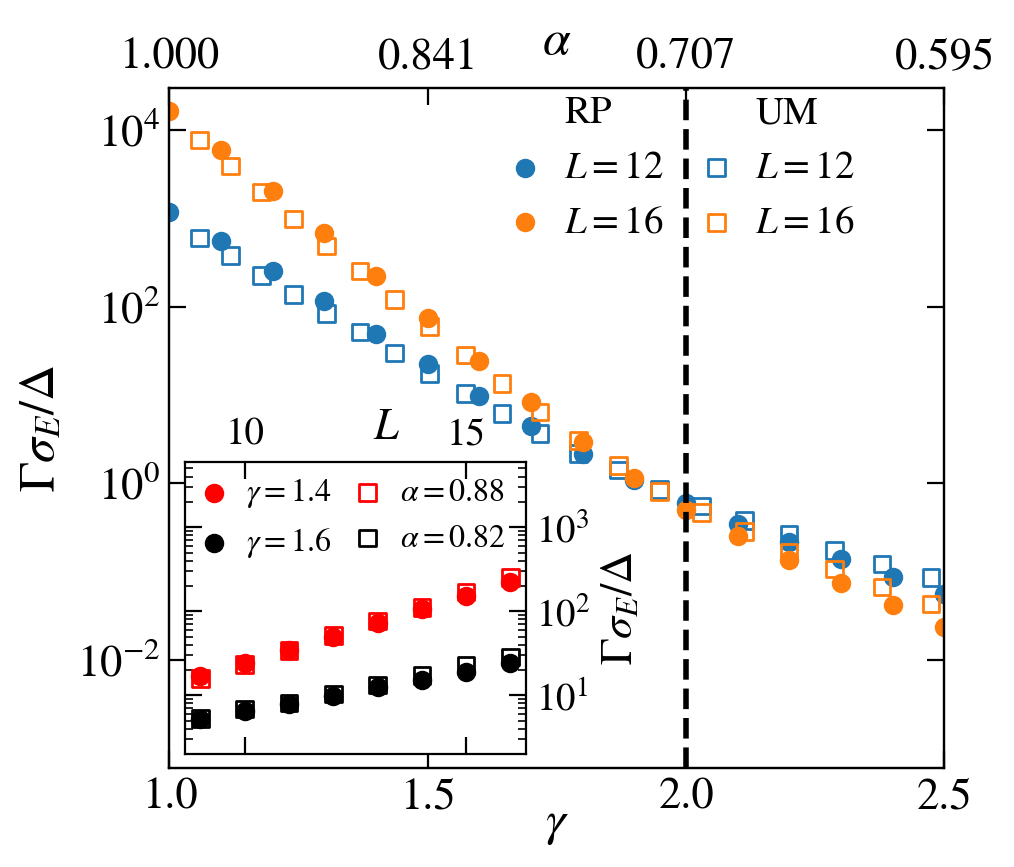

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4.5), dpi = 200, sharex=False, sharey=False)
inset = axis.inset_axes([0.02, 0.02, 0.44, 0.43])
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(1.0, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

handles = []
for L in [12, 16]:
    dim = 2**L
    col = next(colors_ls_cyc)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    E_th = np.zeros(gammas.shape)
    for iig, gx in enumerate(gammas):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-1]
                dE  = np.mean(np.array(file.get('stddev')))#np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # tH = 2 * np.pi / wH
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                # wH = dE / dim / 2 * np.pi
                
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.mean(np.array(file.get('stddev')))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                # xx = omegax#[indices]
                # yy = yy0#[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = omegax,
                #             ydata = yy0,
                #             maxfev = 20000)
                # G = np.abs(pars[-1])
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                # E_th[iig] = G / wH /dE
                E_th[iig] = G / wH * sig
                # E_th[iig] = G / wH
        else:
            print(name)
    line = axis.scatter(gammas, E_th, color = col, label=r"$L=%d$"%L)
    handles.append(line)
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfas = np.array(file.get('Sz/0/alphas/mean'))
            # indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
            # alfas = alfas[indices]
            
            _alfas_ = []
            _gammas_ = []
            E_th2 = []
            iicons = 0
            for iia, alfa in enumerate(alfas):
                if alfa >= 0.591 and alfa < 1:
                    idxa = np.argmin( np.abs(alfas - alfa) )
                    omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))
                    spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
                    
                    name_out2 = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
                    if exists(name_out2):
                        with h5py.File(name_out2, "r") as fileee:
                            alfasdasdas = np.array(fileee.get('alphas'))
                            idxa2 = np.argmin( np.abs(alfasdasdas - alfa) )
                            wH = np.array(fileee.get('mean_lvl/1.00/mean'))[idxa2]
                            dE = np.array(fileee.get('bandwidth/mean'))[idxa2]
                            sig = np.array(fileee.get('variance/1.00/mean'))[idxa2]
                            # wH = dE / dim
                            # print(L, alfa, sig)
                    else:
                        print(name_out2)
                         
                    # wH = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                    xx = omegas
                    yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    idxG = np.argmin( np.abs(yy - 0.5) )
                    E_th2.append( omegas[1:][idxG] / wH * sig)
                    # E_th2.append( omegas[1:][idxG] / wH)
                    # E_th2.append( omegas[1:][idxG] / dE * sig)
                    
                    _gammas_.append(1 + np.log(alfa**2) / np.log(alfac**2))
                    _alfas_.append(alfa)
                    
                
            # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
            line = axis.scatter(_gammas_, E_th2, color=col, facecolor='None', marker='s', label=r"$L=%d$"%L)
            handles.append(line)
    else:
        print(name_out)
        
    _alfas_ = np.array(_alfas_) 
    # axis.plot(gammas, dim**(1-gammas) )
axis.set_xlim(1, 2.5)
axis.set_ylim(6e-4, 3e4)

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$\Gamma\sigma_E/\Delta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_legend(axis, fontsize=14, loc='upper right', anchor=(0.93, 1.04), ncol = 2, handles = _handle_shit, columnspacing=0.6)

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

s_m_g = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(gammas), vmax=max(gammas)))
s_m_g.set_array([])

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=min(_alfas_), vmax=max(_alfas_)))
s_m_a.set_array([])

gammas = [1.4, 1.6]
handles = []
for iig, gx in enumerate(gammas):
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    
    E_th_RP = np.zeros(sizes.shape)
    E_th_UM = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        dim = 2**L
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                wH        = np.array(file.get('wH'))[-1]
                # wH = 2 * np.pi / ( dim / (np.sqrt(1 + dim**(1-gx))) * 2 )
                
                tH        = 2 * np.pi / wH
                dE  = np.mean(np.array(file.get('bandwidth')))
                sig  = np.mean(np.array(file.get('stddev')))# np.sqrt(1 + dim**(1-gx))#np.mean( np.array(file.get('bandwidth')) )
                # wH = dE / dim
                
                omegax = np.array(file.get('omegas'))# / wH
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                
                # E_th_RP[iiL] = xx[1:][idxG] / wH
                E_th_RP[iiL] = xx[1:][idxG] / wH * sig
                # E_th_RP[iiL] = xx[1:][idxG] / dE * sig
        # ------------------------------------------------------------ ULTRAMETRIC MODEL
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                wH = np.array(file.get('mean_lvl/1.00/mean'))[idxa]
                dE = np.array(file.get('bandwidth/mean'))[idxa]
                sig = np.array(file.get('variance/1.00/mean'))[idxa]
                # print(L, alfa, sig)
        else:
            print(name_out)
            
        name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 1e-2:
                    print(alfa, name_out)
                    continue
                alfax = _alfas_[idxa]
                E_th        = np.array(file.get('Sz/0/gamma/mean'))
                # wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                # tH        = 2 * np.pi / wH
                # idxa = np.argmin( np.abs(E_th - G) )
                # print(alfa, _alfas_[idxa])
                E_th = E_th[idxa]
                omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                xx = omegas
                yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                # E_th_UM[iiL] = omegas[1:][idxG] / wH
                E_th_UM[iiL] = omegas[1:][idxG] / wH * sig
                # E_th_UM[iiL] = omegas[1:][idxG] / dE * sig
        else:
            print(name_out)
    col = 'k' if iig else 'red'
    line = inset.scatter(sizes, E_th_RP, color=col, label=r"$\gamma=%g$"%gx)
    handles.append(line)
    
    line = inset.scatter(sizes, E_th_UM, marker='s', color=col, facecolor='None', label=r"$\alpha=%g$"%alfax)
    handles.append(line)


# line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
# handles.append(line)
# line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
# handles.append(line)
indices = np.array([0,2, 1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )  
inset.xaxis.set_label_coords(0.59, 1.08)

axis.xaxis.set_label_coords(.5, -0.05)
axis2.xaxis.set_label_coords(.5, 1.05)
inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
inset.yaxis.set_ticks_position('right')
inset.yaxis.set_label_position('right')

inset.set_ylim(2e0, 6e3)
fig_help.set_plot_elements(inset, ylabel=r"$\Gamma\sigma_E/\Delta$", xlabel=r"$L$", font_size=14, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(inset, fontsize=11.5, loc='upper left', anchor=(-0.07, 1.05), ncol = 2, handles = _handle_shit, columnspacing=0.4)
# inset.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))
# inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))

fig.subplots_adjust(wspace = 0.1, hspace=0.34)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)


No handles with labels found to put in legend.


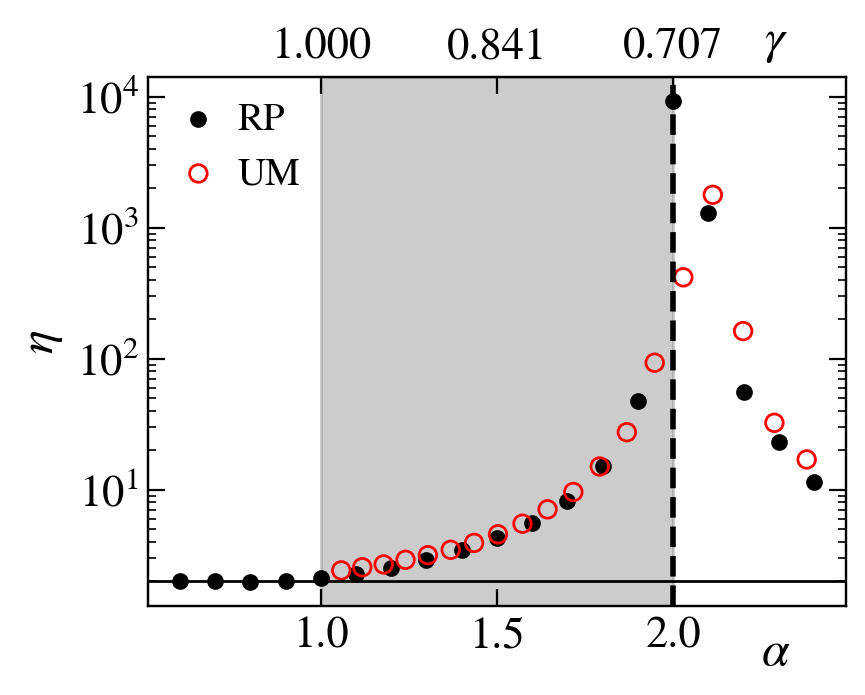

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(6, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(0.6, 2.5, 0.1)

ymin = 1e6
axis2 = axis.twiny()

# ------------------------------------------------------------ ROZENZWEIG-PORTER
def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-eta)

etaRP = np.zeros(gammas.shape)
for iig, gx in enumerate(gammas):
    DOS = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for iiL, L in enumerate( sizes ):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
                _DOS = np.array(file.get('DOS'))[idx]
                DOS[iiL] = _DOS
                wHx = np.array(file.get('wH_density'))[idx]
                yy0 = spec_fun
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wHx * G)))
                
                spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[ max(0, idx_spec - 20) : min(idx_spec + 20, yy0.size)]) )
        else:
            print(name)
    DOS = DOS[~np.isnan(spec_at_wH_G)]
    sizes = sizes[~np.isnan(spec_at_wH_G)]
    spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]

    pars, pconv= fit(matelem_fit,
                xdata = DOS[-4:],
                ydata = spec_at_wH_G[-4:],
                maxfev = 20000)
    etaRP[iig] = 1 / np.abs(pars[-1])
    # a1 = -1 / ( (np.log(spec_at_wH_G[-1]) - np.log(spec_at_wH_G[-2])) / (np.log(DOS[-1]) - np.log(DOS[-2])) )
    # a2 = -1 / ( (np.log(spec_at_wH_G[-2]) - np.log(spec_at_wH_G[-3])) / (np.log(DOS[-2]) - np.log(DOS[-3])) )
    # etaRP[iig] = (a1 + a2)/2
axis.scatter(gammas, etaRP, label=r"RP", zorder=0, color='k', s=25)
    
# ------------------------------------------------------------ ULTRAMETRIC MODEL
name_out = "./UM results/SpectralFun/etas.h5"
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        alfas = np.array(file.get('Sz/0/etas/mean'))[:, 0]
        _gammas_ = 1 + np.log(alfas**2) / np.log(alfac**2)
        
        etas = np.array(file.get('Sz/0/etas/mean'))[:, 1]
        indices = np.argwhere( np.logical_and(alfas >= 0.617, alfas < 1.1) )
        axis.scatter(_gammas_[indices], etas[indices], label=r"UM", zorder=1, color='red', facecolor='None', s=40)
        
else:
    print(name_out)
        

axis.axvline(x=2, ls='--', color='k', lw=2)
axis.axvspan(xmin=1, xmax=2, color='gray', alpha=0.4, zorder=-1)
axis.axhline(y=2, ls='-', color='k', lw=1)

fig_help.set_plot_elements(axis, ylabel=r"$\eta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, loc='upper left', fontsize=14)

fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)

axis.xaxis.set_label_coords(.9, 1.11)
axis2.xaxis.set_label_coords(.9, -0.11)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.9012504626108302 10.657132148742676
16 0.8705505632961241 10.165755271911621


No handles with labels found to put in legend.


16 0.8408964152537145 9.769786834716797


No handles with labels found to put in legend.


16 0.8122523963562355 9.496708869934082
16 0.7845840978967507 9.137992858886719


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.757858283255199 9.036253929138184
16 0.7320428479728127 8.820806503295898


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


16 0.7071067811865475 8.627921104431152


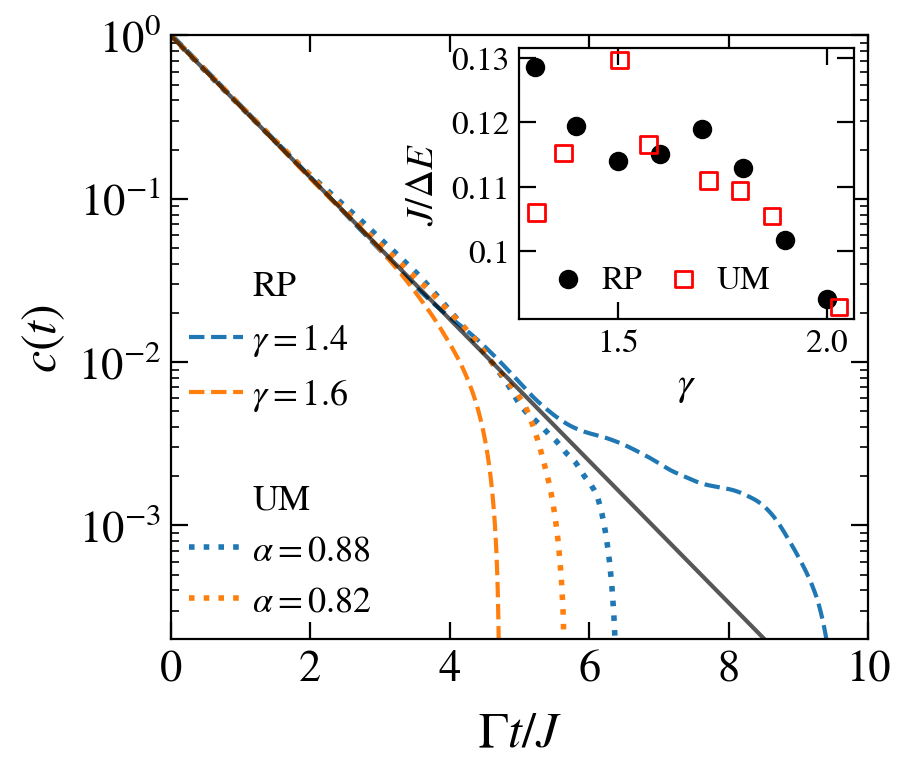

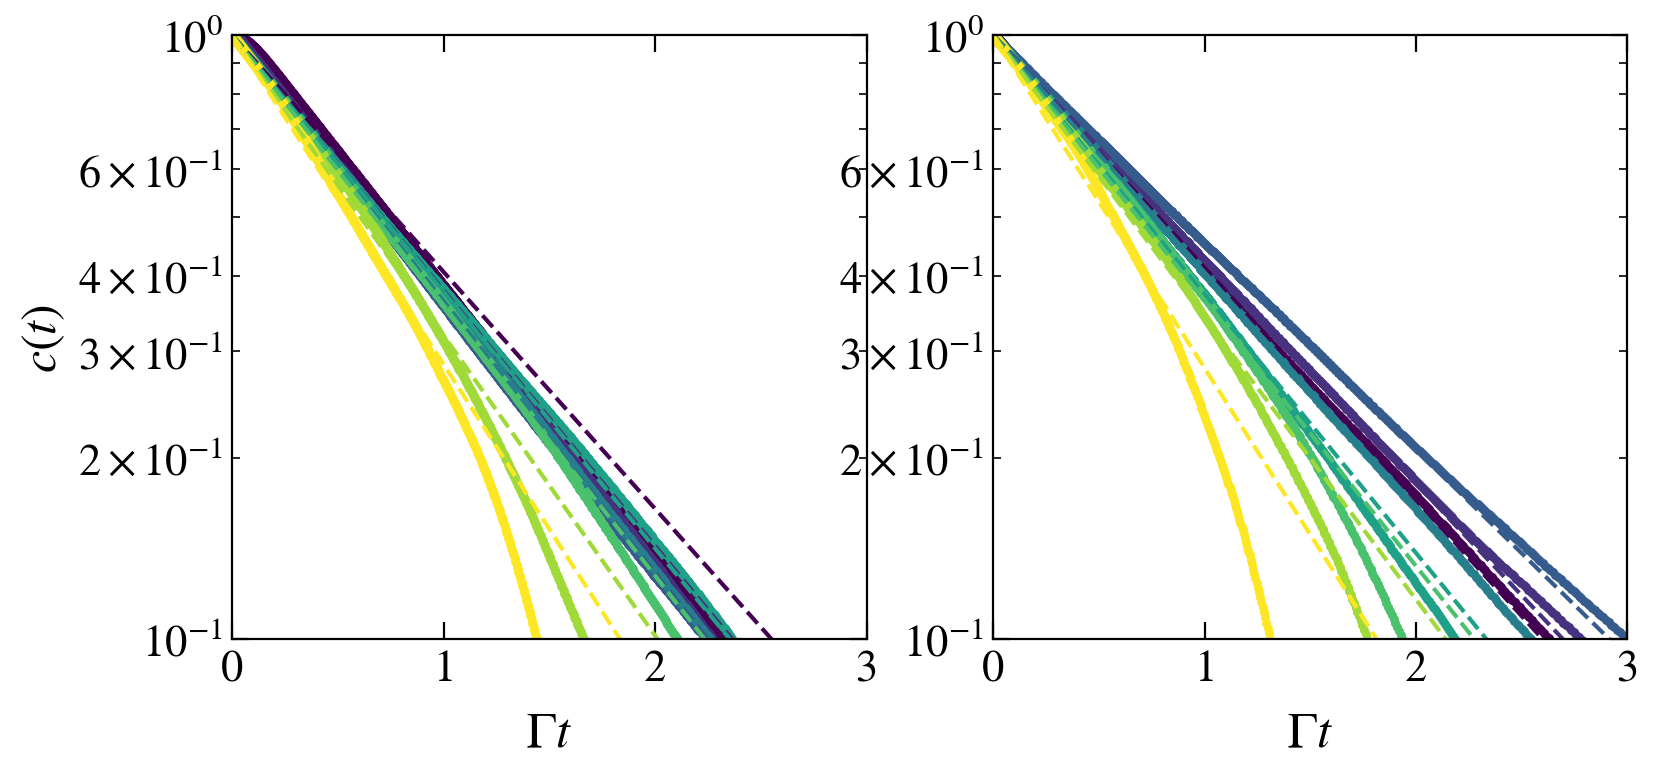

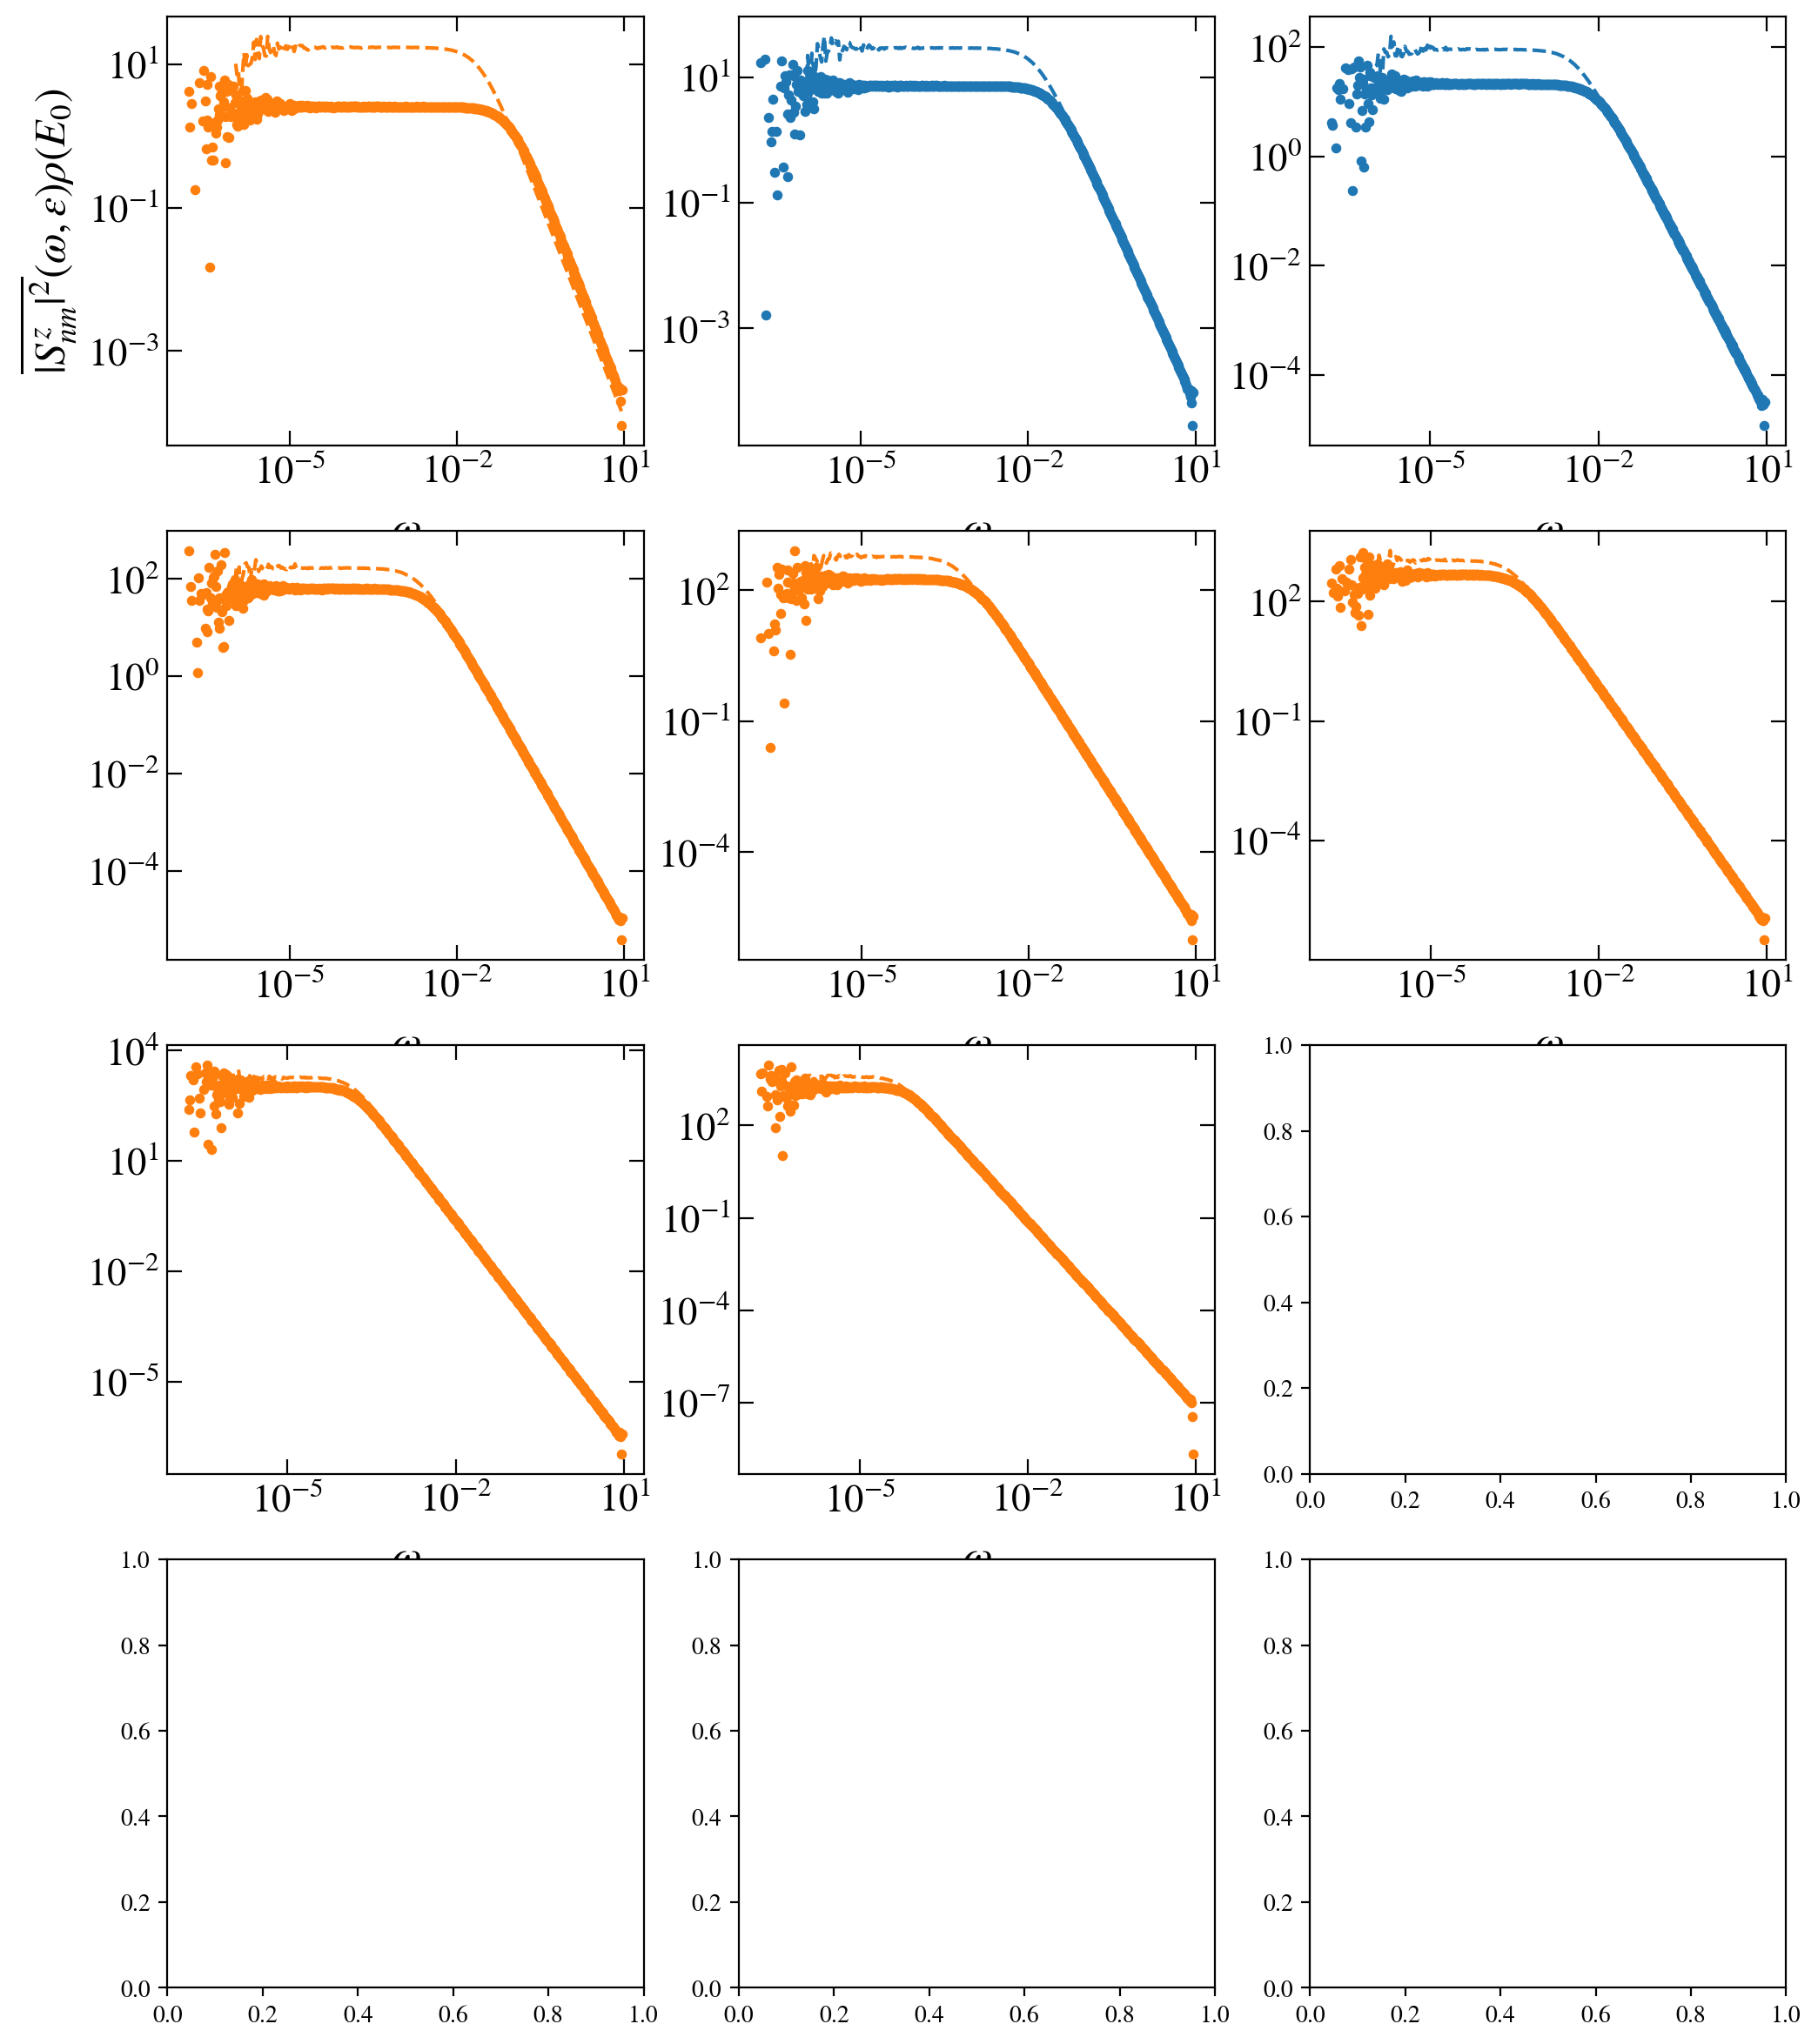

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(7, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 200, sharex=False, sharey=False)

fig_test, axis_test = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200, sharex=False, sharey=False)
# fig = plt.figure(figsize=(5,6), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
# axis = fig.add_subplot(gs[1, :])
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])


fig2, axis2 = plt.subplots( nrows=4, ncols=3, figsize=(12,15), dpi = 200, sharex=False, sharey=False)
axis2 = axis2.flatten()

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)


r_idx = 5
corr = 0
gx = 1.5
window = 80

L = 16
eps = 0.5
alfac = 1/np.sqrt(2)

gamma_vals = np.arange(1.3, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gamma_vals - 1) * np.log(alfac**2) ) )
dim = 2**L

def funn(obs, DE):
    return (obs - DE) / (obs[0] - DE)
    # return obs / obs[0]

con = 0.115

ymin = 1e6

handles = []

def exp_fit(x, J):
    """Exponential function to fit and find decay rate"""
    return np.exp(- x / J)

norm = matplotlib.colors.Normalize(
        vmin=min(gamma_vals),
        vmax=max(gamma_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])
# for iig, gx in enumerate([1.4, 1.6]):

energy_scale_RP = []
energy_scale_UM = []
_gammas_ = []
for iig, gx in enumerate(gamma_vals):
    gx = np.round(gx, 1)
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    if gx == 1.4 or gx == 1.6:
        col = next(colors_ls_cyc)
    col2 = s_m.to_rgba(gx)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            wH        = np.array(file.get('wH'))[-2]
            tH        = 2 * np.pi / wH
            
            omegax = np.array(file.get('omegas'))# / wH
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx]
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
            yy0 = spec_fun * 2**L
            
            omegax = omegax[~np.isnan(yy0)]
            spec_fun = spec_fun[~np.isnan(yy0)]
            spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            axis2[iig].scatter(omegax, yy0, color=col, s=10)
            xx = omegax
            yy = integrate.cumulative_trapezoid(yy0, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            
            dE  = np.mean( np.array(file.get('bandwidth')) )
            # dE  = wH * dim
            G = xx[1:][idxG]#np.sqrt(1 + dim**(1-gx))
            
    else:
        print(name)       
    
    name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            times    = np.array(file.get('TIMES/L=%d'%L))# / tH
            quench = np.array(file.get('QUENCH/L=%d'%L))
            autocorr = np.array(file.get('AUTOCORR/L=%d'%L))
            
            quench = tools.remove_fluctuations(quench, bucket_size=window)[window//2:-window//2]
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            DE = np.mean(obs[-1000 : -100])
            obs = funn(obs, DE)
            
            indices = (obs > 0.01)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G)[indices],
                            ydata = obs[indices],
                            full_output=True, maxfev=10000)
            
            axis_test[0].scatter((times * G)[indices], obs[indices], color=col2, s = 5)
            x = np.linspace(0, 10, 1000)
            axis_test[0].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            energy_scale_RP.append(pars[0] / dE)
            
            if gx == 1.4 or gx == 1.6:
                line, = axis.plot((times * G) / dE / con, obs, color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx)
                handles.append(line)
            # if np.min( np.abs(obs[times < 10/wH/G]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G]) )
    else:
        print(name_out)
    
    
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            E_th        = np.array(file.get('Sz/0/gamma/mean'))
            wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
            tH        = 2 * np.pi / wH
            # idxa = np.argmin( np.abs(E_th - G) )
            # print(alfa, _alfas_[idxa])
            E_th = E_th[idxa]
            omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]# / wH
            spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
            axis2[iig].plot(omegas, spec_fun, color=col, ls='--')
            xx = omegas
            yy = integrate.cumulative_trapezoid(spec_fun, omegas)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G_UM = omegas[1:][idxG]
            # print(alfa, _alfas_[idxa], G, G_UM, E_th)
    else:
        print(name_out)
        
    name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            # sig = np.array(file.get('variance/1.00/mean'))[idxa]
            sig = np.array(file.get('bandwidth/mean'))[idxa]
            # sig = np.array(file.get('mean_lvl/0.50/mean'))[idxa] * dim
            print(L, alfa, sig)
    else:
        print(name_out)
            
    name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            times = np.array(file.get('Sz/0/ME/autocorr/%d/times'%(idxa) ))# / tH
            autocorr = np.array(file.get('Sz/0/ME/autocorr/%d/mean'%(idxa) )) / 4
            
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            DE = np.mean(obs[-1000 : -100])
            obs = funn(obs, DE)
            
            indices = (obs > 0.01)
            pars, pconv, fit_info, msg, _ = fit(exp_fit,
                            xdata = (times * G_UM)[indices],
                            ydata = obs[indices],
                            full_output=True, maxfev=10000)
            
            axis_test[1].scatter((times * G_UM)[indices], obs[indices], color=col2, s = 5)
            x = np.linspace(0, 10, 1000)
            axis_test[1].plot(x, exp_fit(x, *pars), color=col2, ls='--')
            
            _gammas_.append(1 + np.log(_alfas_[idxa]) / np.log(alfac))
            energy_scale_UM.append(pars[0] / sig)
            
            if gx == 1.4 or gx == 1.6:
                # DE = np.array(file.get('Sz/0/ME/stat/lt/ac/typical' ))[idxa]
                line, = axis.plot((times * G_UM) / sig / con, obs, color=col, ls=':', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]))
                handles.append(line)
            
            # if np.min( np.abs(obs[times < 10/wH/G_UM]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G_UM]) )
    else:
        print(name_out)
    
    fig_help.set_plot_elements(axis2[iig], ylabel=r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)\rho(E_0)$" if iig==0 else "", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"$\ $")
handles.append(line)
indices = np.array([5,0,2, 6, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    
fig_help.set_plot_elements(axis, ylabel=r"$c(t)$", xlabel=r"$\Gamma t/J$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=13, loc='lower left', ncol = 1, handles = _handle_shit, columnspacing=0.5)
axis.set_xlim(0, 10)

times = np.linspace(0, 10, 1000)
axis.plot(times, np.exp(-times), ls='-', color='k', alpha=0.66)
# axis.plot(times, np.exp(-0.9*times), ls='-', color='red', alpha=0.5)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')
axis.set_ylim(2e-4, 1)
cbar = None

inset = axis.inset_axes([0.5, 0.53, 0.48, 0.45])
inset.scatter(gamma_vals, energy_scale_RP, color='k', marker='o', label=r"RP")
inset.scatter(_gammas_, energy_scale_UM, color='red', marker='s', facecolor='None', label=r"UM")
fig_help.set_plot_elements(inset, ylabel=r"$J/\Delta E$", xlabel=r"$\gamma$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='lower left', ncol = 2, columnspacing=0.5)
inset.set_yticks([0.1, 0.11, 0.12, 0.13])
inset.set_yticklabels(["0.1", "0.11", "0.12", "0.13"])
inset.minorticks_off()

fig.subplots_adjust(wspace = 0.1, hspace=0.17)

fig_help.set_plot_elements(axis_test[0], ylabel=r"$c(t)$", xlabel=r"$\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis_test[0].set_xlim(0, 3)
axis_test[0].set_ylim(1e-1, 1)
fig_help.set_plot_elements(axis_test[1], ylabel=r"", xlabel=r"$\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis_test[1].set_xlim(0, 3)
axis_test[1].set_ylim(1e-1, 1)

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# DIVIDE Gamma / J, J = bandwidth, if does not work find prefactor which can be different for both models

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
1.0 3.645164537452073 0.9549296585513722
1.1 3.316595284552252 0.9549296585513722
1.2000000000000002 2.5607270621172322 0.9549296585513722
1.3000000000000003 1.7859291583953094 0.9549296585513722
1.4000000000000004 1.252741342068969 0.9549296585513722
1.5000000000000004 1.0290587852046646 0.9549296585513722
1.6000000000000005 0.8790151464158785 0.9549296585513722
1.7000000000000006 0.7622182785094404 0.9549296585513722
1.8000000000000007 0.6944813611383358 0.9549296585513722
1.9000000000000008 0.4506988636278627 0.9549296585513722
2.000000000000001 0.3267194790046762 0.9549296585513722
RP:  AAAA [ 1.00011705  0.97296472  0.89833937  0.78143246  0.65469198  0.53340568
  0.41906588  0.2891699   0.16902522  0.04312466 -0.05114788]
RP:  BBBB [ 0.99537752  0.94974986  0.86440668  0.74801062  0.61984562  0.50379367
  0.38958492  0.27772498  0.1772451   0.05137283 -0.03944023]


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


UM:  AAAA [0.40479093 0.51045686 0.6120673  0.7836408  0.80652228 0.88369917
 0.9417856  0.95259137 0.9840514  1.01458821 1.00280755 1.00553702
 1.00017589 0.98718047 0.99829326]
UM:  BBBB [0.49541389 0.64513024 0.78229527 0.88524801 0.93936452 0.98593269
 1.00539354 1.01227272 1.01467037 1.01729144 1.01717297 1.0169908
 1.01651885 1.01552675 1.01558931]


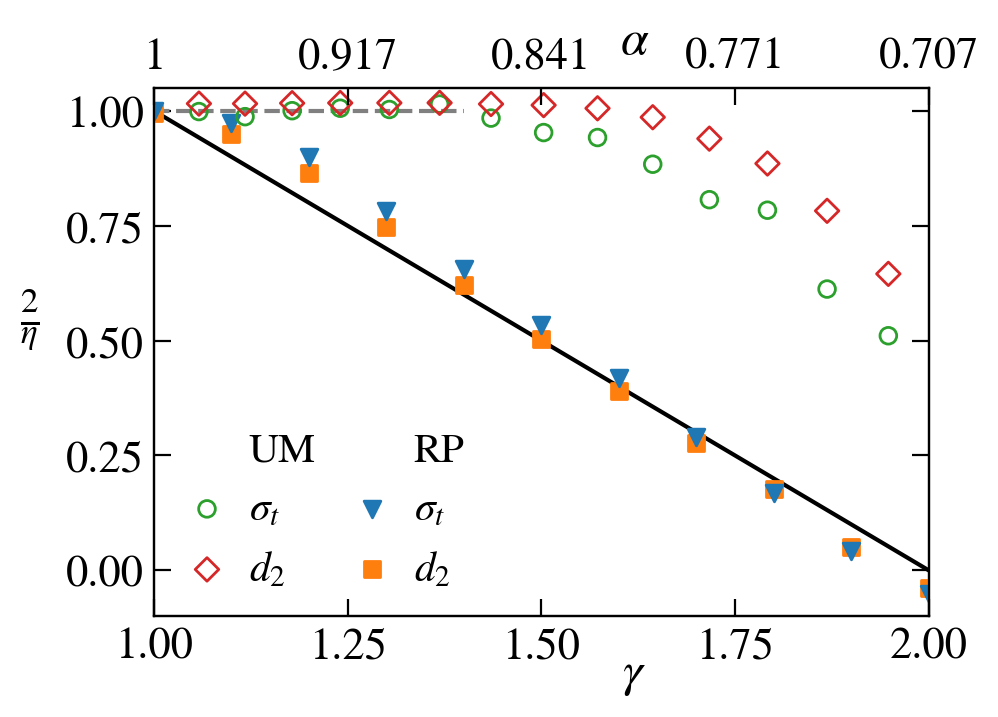

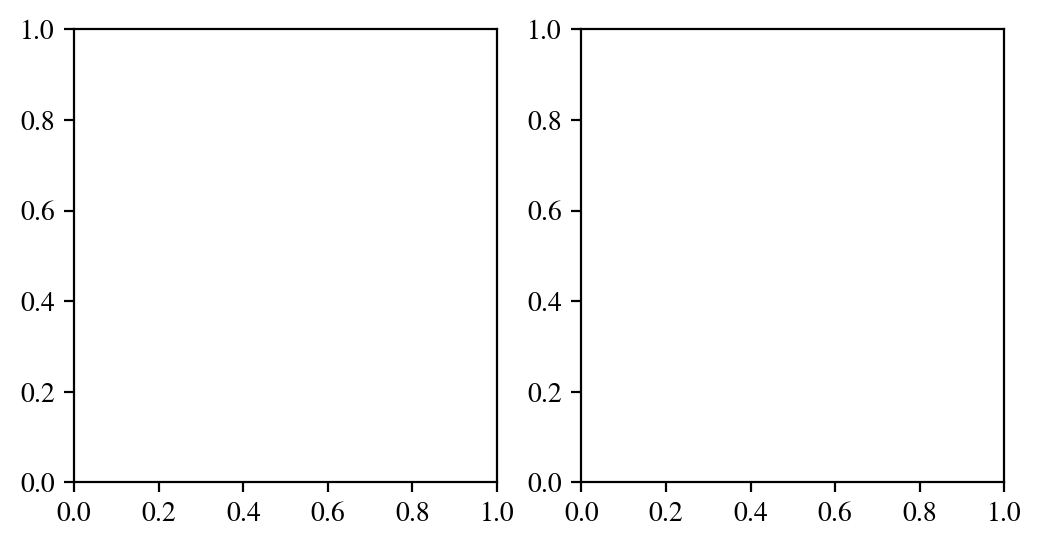

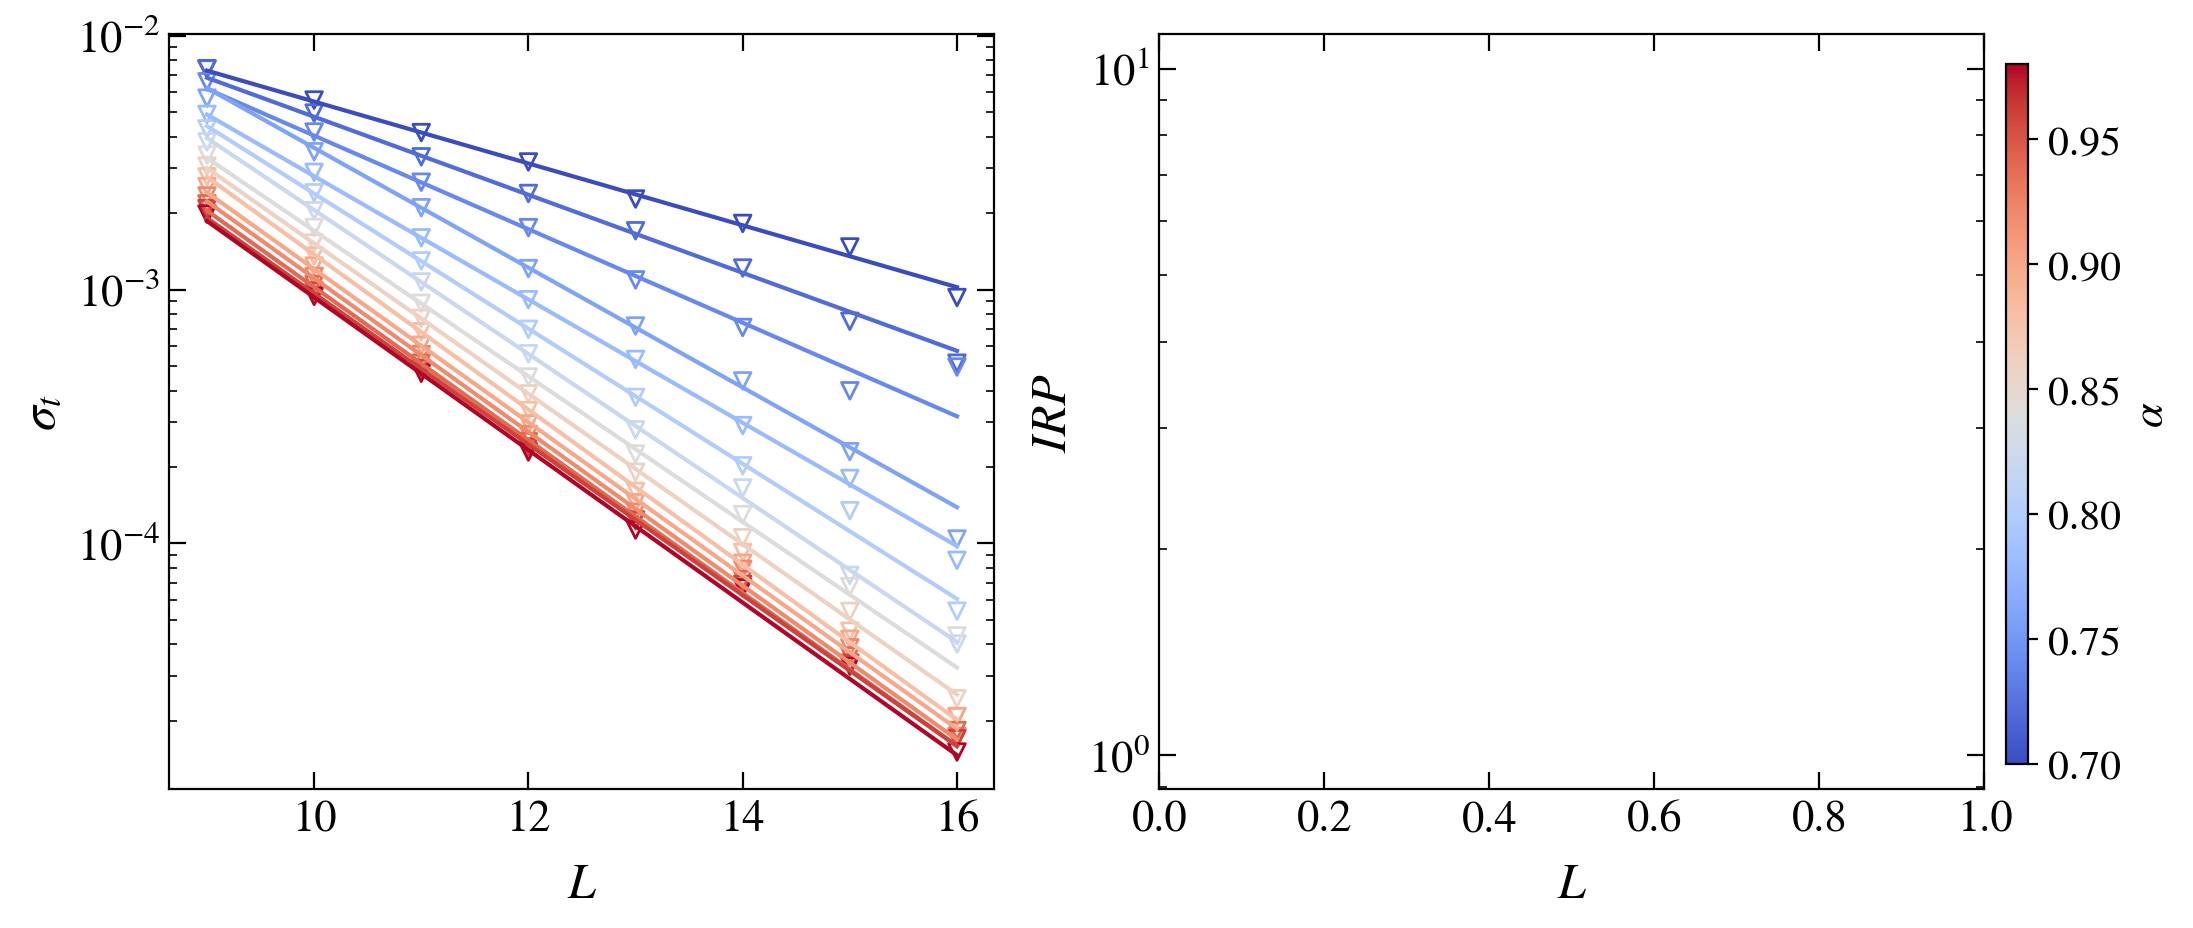

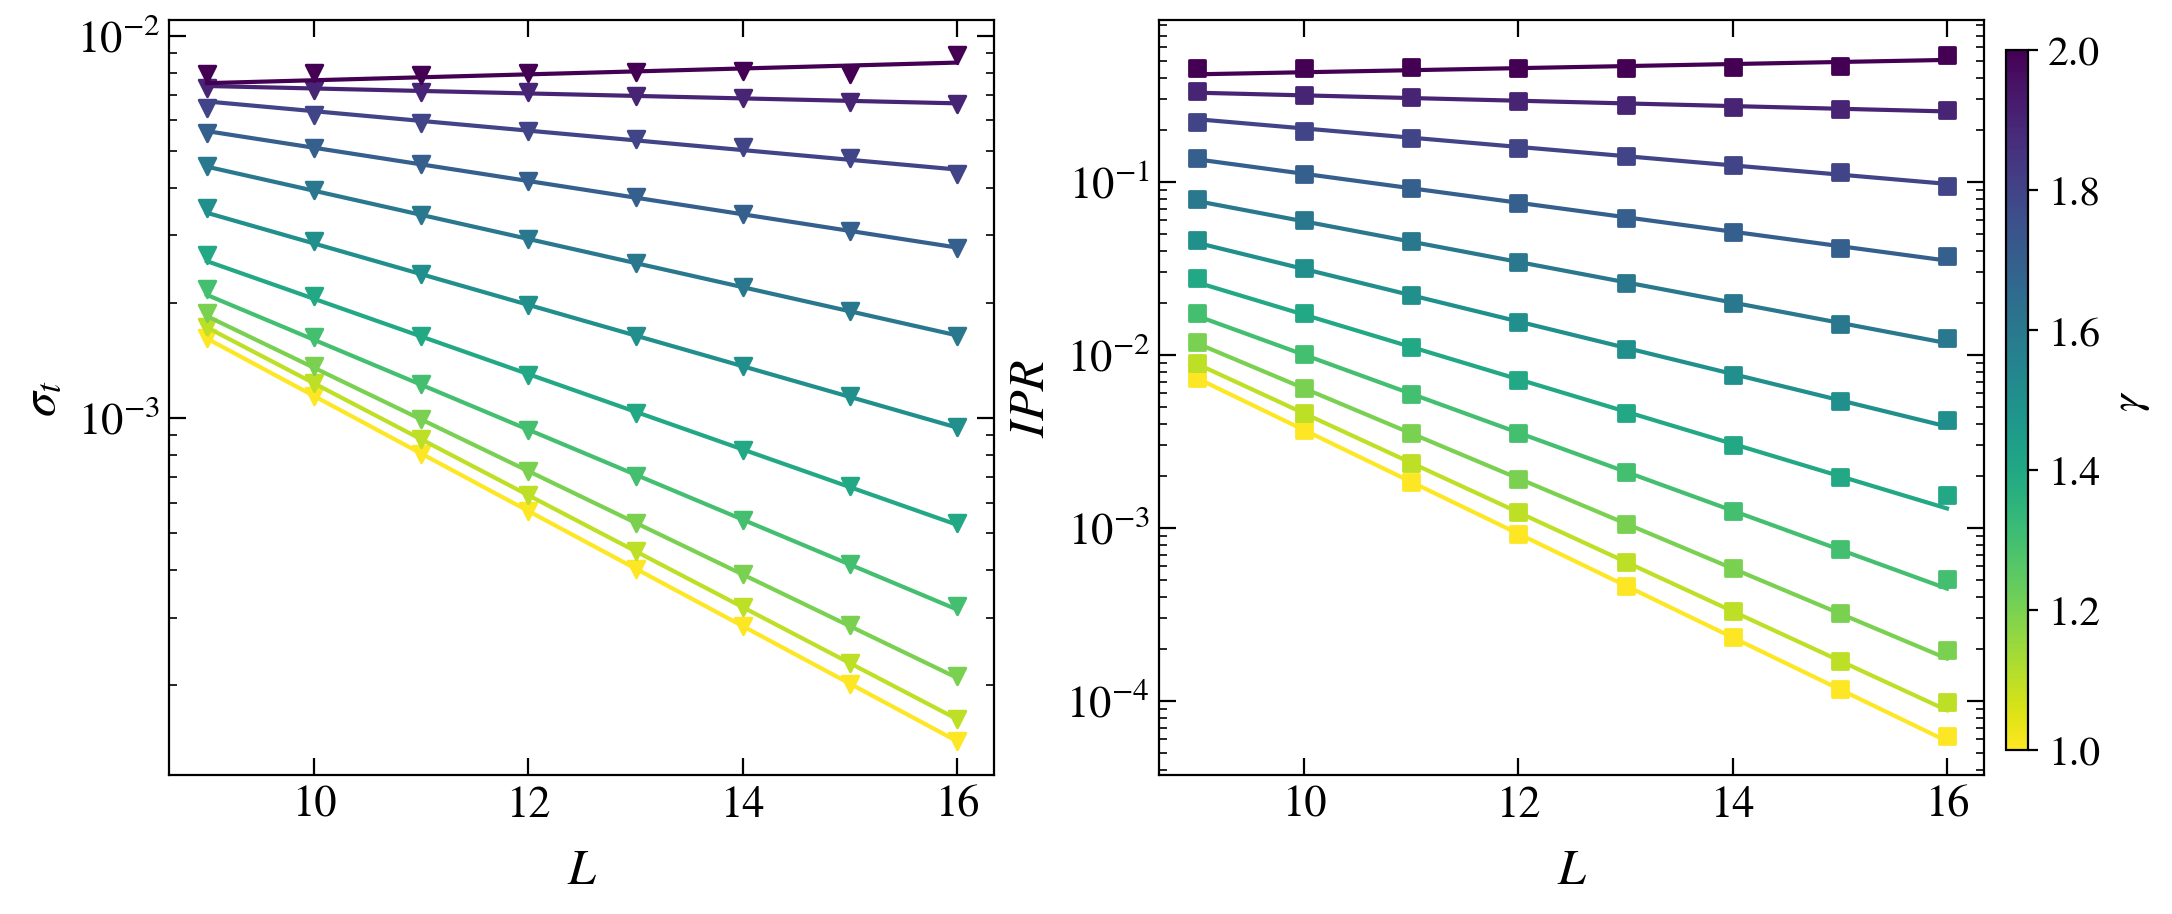

In [ ]:


L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(9, 17, 1)

DIM = 1
fig_end, axes = plt.subplots( nrows=1, ncols=1, figsize=(5,3.5), dpi = 200)
figoshi, axisshi = plt.subplots( nrows=1, ncols=2, figsize=(6,3), dpi = 200)
ax1 = axisshi[0];   ax2 = axisshi[1]
# fig_end = plt.figure(figsize=(7.5,4), dpi = 300)
# gs = GridSpec(nrows=2, ncols=2, width_ratios=[3, 2])
# axes = fig_end.add_subplot(gs[:,0])
# ax = fig_end.add_subplot(gs[0,1])
# ax2 = fig_end.add_subplot(gs[1,1])

fig, axis1 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)
fig2, axis2 = plt.subplots( nrows=1, ncols=2, figsize=(11,5), dpi = 200)

axis = [*axis1, *axis2]

# gammas = np.array( [*np.arange(0.5, 2.0, 0.1), *np.arange(2.1, 2.2, 0.1)] )
gammas = np.arange(1, 2.01, 0.1)
g_crit = 2
alfac = 1 / np.sqrt(2)

print(gammas)

norm = matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis_r', norm=norm)
s_m.set_array([])


def fading_erg(x, eta, a):
    return a * 2**(-x * eta)

def fading_loc(x, eta, a):
    return a * 2**(x * eta)


qs = np.array( [0.5, 1.0, 1.5, 2.0, 3.0] )
q = 2

colors = []
eta_fluct = []
eta_ipr = []

handles = []
handles2 = []
gammas_plot = [1.4, 1.6]
# ------------------------------------------------------------ ROZENZWEIG-PORTER~
eps = 0.5
for iia, gx in enumerate(gammas):
    name_out = prefix +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    col = s_m.to_rgba(gx)
    colors.append(col)
    
    fading_fit = fading_erg #if gx <= g_crit else fading_loc
    

    typ_susc = np.zeros(sizes.shape)
    wH_typ = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for ii, L in enumerate(sizes):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if not exists(name):
        #     name = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - 0.5))
                    
                typ_susc[ii] = 1/np.array(file.get('TYP_SUSC'))[-2]
                wH_typ[ii] = np.array(file.get('wH_typ'))[-2]
    tH = 2 * np.pi / wH_typ
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            # print(sizes, np.array(file.get('sizes'))[3:])
            sizes = np.array(file.get('sizes'))[3:]
            realis = np.array(file.get('realisations'))[3:]
            idx = np.argmin( np.abs(Ex - eps) )
            ipr = np.array(file.get('ipr'))[np.argmin(np.abs(qs - q))][3:]
            temp_fluct = np.zeros(sizes.shape)
            for ii, L in enumerate(sizes):
                times= np.array(file.get('TIMES/L=%d'%L))#[:-50]
                idx1 = np.argmin( np.abs(times - tH[ii] * 5))
                idx2 = np.argmin( np.abs(times - tH[ii] * 5))
                sig = np.array(file.get('temporal fluctuations'))[3 + ii]
                temp_fluct[ii] = np.mean( sig[idx1 : -100] )**0.5
            # temp_fluct = np.zeros(sizes.shape)
            axis[2].scatter(sizes, temp_fluct, color=col, marker='v')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[~np.isnan(temp_fluct)][-6:],
                            ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                            full_output=True, maxfev=10000)
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[2].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            # print(gx, *pars)
            _etaX_ = pars[0]
            if _etaX_ > 1e6 or gx >= 2.5: 
                _etaX_ = np.nan
            eta_fluct.append(_etaX_)
            
            axis[3].scatter(sizes, ipr, color=col, marker='s')
            pars, pconv, fit_info, msg, _ = fit(fading_fit,
                            xdata = sizes[-6:],
                            ydata = ipr[-6:],
                            full_output=True, maxfev=10000)
            # print(J, alfa, fit_info['fvec'])
            dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
            axis[3].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            print(gx, pars[1], gamma_fun(q - 0.5) * gamma_fun(q + 0.5) / gamma_fun(q) / np.pi / np.sqrt(np.pi / 8)**(2*q-2))
            _etaX_ = (pars[0])
            if _etaX_ > 1e6: _etaX_ = np.nan
            eta_ipr.append(_etaX_)
            
            ax.scatter(sizes, temp_fluct**2 / ipr, marker='v', color=col)
    else:   
        print(name_out)


eta_fluct   = 2*np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr) / (q-1)
print("RP:  AAAA", eta_fluct)
print("RP:  BBBB", eta_ipr)
colors_ls_cyc = itertools.cycle(colors_ls)
line = axes.scatter(gammas, eta_fluct, marker='v', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10)
handles.append(line)

line = axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
handles.append(line)

fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

axes2 = axes.twiny()
# ------------------------------------------------------------ ULTRAMETRIC MODEL
eta_fluct = []
eta_ipr = []
sizes = np.arange(9, 17, 1)
alfas = np.arange(0.7, 0.99, 0.02)
norm = matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas))
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=norm)
s_m.set_array([])

for iia, alfa in enumerate(alfas):
    col = s_m.to_rgba(alfa)
    temp_fluct = np.zeros((sizes.size))
    for ii, L in enumerate(sizes):
        name_out = "./UM results/energies/_Ngrain=1/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                tH = 2 * np.pi / np.array(file.get('mean_lvl/0.50/mean'))[idxa]
        else:
            print(name_out)
        name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 5e-3:
                    print(alfa, name_out)
                    continue
                times = np.array(file.get('Sz/0/ME/fluct/%d/times'%(idxa) ))
                idx1 = np.argmin( np.abs(times - tH))
                # temp_fluct[ii] = np.mean(np.array(file.get('Sz/0/ME/fluct/%d/mean'%(idxa) ))[idx1 : -100]**2)
                temp_fluct[ii] = np.array(file.get('Sz/0/ME/stat/lt/evo/fluct'))[idxa]
        else:
            print(name_out)
    
    line = axis[0].scatter(sizes, temp_fluct, color=col, marker='v', facecolor='None')
    pars, pconv, fit_info, msg, _ = fit(fading_fit,
                    xdata = sizes[~np.isnan(temp_fluct)][-6:],
                    ydata = temp_fluct[~np.isnan(temp_fluct)][-6:],
                    full_output=True, maxfev=10000)
    # print(J, alfa, fit_info['fvec'])
    dense_sizes = np.linspace(sizes[0], sizes[-1], 10000)
    axis[0].plot(dense_sizes, fading_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
    # print(gx, *pars)
    _etaX_ = pars[0]
    if _etaX_ > 1e6 or gx >= 2.5: 
        _etaX_ = np.nan
    eta_fluct.append(_etaX_)
    name_out = "./UM results/fractal/_Ngrain=1/fractal_dimension.h5"
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            Ns = np.array(file.get('4/a=%.3f/Ns'%alfa))
            d2 = np.array(file.get('4/a=%.3f/q=2.00'%alfa))
            # d2 = (16*d2[-1] + 15*d2[-2] + 14*d2[-4]+ 13*d2[-4]) / 4
            d2 = np.sum(Ns[-4:] * d2[-4:]) / np.sum(Ns[-4:])
            eta_ipr.append(d2)
    else:
        print(name_out)
        eta_ipr.append(np.nan)
    
_gammas_ = 1 + np.log(alfas) / np.log(alfac) 
eta_fluct   = np.array(eta_fluct)
eta_ipr     = np.array(eta_ipr)
print("UM:  AAAA", eta_fluct)
print("UM:  BBBB", eta_ipr)
line = axes.scatter(_gammas_, eta_fluct, marker='o', color=next(colors_ls_cyc), label=r"$\sigma_t$", zorder=10, facecolor='None')
handles.append(line)
line = axes.scatter(_gammas_, eta_ipr, marker='D', color=next(colors_ls_cyc), label=r"$d_2$", zorder=10, facecolor='None')
handles.append(line)
# axes.scatter(gammas, eta_ipr, marker='s', color=next(colors_ls_cyc), label=r"$d_2$", zorder=4)
# fig_help.set_plot_elements(axis[0], ylabel=r"$\mathcal{Q}_{\infty}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[0], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$IRP$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[3], ylabel=r"$IPR$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1,           xscale='linear', yscale='log')

line, = axes.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axes.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([4,2, 3, 5, 0, 1])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    

xx = np.linspace(1, g_crit-0.0, 1000)
axes.plot(xx, (2 - xx), ls='-', color='k')
xx = np.linspace(2, max(gammas), 1000)
axes.plot(xx, [0]*xx.size, ls='-', color='k')
axes.axhline(y=1, xmax=0.4, ls='--', color='gray')

fig_help.set_plot_elements(axes2, ylabel=r"", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axes, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')

fig_help.set_legend(axes, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))
axes.set_ylabel(r"$\frac{2}{\eta}$", rotation=0, fontsize=18)
axes.yaxis.set_label_coords(-0.16, 0.5)
axes.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axes2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

fig_help.set_plot_elements(ax, ylabel=r"$P_2,\sigma_t$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# fig_help.set_legend(ax, fontsize=15, loc='lower left', ncol = 2, handles = _handle_shit, columnspacing=0.6)#, anchor=(0.88, 1.02))

axes.set_xlim(1, 2.0)
axes.set_xticks([1, 1.25, 1.5, 1.75, 2])

ax1Ticks = axes.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return [("%g" % z if z == 1 else "%.3f"%z) for z in V]

axes2.set_xticks(ax2Ticks)
axes2.set_xbound(axes.get_xbound())
axes2.set_xticklabels(tick_function(ax2Ticks))

axes.set_ylim(-0.1, 1.05)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.2, hspace=0.2)
fig2.subplots_adjust(wspace = 0.2, hspace=0.2)
# fig2.savefig("PLOTS_FADING/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)
fig_end.subplots_adjust(wspace = 0.3, hspace=0.02)

axes.xaxis.set_label_coords(.62, 1.13)
axes2.xaxis.set_label_coords(.62, -0.13)

fig_end.savefig("PLOTS_FADING/ANOMALOUS/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

## FOURIER ANALYSIS

No handles with labels found to put in legend.


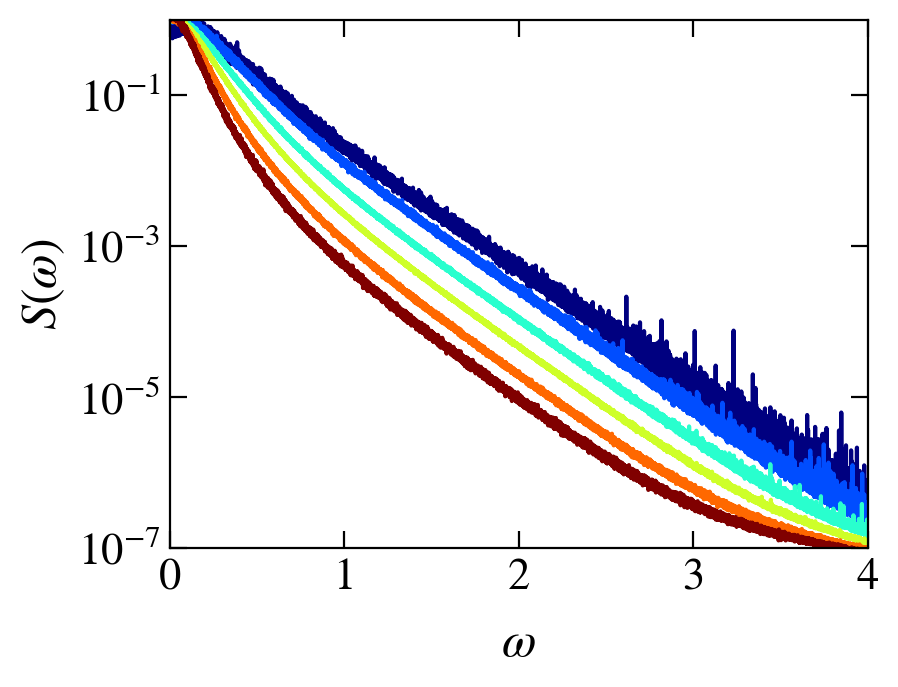

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 14, 1)
gammas = np.arange(0.0, 2.9, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

gx = 1.3
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**L
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            wH = np.array(file.get('wH'))[-2]
    else:
        print(name_out)
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            T = times[1] - times[0]
            N = times.size
            # print(times[1] - times[0], times.size)
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            # power_spectrum  = np.array(file.get('fourier series'))[1:]**2
            power_spectrum  = np.array(file.get('power spectrum'))[1:] / T**2 * N
            # power_spectrum  = np.array(file.get('power spectrum'))[1:]
            # power_spectrum = power_spectrum# * dim**(2-gx)
            # print(omegas.shape, power_spectrum.shape)
            # axis.axvline(x=wH, ls=':', color=col)
            power_spectrum = power_spectrum[omegas > wH]# * dim**(2-gx)
            omegas = omegas[omegas > wH]
            
            long_time = np.mean(power_spectrum[-100:])
            power_spectrum = (power_spectrum - long_time) / (power_spectrum[0] - long_time)
            axis.plot(omegas, (power_spectrum), color=col)
# axis.plot(omegas, _resc_(omegas, 1/omegas**4, power_spectrum), ls='--', color='k')
# x = np.logspace(-0, 2.5, 100)
# axis.plot(x, 0.01/x**1.4, ls='--', color='k')
# axis.plot(x, 0.0025/x**1, ls='--', color='red')
axis.set_xlim(0., 4)
axis.set_ylim(1e-7, 1)

fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='linear', yscale='log')

No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.31656187515181955 0.9972442503882425
0.3736852922156686 1.043953281487425
0.41048552983556874 1.0657089626542569
0.4302945294548408 1.075474984591789
0.4398608984265593 1.079785820833116
0.4442290099323145 1.0816744761471073
0.4461714229473728 1.082499248776574
0.4470249034857261 1.0828588232600511
0.44739793552435003 1.0830154372704148
0.44756059911014745 1.0830836127687344
0.44763145798788173 1.0831132560025623


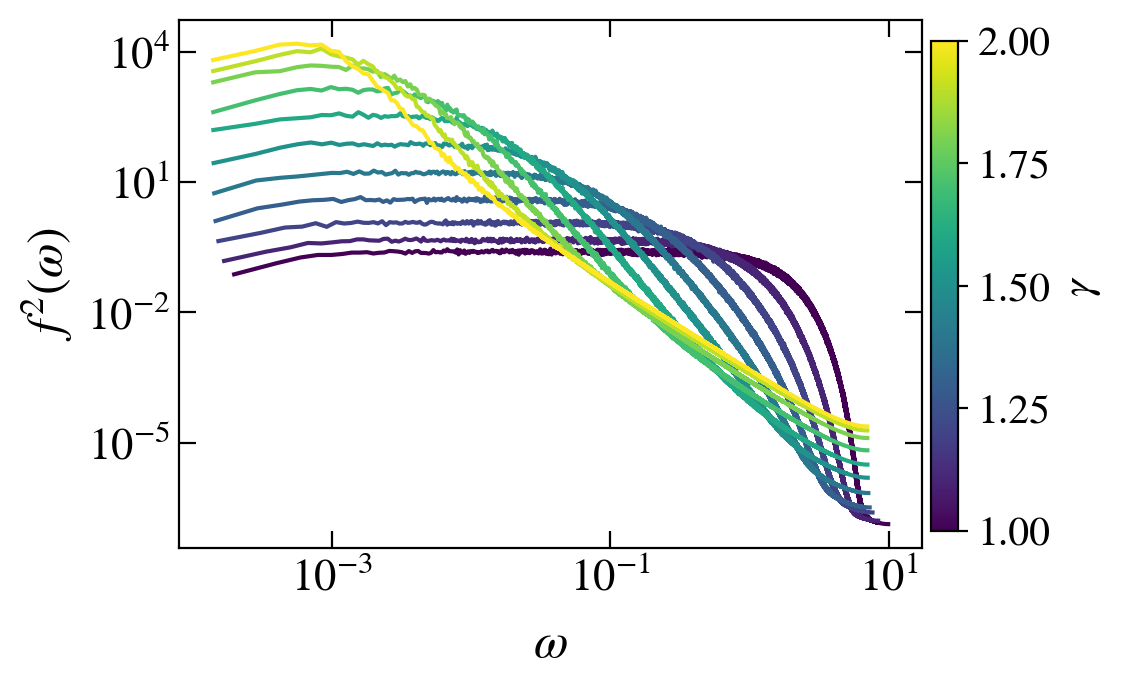

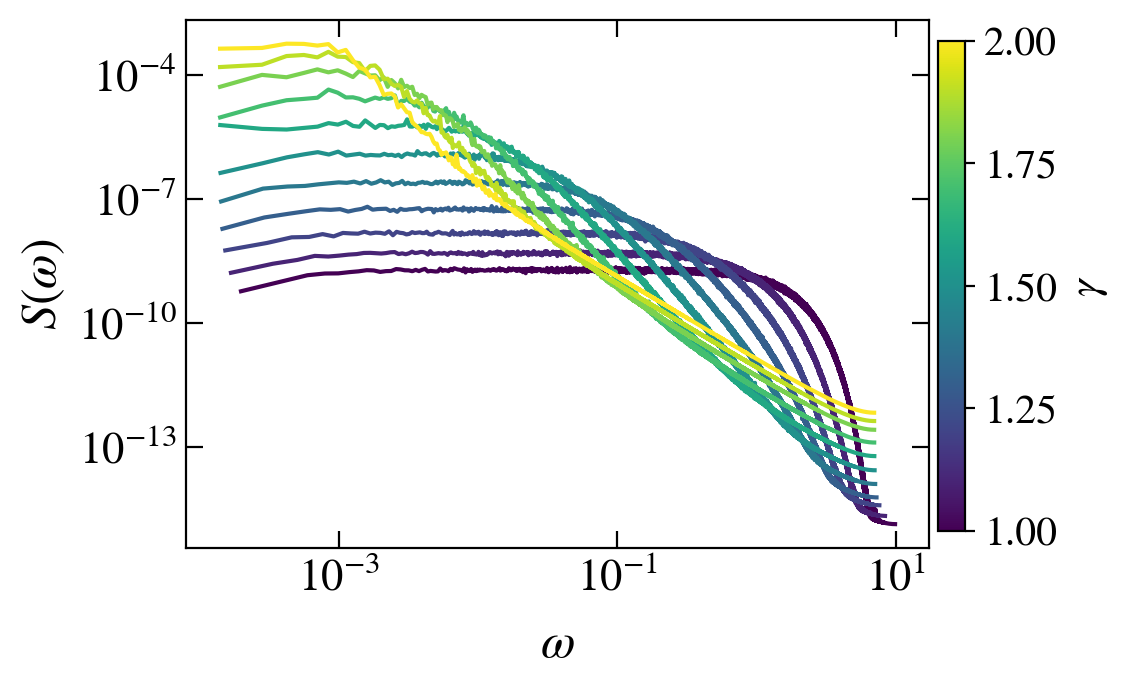

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.1, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 2.8
for gx in gammas:
    col = s_m.to_rgba(gx)
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            bandwidth = np.mean(file.get('bandwidth'))
    else:
        print(name_out)
    dim = 2**L
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            print(times[-1] - times[-2], 1.25 * 2 * np.pi / bandwidth)
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            fourier  = (np.array(file.get('fourier series'))[1:] * dim)**2
            axis.plot(omegas, fourier, color=col)
            # axis.axvline(x=bandwidth, color=col, ls=':')
            
            power  = np.array(file.get('power spectrum'))[1:]
            axis2.plot(omegas, power, color=col)
    else:
        print(name_out)       
# axis.plot(omegas, _resc_(omegas, 1/omegas**2, fourier), ls='--', color='k')
# axis.plot(omegas, _resc_(omegas, 1/omegas**4, fourier)/100, ls='--', color='red')

# x = np.logspace(-1, 1, 100)
# # axis2.plot(x, 1e-10/x**4, ls='--', color='red')
# axis2.plot(x, 0.003/x**1, ls='--', color='red')

for fig in [fig, fig2]:
    fig.subplots_adjust(right=0.95)
    cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
    cbar.set_label(r"$\gamma$", fontsize=16)
    cbar.ax.tick_params(labelsize=15)

    fig.subplots_adjust(wspace = 0.15, hspace=0.12)
    
fig_help.set_plot_elements(axis, ylabel=r"$f^2(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

No handles with labels found to put in legend.


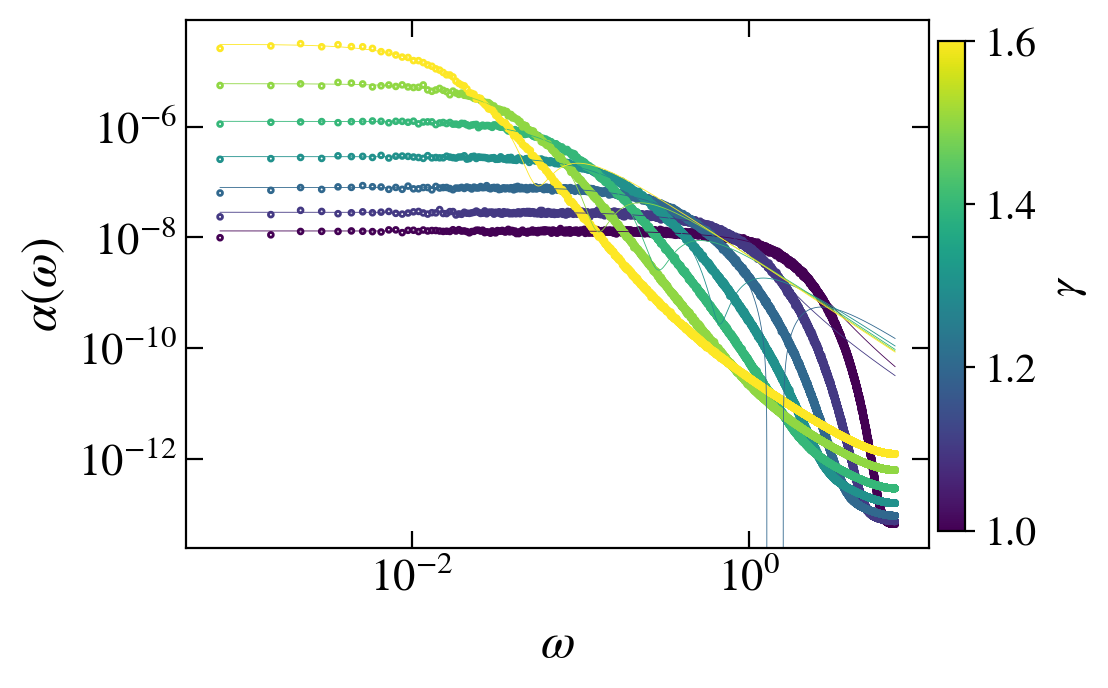

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 1.6, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

def one_over_f(f, alpha, scale):
    return scale / (f ** alpha)

def some_shit(f, A, g1, B, g2):
    return A / (1 + (f / g1)**2) + B / (1 + (f / g2)**4)

window_size = 10
gx = 2.8
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            fourier  = np.array(file.get('fourier series'))[1:]
            power  = np.array(file.get('power spectrum'))[1:]
            N = omegas.size
            
            axis.scatter(omegas, power, color=col, s=3, facecolor='None')
            # omegas = omegas[window_size//2:-window_size//2]
            # power = tools.remove_fluctuations(power, window_size)[window_size//2:-window_size//2]
            pars, pconv = fit(some_shit,
                                    xdata = omegas[:-power.size//2],
                                    ydata = power[:-power.size//2],
                                    maxfev=10000)
            axis.plot(omegas, some_shit(omegas, *pars), color=col, lw=0.3)
            # axis.scatter(omegas[1:-1], -diff_central(np.log(omegas), np.log(power)), color=col, s=3)
            # xt = np.zeros((N // window_size))
            # alfat = np.zeros((N // window_size))
            # for ii in range(N//window_size):
            #     idx_min = window_size * ii
            #     idx_max = window_size * (ii+1)
            #     try:
            #         pars, pconv = fit(one_over_f,
            #                         xdata = omegas[idx_min : idx_max],
            #                         ydata = power[idx_min : idx_max],
            #                         maxfev=10000)
            #         xt[ii] = omegas[window_size * ii + window_size//2]
            #         alfat[ii] = np.abs(pars[0])
            #     except RuntimeError:
            #         fnsodaz=1
            
            # # print(alfat)
            # axis.scatter(xt, alfat, color=col, s=3)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.15, hspace=0.12)   
# x = np.logspace(-4, -0.5, 100)
# axis.plot(x, 0.0001/x**1.25, ls='--', color='k')
# axis.plot(x, 0.0003/x**1, ls='--', color='red')
# axis.set_ylim(0, 5)
fig_help.set_plot_elements(axis, ylabel=r"$\alpha(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

45538.77490990786 51395.8345554899 |||| 7.935518960962374 7.731983399509674


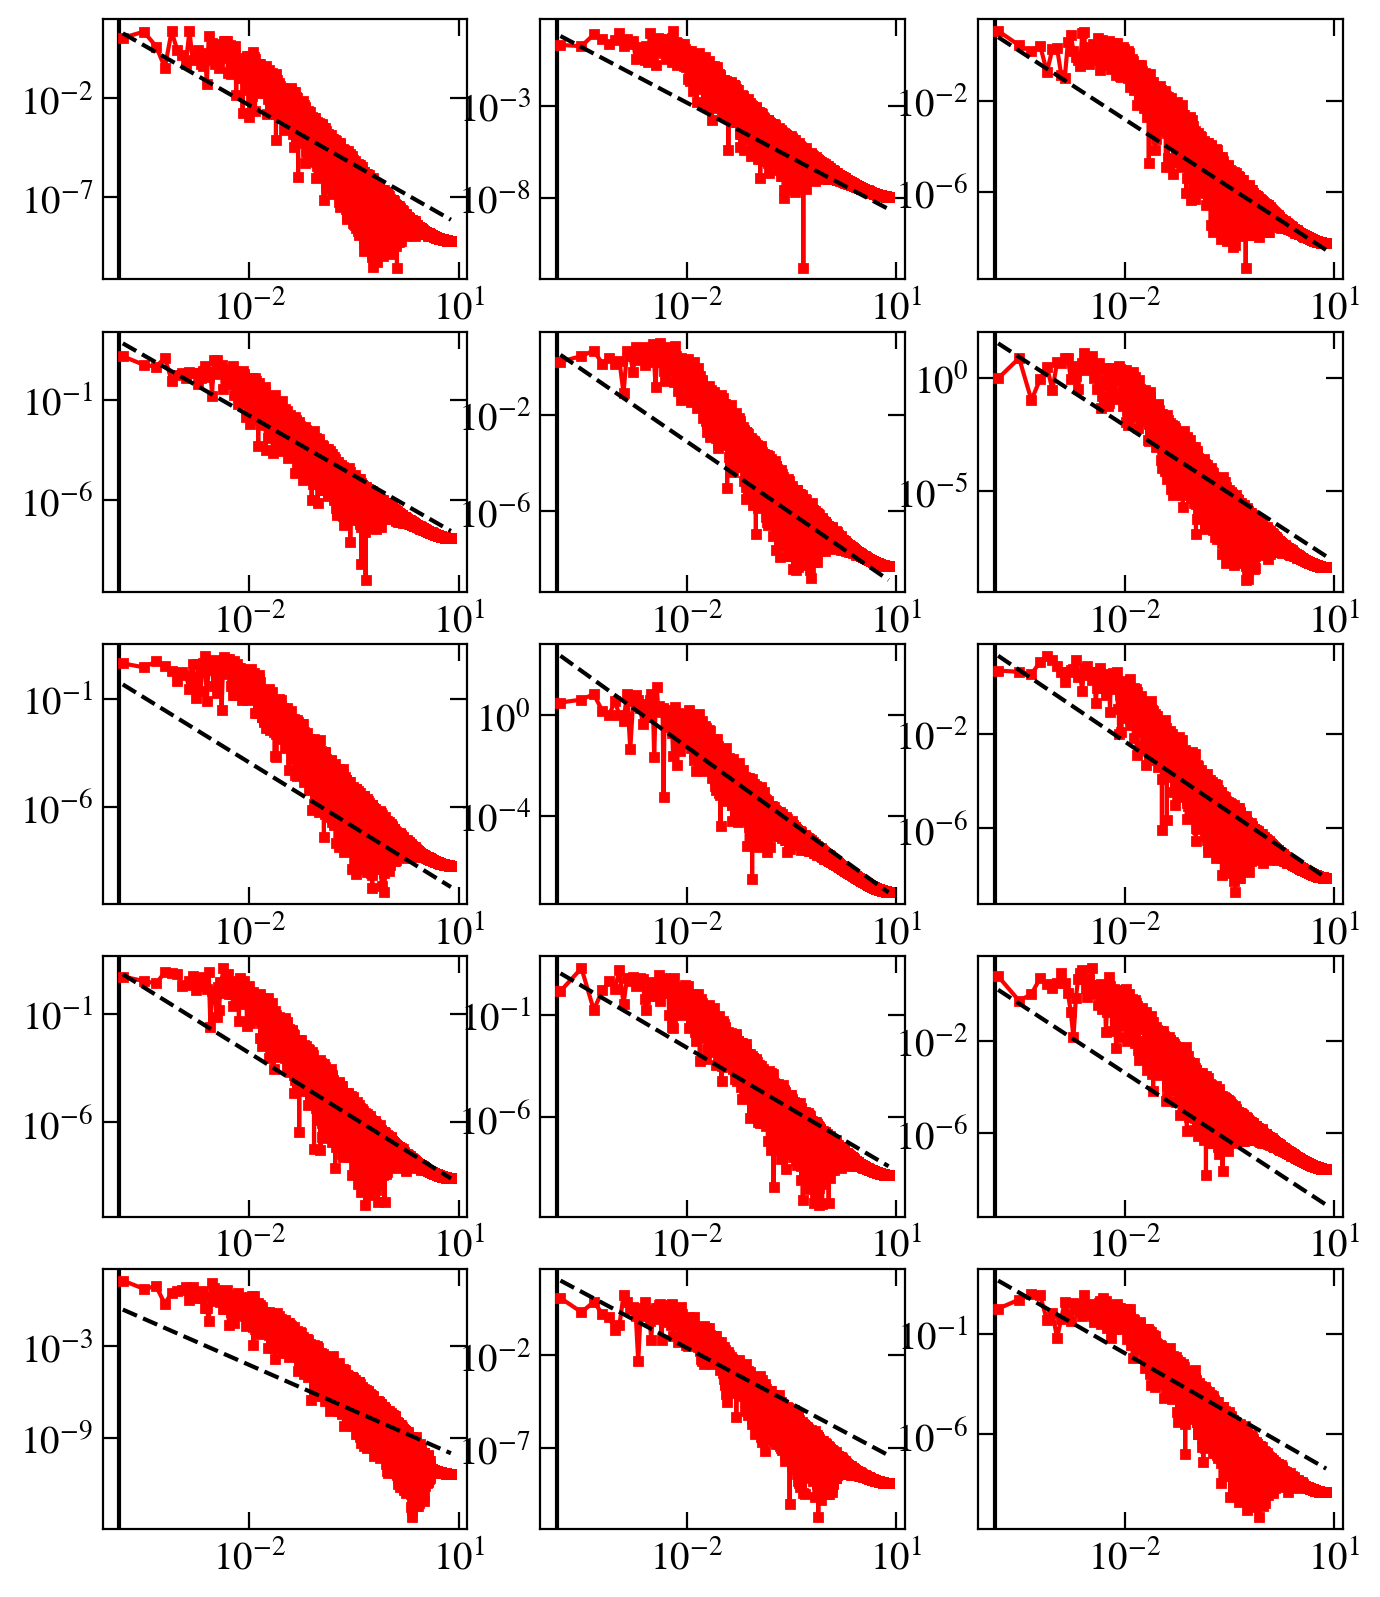

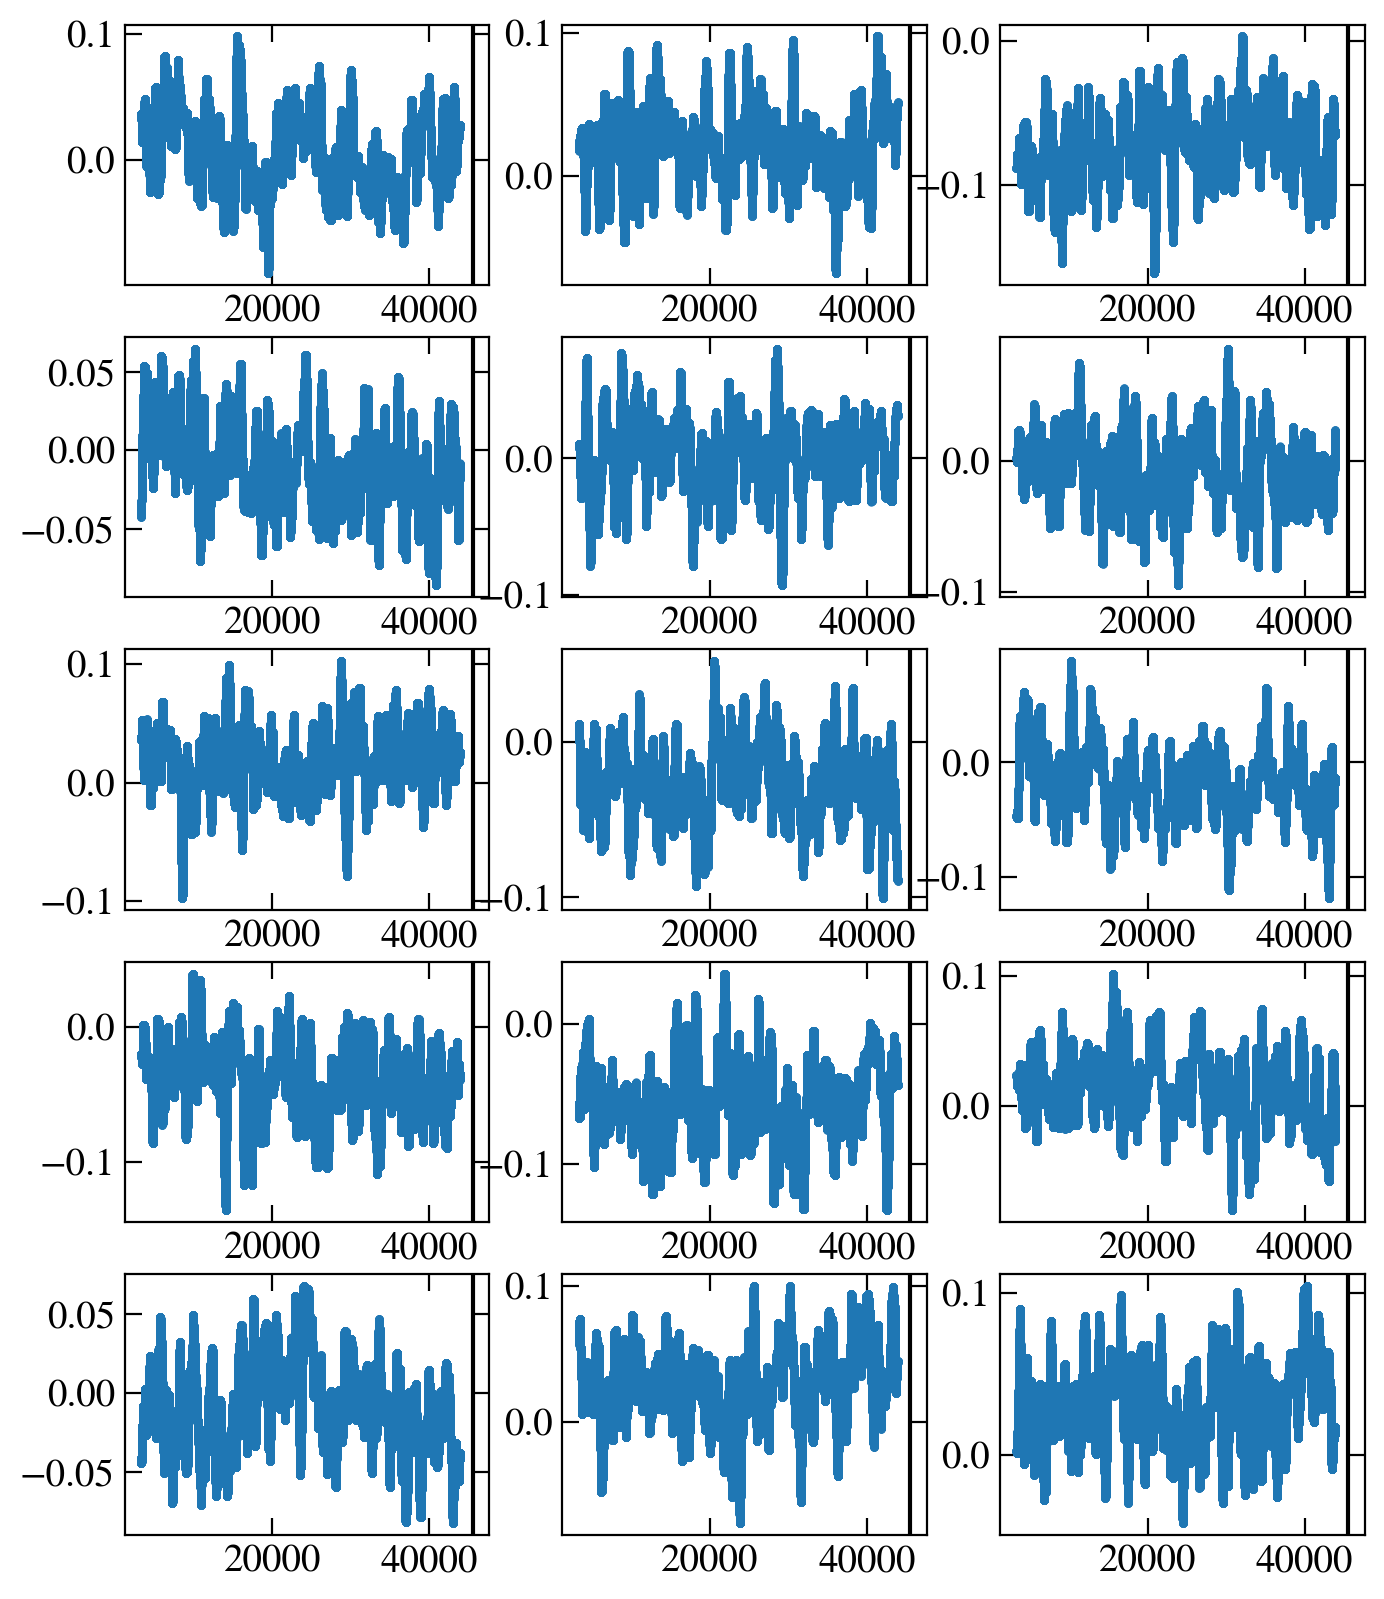

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
from scipy import signal


L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.1)
from scipy.signal.windows import blackman
w = blackman(N)

DIM = 1

nrows = 5
fig, axis = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis = axis.flatten()

fig_raw, axis_raw = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis_raw = axis_raw.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.6
L = 14
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)
for ii, ax in enumerate(axis_raw):
    ax.axvline(x=tH, ls='-', color='k')
    axis[ii].axvline(x=wH, ls='-', color='k')
    
    
name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        times  = np.array(file.get('times'))
        T = times[1] - times[0]
        N = times.size
        Q_raw  = np.array(file.get('quench data'))
        for ii, ax in enumerate(axis_raw):
            ax.plot(times, Q_raw[ii], lw=1, marker='o', markersize=2)
            
            xf = 2 * np.pi * fftfreq(N, T)[1:N//2]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw[ii])[1:N//2]) )**2
            # xf, yf = signal.welch(Q_raw[ii], 1/T, scaling='spectrum', average='median')

            # print(T, times[-1] - times[0], np.min(xf))
            axis[ii].plot(xf, yf, color='red', marker='s', markersize=3)
            
            axis[ii].plot(xf, _resc_(xf, 1/xf**2, yf), ls='--', color='k')
            # axis[ii].plot(xf, _resc_(1/xf**1), ls=':', color='blue')
for ii, ax in enumerate(axis_raw):
    fig_help.set_plot_elements(ax, ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[ii], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

## DISTRIBUTION OF LONG-TIME VALUES

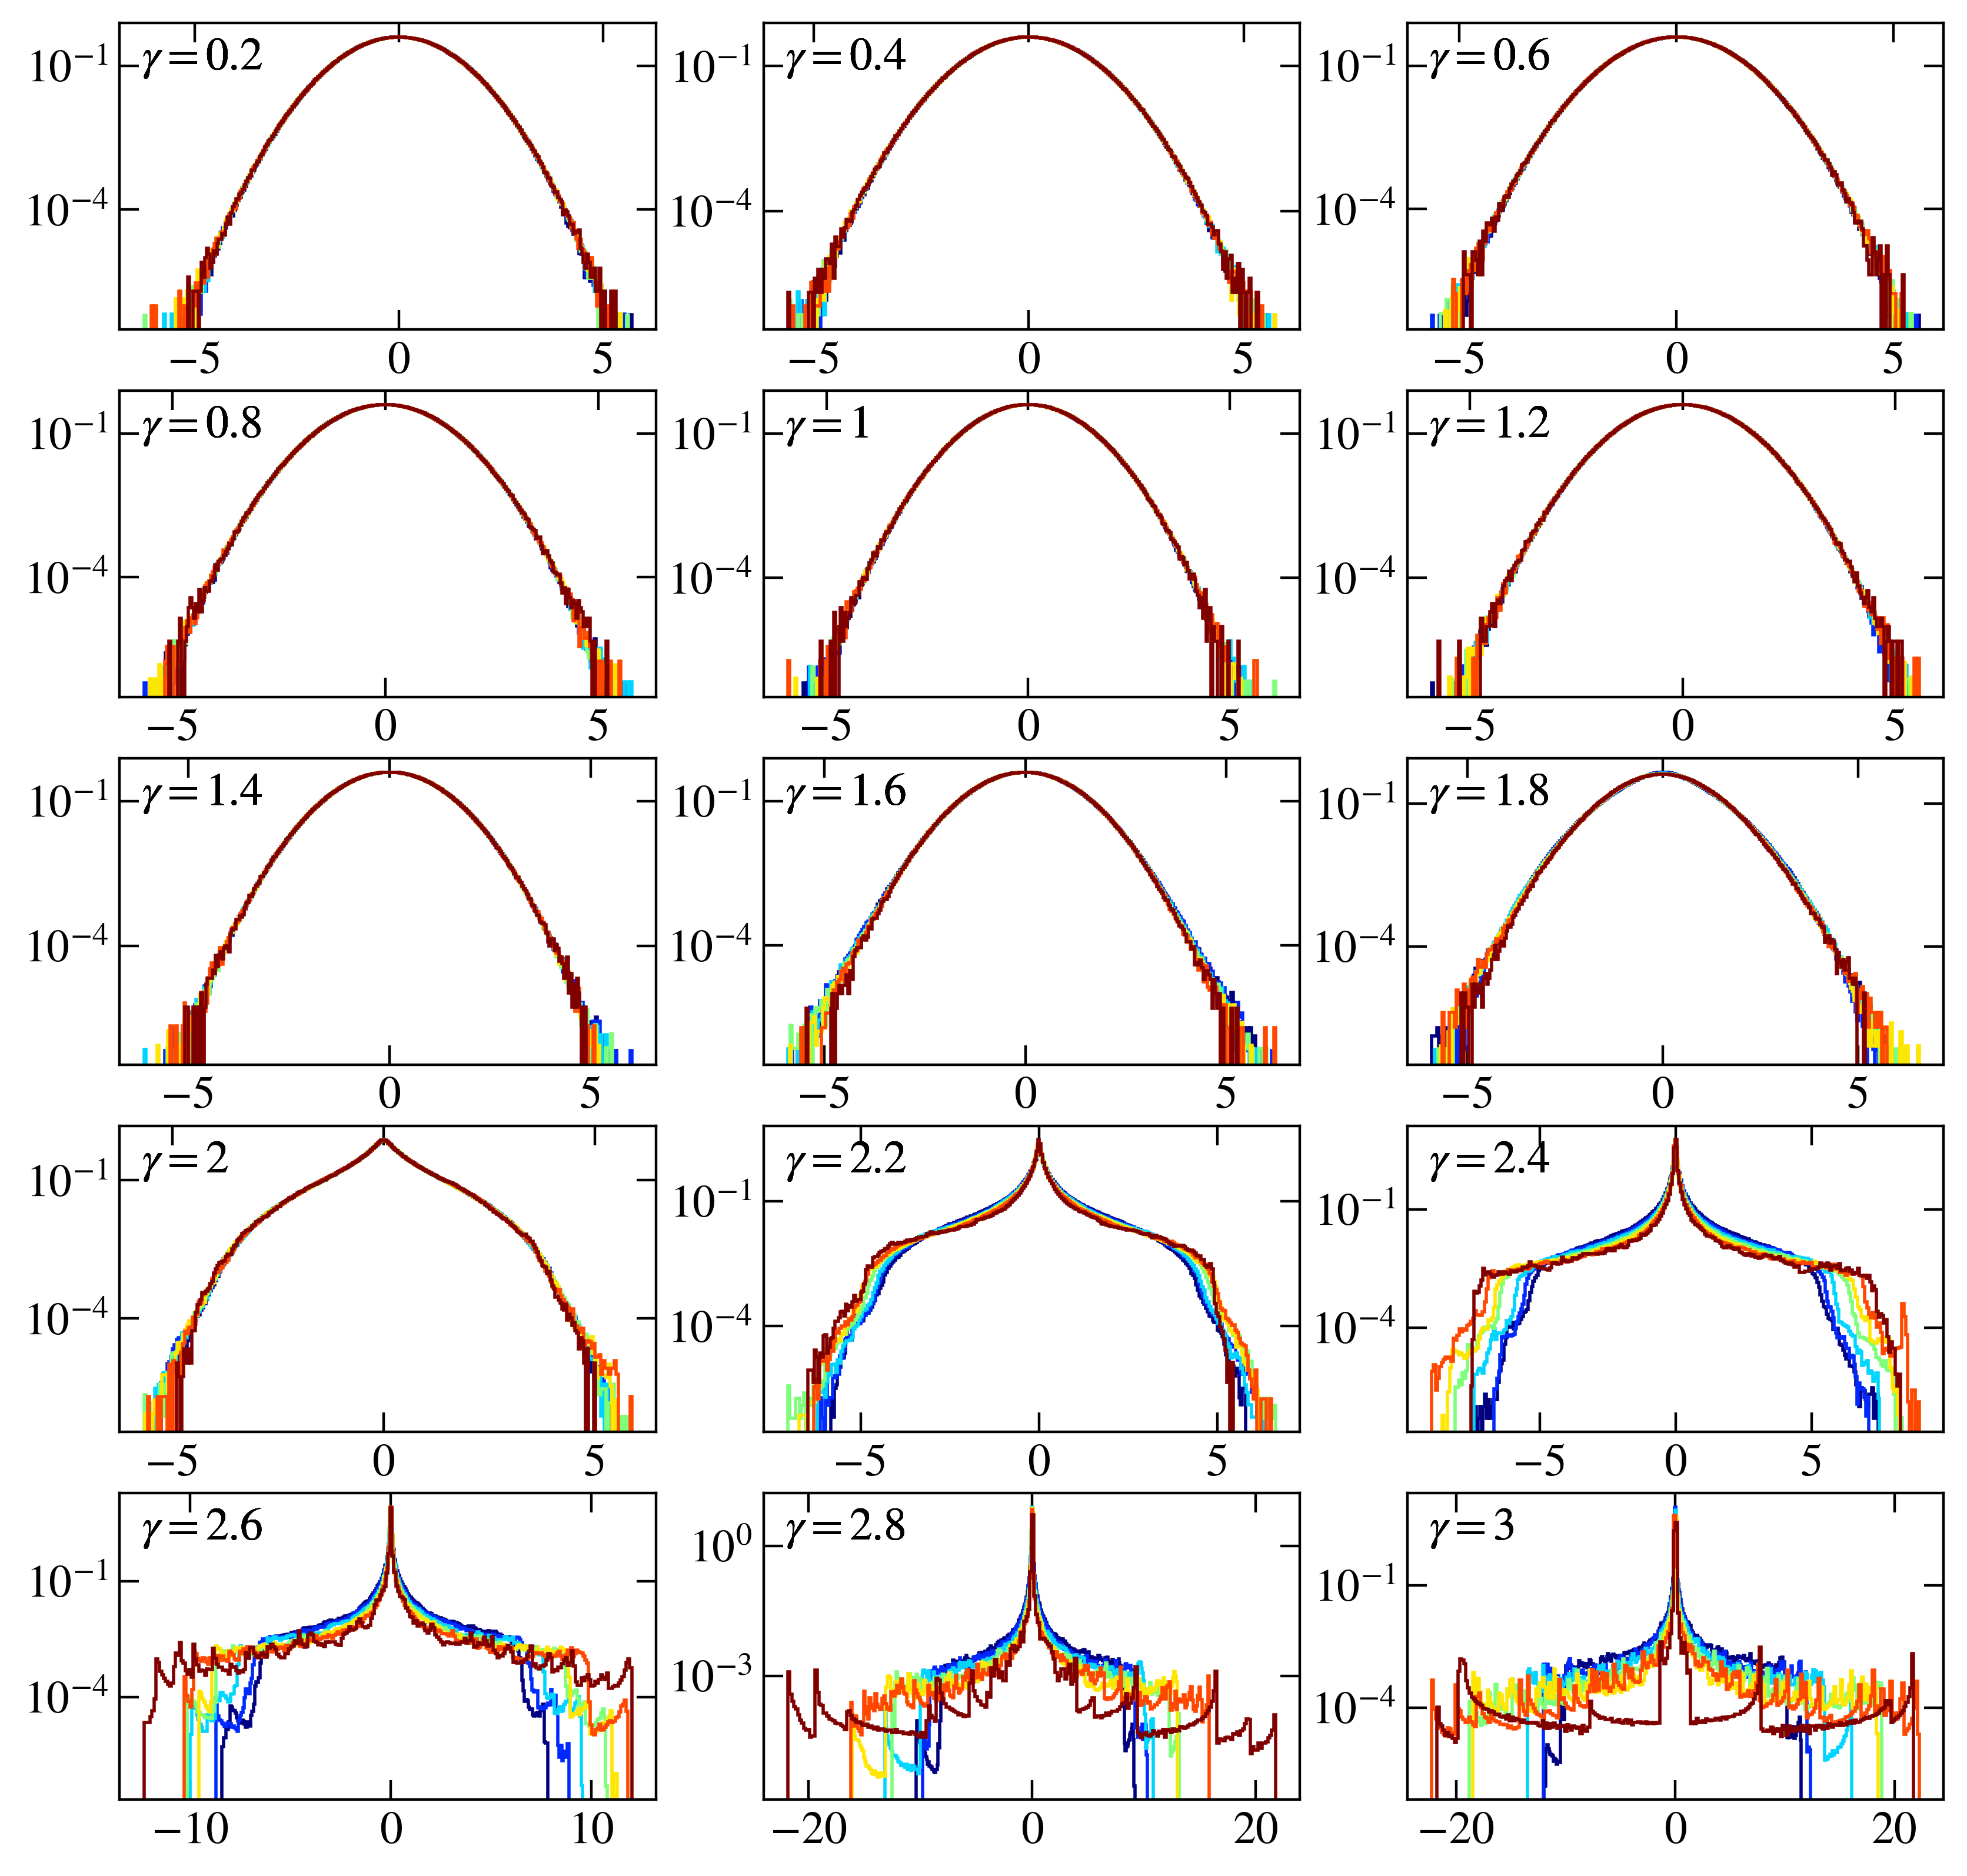

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.2, 3.1, 0.2)
fig, axis = plt.subplots( nrows=5, ncols=3, figsize=(10,10), dpi = 400, sharex=False, sharey=False)
axis = axis.flatten()
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for iig, gx in enumerate(gammas):
    d2 = 1 if gx <= 1 else 2 - gx
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = 2**L
        # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if exists(name_out):
        #     with h5py.File(name_out, "r") as file:
        #         sec_mom = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
        #         bins  = np.array(file.get('fluct_bins_log')) - np.log(sec_mom)
        #         dist  = np.array(file.get('fluct_hist_log'))# * sec_mom
        #         axis[iig].stairs(dist, bins, color=col)
        # else:
        #     print(name_out)
        
        name_out = base_dir(model=modello, d=DIM) + 'Quench/' +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                sec_mom = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2)
                bins = np.array(file.get('LTVALS/L=%d/bins'%L))# / sec_mom
                hist = np.array(file.get('LTVALS/L=%d/hist'%L))# * sec_mom
                axis[iig].stairs(hist, bins, color=col)
                
        axis[iig].annotate(r" $\gamma=%g$"%gx, fontsize=14, xy=(0.02, 0.85), xycoords='axes fraction')
    # axis[iig].plot(bins, np.exp(-bins**2) / np.sqrt(np.pi), color='k', ls='--')
    fig_help.set_plot_elements(axis[iig], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='log')
    # axis[iig].set_xlim(-4, None)

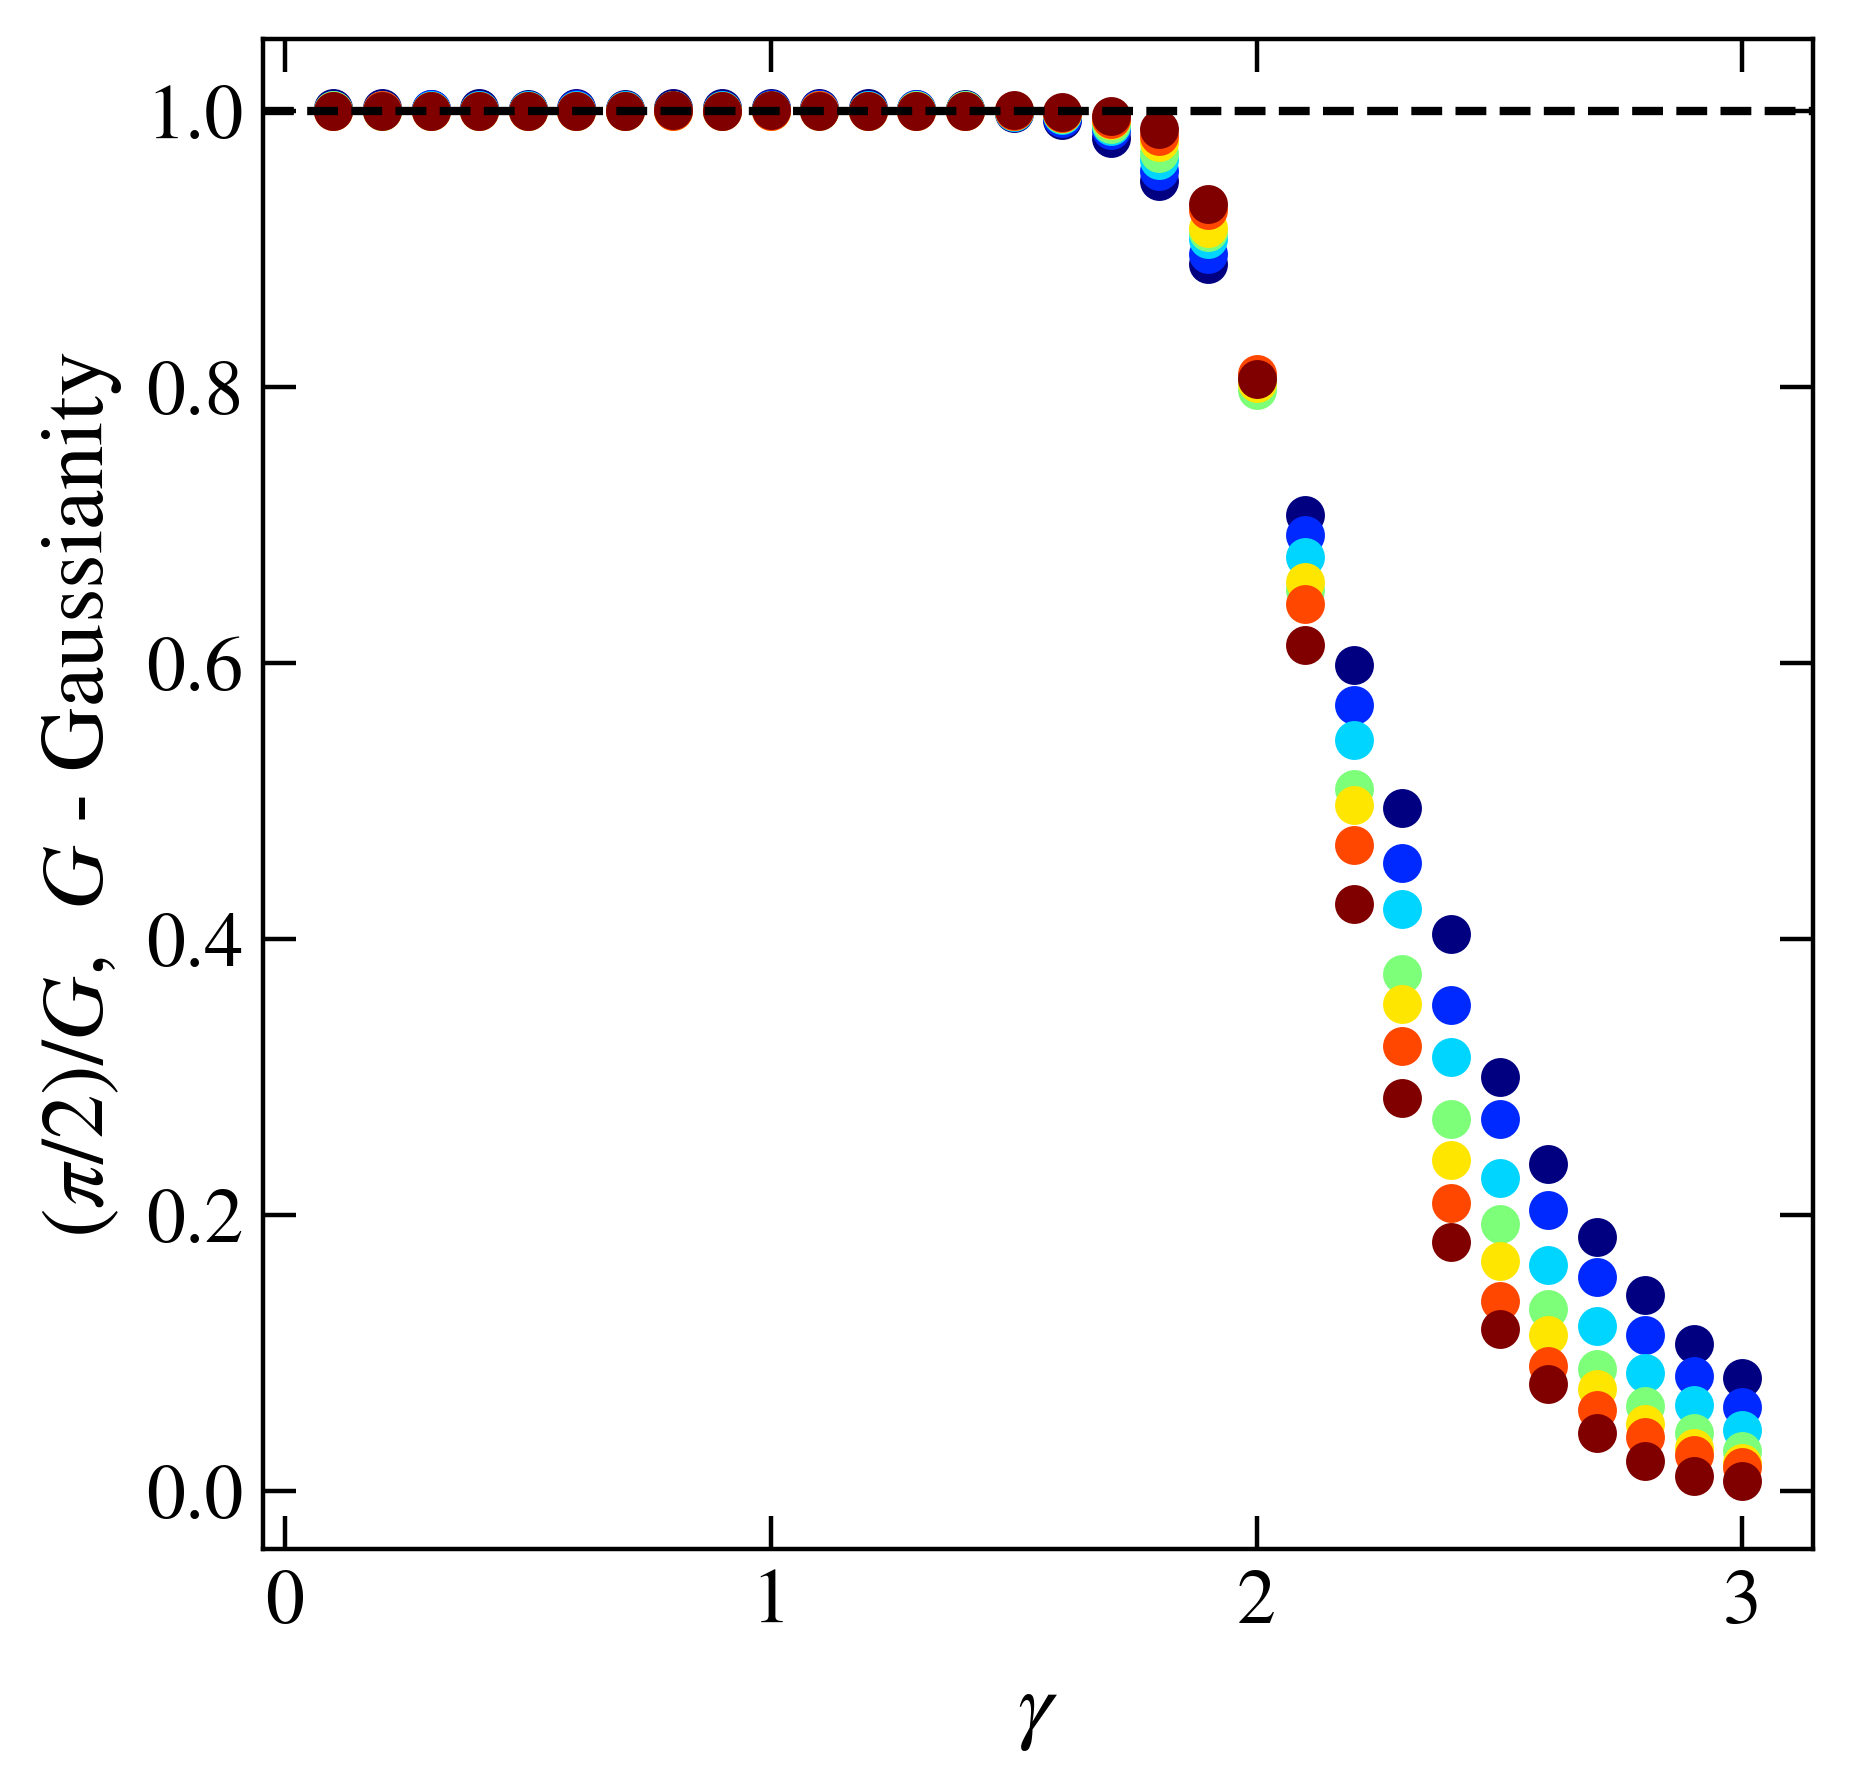

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 15, 1)

DIM = 1
gammas = np.arange(0.1, 3.01, 0.1)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 400, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for L in sizes:
    col = s_m.to_rgba(L)
    gauss = np.zeros(gammas.shape);gauss.fill(np.nan)
    for iig, gx in enumerate(gammas):
        dim = 2**L
        # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                try:
                    gauss[iig] = np.array(file.get('LTVALS/L=%d/gauss'%L))
                except TypeError:
                    aadsada=1
        else:
            print(name_out)
    axis.scatter(gammas, np.pi/2/gauss, color=col)
    # axis.scatter(gammas, np.abs( gauss - np.pi/2 ), color=col)
axis.axhline(y=1, ls='--', color='k')
fig_help.set_plot_elements(axis, ylabel=r"$(\pi/2)/G$,  $G$ - Gaussianity", xlabel=r"$\gamma$", font_size=14, set_legend=0, xscale='linear', yscale='linear')

In [1190]:
536870910 / 2**15

16383.999938964844

## FOURIER ANALYSIS

In [1312]:
def _resc_(xdat, data, new_dat):
    idx = xdat.size // 50
    return data / data[idx] * new_dat[idx]

No handles with labels found to put in legend.


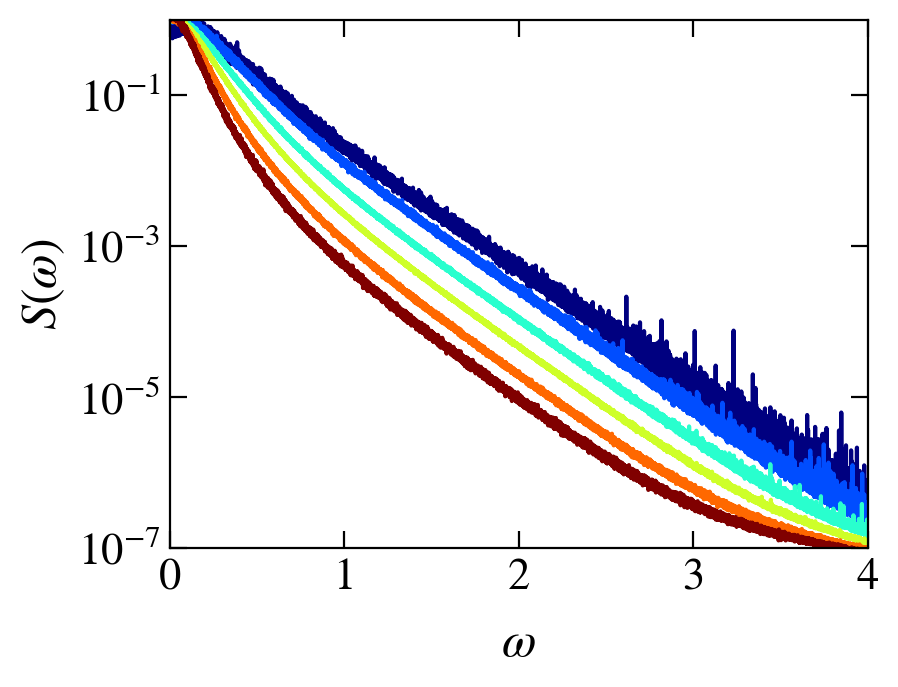

In [1721]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 14, 1)
gammas = np.arange(0.0, 2.9, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])

gx = 1.3
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**L
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            wH = np.array(file.get('wH'))[-2]
    else:
        print(name_out)
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            T = times[1] - times[0]
            N = times.size
            # print(times[1] - times[0], times.size)
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            # power_spectrum  = np.array(file.get('fourier series'))[1:]**2
            power_spectrum  = np.array(file.get('power spectrum'))[1:] / T**2 * N
            # power_spectrum  = np.array(file.get('power spectrum'))[1:]
            # power_spectrum = power_spectrum# * dim**(2-gx)
            # print(omegas.shape, power_spectrum.shape)
            # axis.axvline(x=wH, ls=':', color=col)
            power_spectrum = power_spectrum[omegas > wH]# * dim**(2-gx)
            omegas = omegas[omegas > wH]
            
            long_time = np.mean(power_spectrum[-100:])
            power_spectrum = (power_spectrum - long_time) / (power_spectrum[0] - long_time)
            axis.plot(omegas, (power_spectrum), color=col)
# axis.plot(omegas, _resc_(omegas, 1/omegas**4, power_spectrum), ls='--', color='k')
# x = np.logspace(-0, 2.5, 100)
# axis.plot(x, 0.01/x**1.4, ls='--', color='k')
# axis.plot(x, 0.0025/x**1, ls='--', color='red')
axis.set_xlim(0., 4)
axis.set_ylim(1e-7, 1)

fig_help.set_plot_elements(axis, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='linear', yscale='log')

No handles with labels found to put in legend.


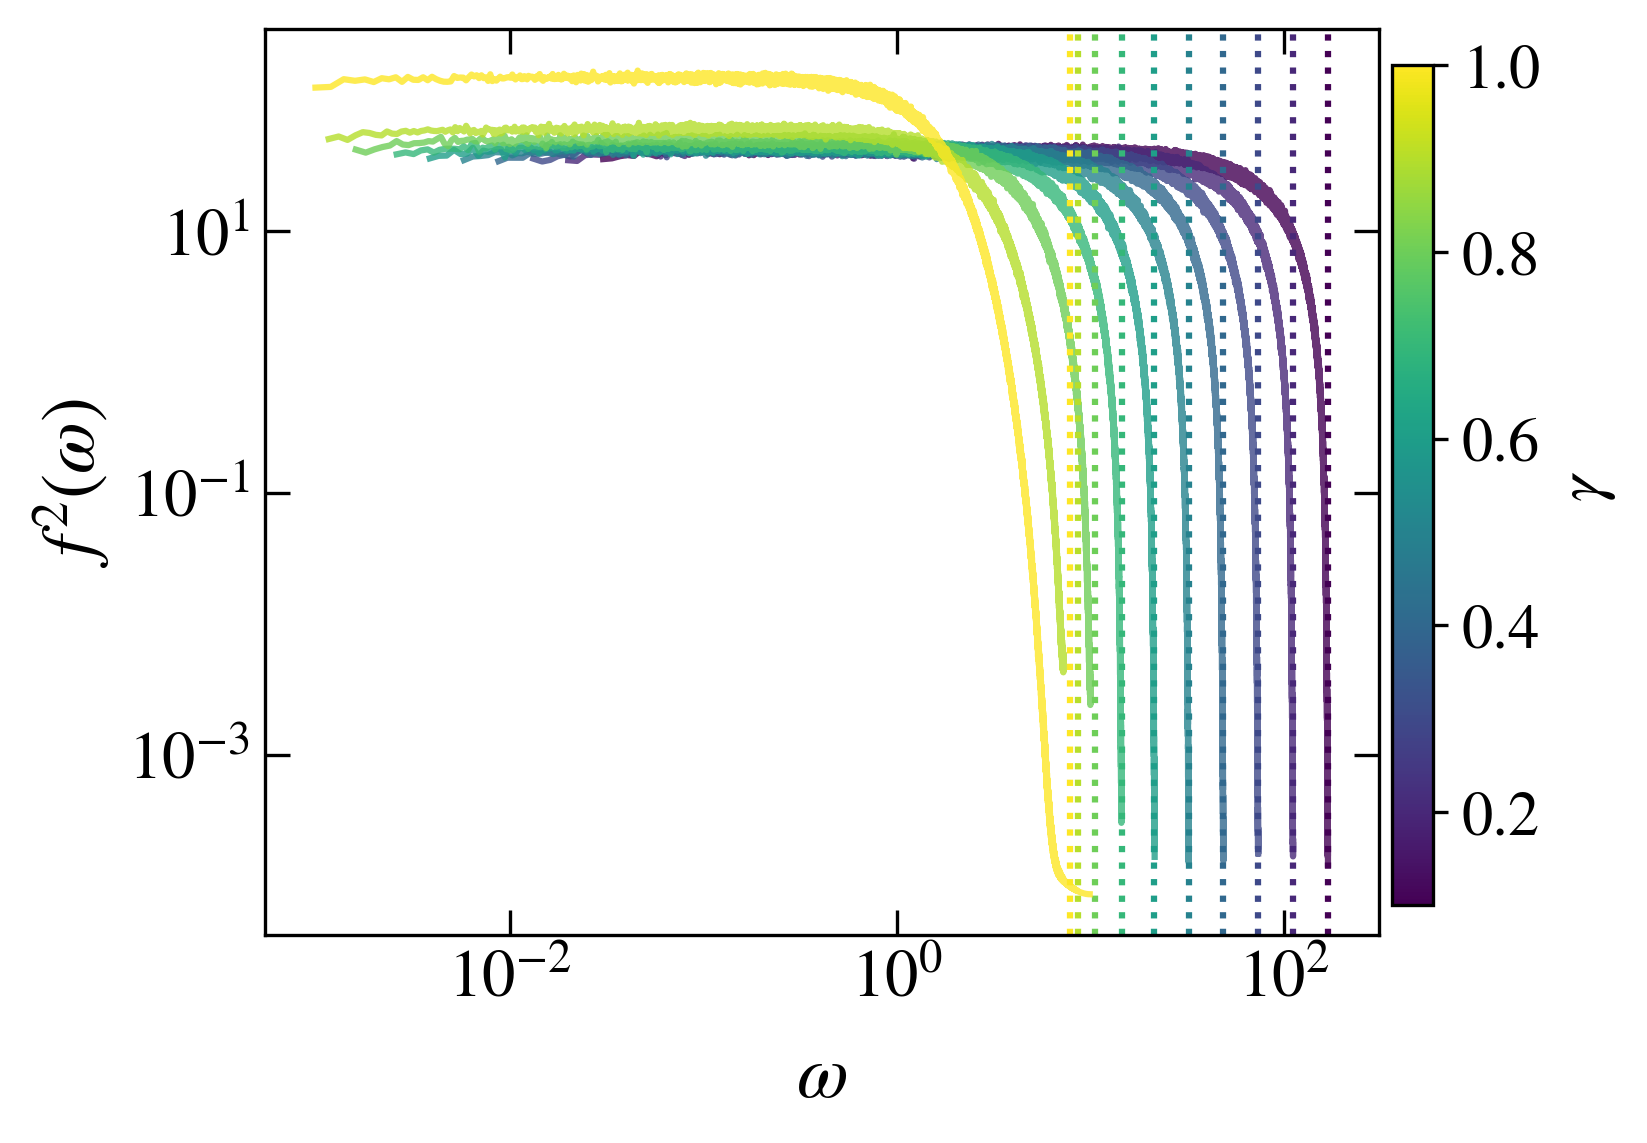

In [1765]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 14, 1)
gammas = np.arange(0.1, 1.01, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 300, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

L=12
gx = 2.
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L

    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            wH = np.array(file.get('wH_typ'))[0]
            sig = np.mean(file.get('stddev'))
            dE = np.mean(file.get('bandwidth'))
    else:
        print(name_out)

    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
                times  = np.array(file.get('times'))
                T = times[1] - times[0]
                N = times.size
                omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
                power_spectrum  = np.array(file.get('fourier series'))[1:]**2 * N**2
                # sig = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
                # print(sig)
                # power_spectrum  = np.array(file.get('power spectrum'))[1:]
                # power_spectrum = power_spectrum# * dim**(2-gx)
                # print(omegas.shape, power_spectrum.shape)
                indices = (omegas > wH)
                omegas = omegas[indices]
                power_spectrum = power_spectrum[indices]
                
                # long_time = np.mean(power_spectrum[-100:])
                # long_time = 0
                # power_spectrum = (power_spectrum - long_time) / (power_spectrum[0] - long_time)
                axis.plot(omegas, power_spectrum, color=col, alpha=0.8)
                axis.axvline(x=dE, color=col, ls=':')
                # sig = np.var(power_spectrum)**0.5
                # if gx <= 1.2:
                #     x = omegas
                #     axis.plot(x, np.exp(-x**2 / (2*sig**2)), ls='--', color=col, lw=2)
# axis.plot(omegas, _resc_(omegas, 1/omegas**2, power_spectrum), ls='--', color='k')
# x = np.logspace(-2, 0.5, 100);
# axis.plot(x, 3e-2/x**2, ls='--', color='k', label=r"$\omega^{-2}$")

# x = np.logspace(-2.25, -0.4, 100); axis.plot(x, 0.001/x**4, ls='--', color='red', label=r"$\omega^{-4}$")
# x = np.logspace(-2.5, -0.6, 100); axis.plot(x, 0.0002/x**4, ls='--', color='red')
# x = np.logspace(-2.75, -0.9, 100); axis.plot(x, 0.00004/x**4, ls='--', color='red')
# x = np.logspace(-3, -1.2, 100); axis.plot(x, 0.000006/x**4, ls='--', color='red')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

# axis.set_xlim(0., 20)
# axis.set_ylim(1e-4, 1.1)

fig.subplots_adjust(wspace = 0.15, hspace=0.12)
fig_help.set_plot_elements(axis, ylabel=r"$f^2(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

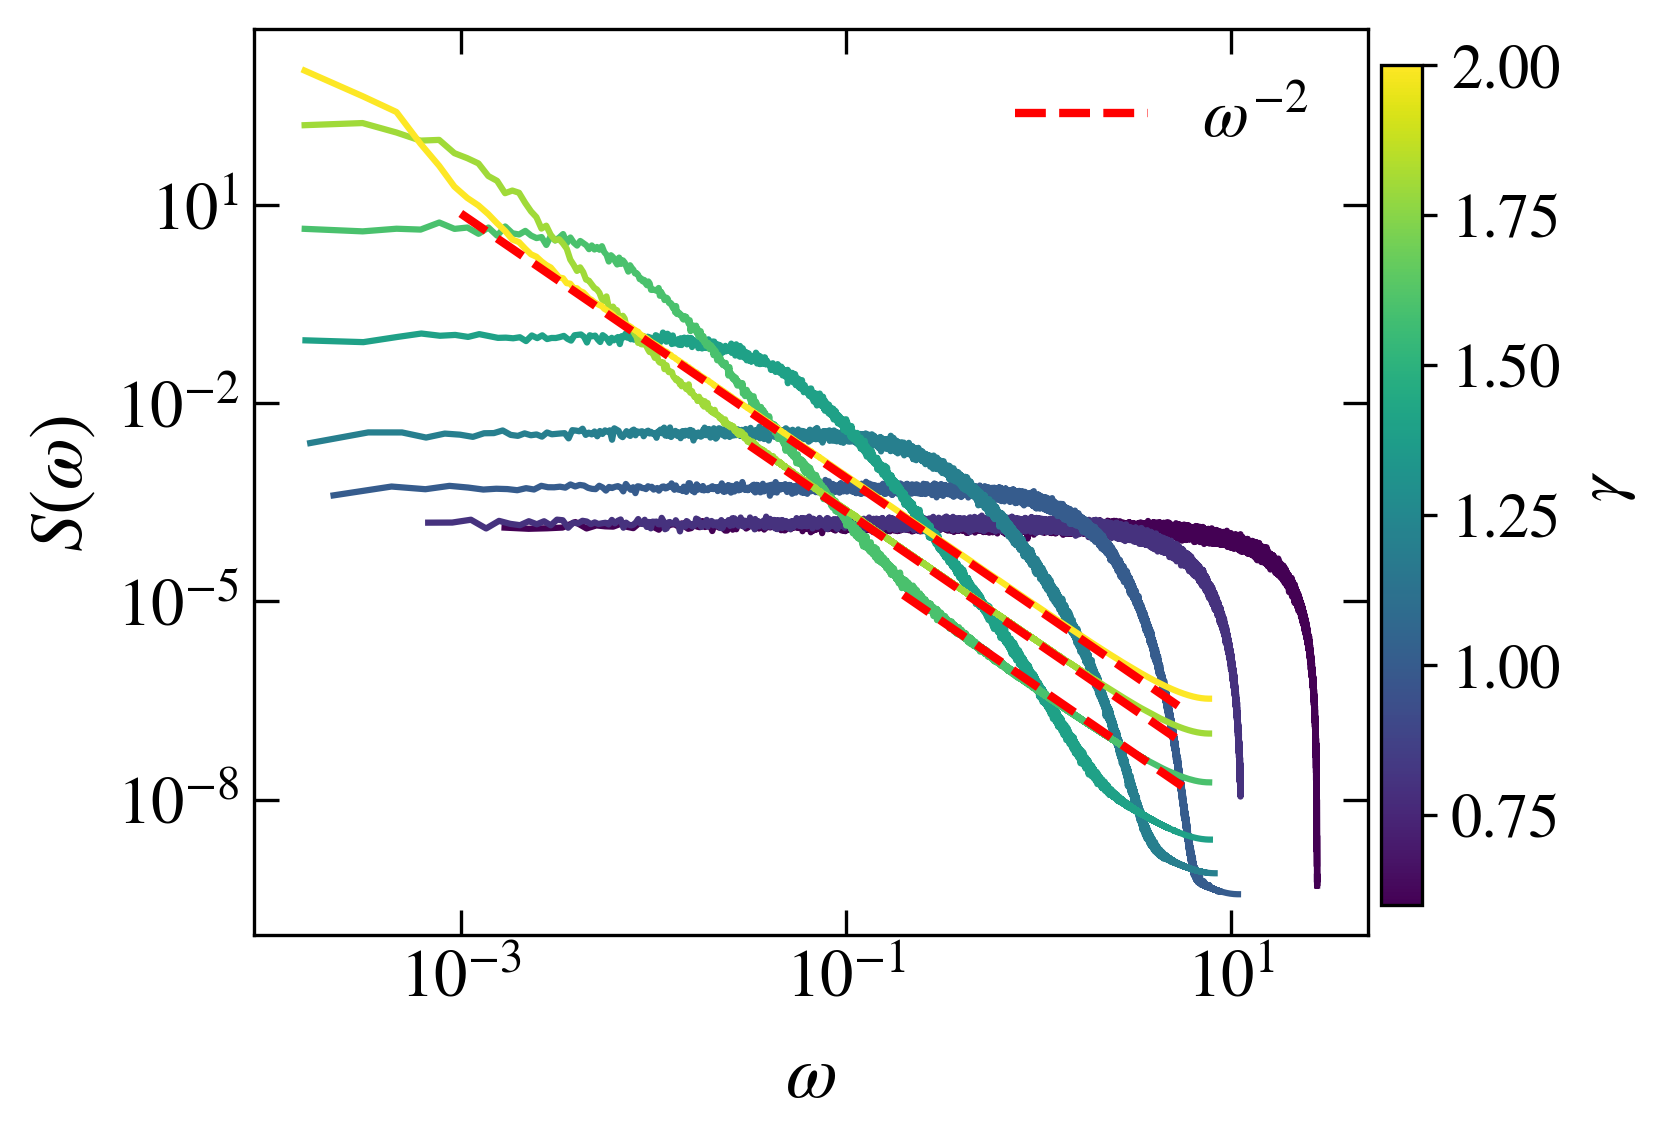

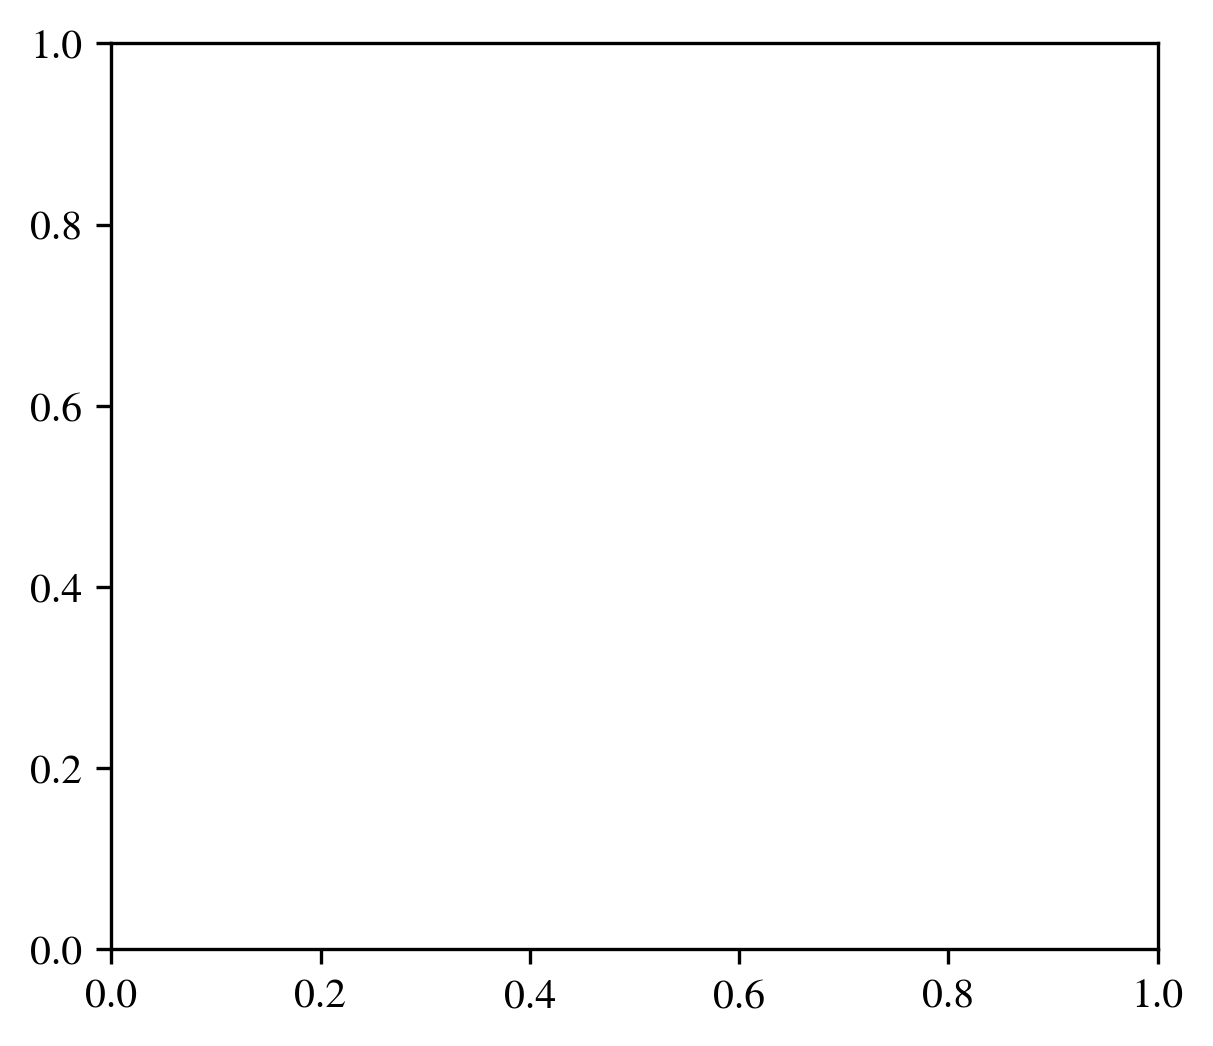

In [1760]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 14, 1)
gammas = np.arange(0.0, 1.51, 0.1)

DIM = 1
# fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4.5,7), dpi = 300, sharex=False, sharey=False)

fig, ax1 = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 300, sharex=False, sharey=False)
fig2, ax2 = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 300, sharex=False, sharey=False)
axis = [ax1, ax2]

gammas = np.arange(0.6, 2.1, 0.2)#[0.6, 1.0, 1.5, 2.0, 2.5]


s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

L=14
gx = 2.

for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            dE = np.mean(file.get('bandwidth'))
            sig = np.mean(file.get('stddev'))
            wH = np.array(file.get('wH_typ'))[0]
    else:
        print(name_out)
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            T = times[1] - times[0]
            N = times.size
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            # power_spectrum  = np.array(file.get('fourier series'))[1:]**2 * N
            power_spectrum  = np.array(file.get('power spectrum'))[1:] / T**2 * N
            # power_spectrum = power_spectrum# * dim**(2-gx)
            # print(omegas.shape, power_spectrum.shape)
            indices = (omegas > wH)
            omegas = omegas[indices]
            power_spectrum = power_spectrum[indices]
            axis[0].plot(omegas, power_spectrum, color=col)
            # axis.axvline(x=bandwidth, color=col, ls=':')
            # if np.round(gx, 1) == 1.4: axis.plot(omegas, _resc_(omegas, 1/omegas**4, power_spectrum), ls='--', color='k')
        #     if gx < 1.5:
        #         x = omegas
        #         axis[0].plot(x, np.exp(-x**2 / (2 * sig**2)) * power_spectrum[0], ls='--', color=col)
                
# axis.set_xlim(0, 0.06)
# axis.set_ylim(1000, 10**4)
# x = np.logspace(-2.1, -0.5, 100);
# axis[0].plot(x, 0.003 / N / x**3.5, ls='--', lw=2, color='k', label=r"$\omega^{-4}$")
# axis.plot(x, 0.002 * np.exp(-20 * x), ls='-.', color='blue', label=r"$e^{-b\omega}$")
x = np.logspace(-3, 0.75, 100);
axis[0].plot(x, 0.75 / N /x**2, ls='--', lw=2, color='red', label=r"$\omega^{-2}$")
x = np.logspace(-1.5, 0.75, 100);
axis[0].plot(x, 0.23 / N /x**2, ls='--', lw=2, color='red')
x = np.logspace(-0.7, 0.75, 100);
axis[0].plot(x, 0.05 / N /x**2, ls='--', lw=2, color='red')

# x = np.logspace(-2.25, -0.4, 100); axis.plot(x, 0.001/x**4, ls='--', color='red', label=r"$\omega^{-4}$")
# x = np.logspace(-2.5, -0.6, 100); axis.plot(x, 0.0002/x**4, ls='--', color='red')
# x = np.logspace(-2.75, -0.9, 100); axis.plot(x, 0.00004/x**4, ls='--', color='red')
# x = np.logspace(-3, -1.2, 100); axis.plot(x, 0.000006/x**4, ls='--', color='red')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.15, hspace=0.12)
fig_help.set_plot_elements(axis[0], ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

alfas = np.arange(0.7, 1, 0.05)#[0.6, 1.0, 1.5, 2.0, 2.5]


s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(alfas),
        vmax=max(alfas)))
s_m.set_array([])

# Fig.1 Thouless energy vs heisenberg, 2 alfas, 2 L, in inset vs L
# Fig.2 dynamics c(t) vs Gamma * t / J, J - bandwidth
# Fig.3 temporal fluctuations like in fading paper, compare fractal dimension (senbd paper of iupper bound on temp fluct)
# Fig.4 distribution, gaussian and non-gaussian fluct
# Fig.5 power spectrum for 4-5 gammas, GOE, fading and critical
# Fig.6 eta of fading
# Fig. A1 f-functions, show fading

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig5.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.31656187515181955 0.9972442503882425
0.3736852922156686 1.043953281487425
0.41048552983556874 1.0657089626542569
0.4302945294548408 1.075474984591789
0.4398608984265593 1.079785820833116
0.4442290099323145 1.0816744761471073
0.4461714229473728 1.082499248776574
0.4470249034857261 1.0828588232600511
0.44739793552435003 1.0830154372704148
0.44756059911014745 1.0830836127687344
0.44763145798788173 1.0831132560025623


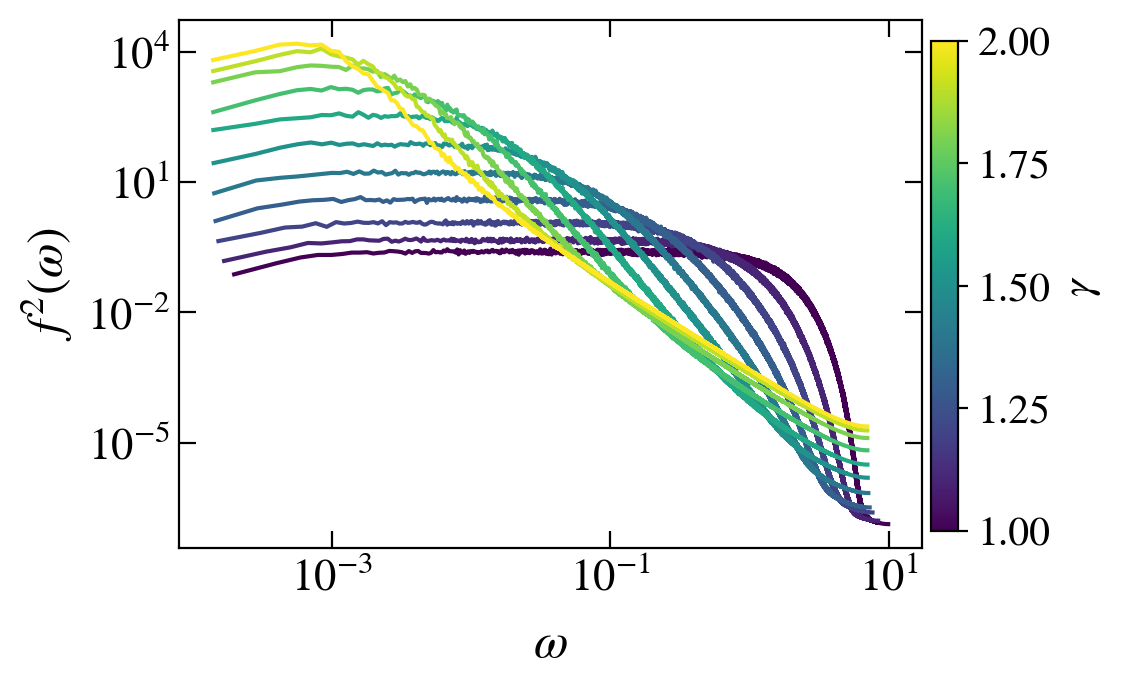

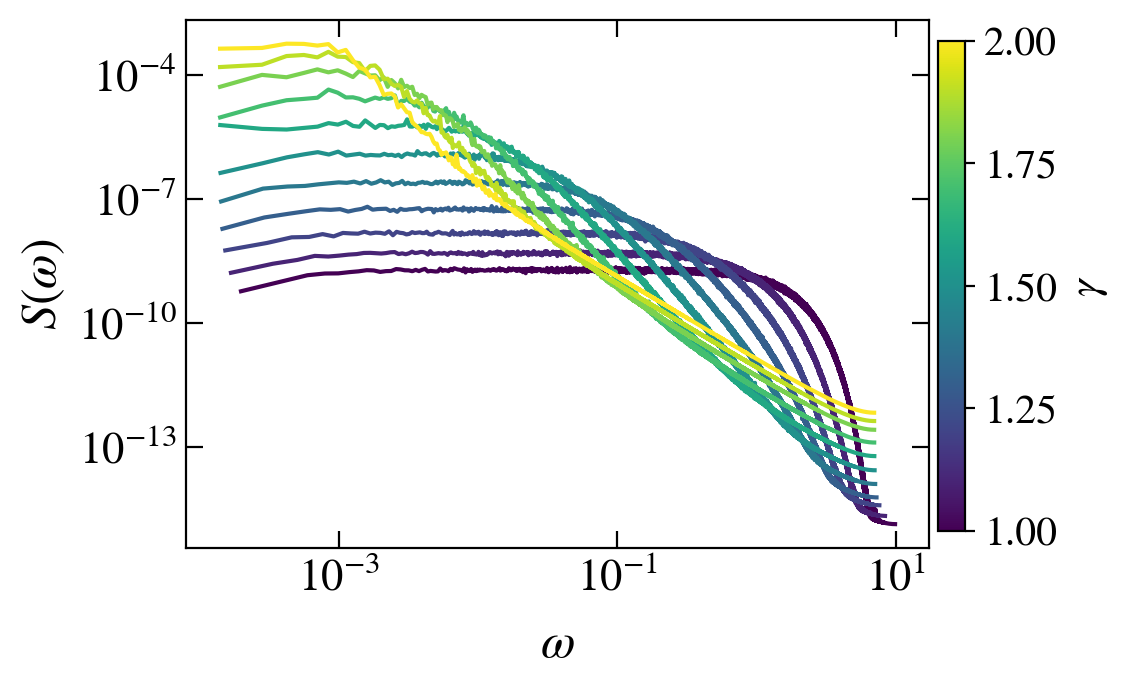

In [1269]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.1, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)
fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 2.8
for gx in gammas:
    col = s_m.to_rgba(gx)
    name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            bandwidth = np.mean(file.get('bandwidth'))
    else:
        print(name_out)
    dim = 2**L
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))
            print(times[-1] - times[-2], 1.25 * 2 * np.pi / bandwidth)
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            fourier  = (np.array(file.get('fourier series'))[1:] * dim)**2
            axis.plot(omegas, fourier, color=col)
            # axis.axvline(x=bandwidth, color=col, ls=':')
            
            power  = np.array(file.get('power spectrum'))[1:]
            axis2.plot(omegas, power, color=col)
    else:
        print(name_out)       
# axis.plot(omegas, _resc_(omegas, 1/omegas**2, fourier), ls='--', color='k')
# axis.plot(omegas, _resc_(omegas, 1/omegas**4, fourier)/100, ls='--', color='red')

# x = np.logspace(-1, 1, 100)
# # axis2.plot(x, 1e-10/x**4, ls='--', color='red')
# axis2.plot(x, 0.003/x**1, ls='--', color='red')

for fig in [fig, fig2]:
    fig.subplots_adjust(right=0.95)
    cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
    cbar.set_label(r"$\gamma$", fontsize=16)
    cbar.ax.tick_params(labelsize=15)

    fig.subplots_adjust(wspace = 0.15, hspace=0.12)
    
fig_help.set_plot_elements(axis, ylabel=r"$f^2(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"$S(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

No handles with labels found to put in legend.


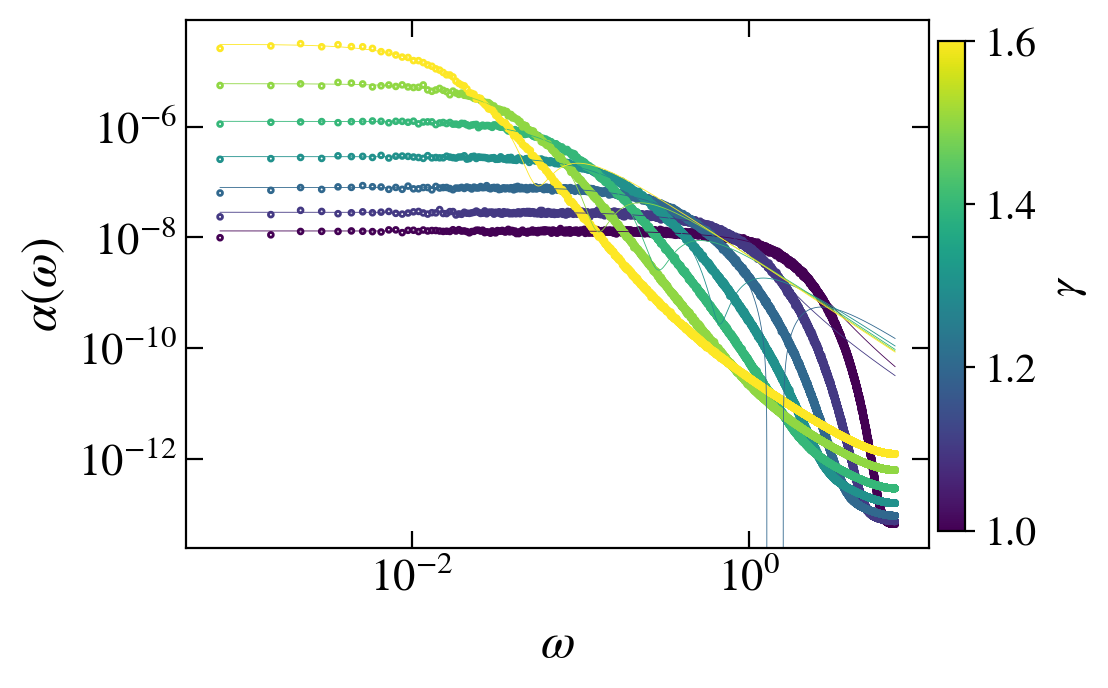

In [849]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 1.6, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

def one_over_f(f, alpha, scale):
    return scale / (f ** alpha)

def some_shit(f, A, g1, B, g2):
    return A / (1 + (f / g1)**2) + B / (1 + (f / g2)**4)

window_size = 10
gx = 2.8
for gx in gammas:
    col = s_m.to_rgba(gx)
    dim = 2**L
    name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            omegas  = 2 * np.pi * np.array(file.get('frequency'))[1:]
            fourier  = np.array(file.get('fourier series'))[1:]
            power  = np.array(file.get('power spectrum'))[1:]
            N = omegas.size
            
            axis.scatter(omegas, power, color=col, s=3, facecolor='None')
            # omegas = omegas[window_size//2:-window_size//2]
            # power = tools.remove_fluctuations(power, window_size)[window_size//2:-window_size//2]
            pars, pconv = fit(some_shit,
                                    xdata = omegas[:-power.size//2],
                                    ydata = power[:-power.size//2],
                                    maxfev=10000)
            axis.plot(omegas, some_shit(omegas, *pars), color=col, lw=0.3)
            # axis.scatter(omegas[1:-1], -diff_central(np.log(omegas), np.log(power)), color=col, s=3)
            # xt = np.zeros((N // window_size))
            # alfat = np.zeros((N // window_size))
            # for ii in range(N//window_size):
            #     idx_min = window_size * ii
            #     idx_max = window_size * (ii+1)
            #     try:
            #         pars, pconv = fit(one_over_f,
            #                         xdata = omegas[idx_min : idx_max],
            #                         ydata = power[idx_min : idx_max],
            #                         maxfev=10000)
            #         xt[ii] = omegas[window_size * ii + window_size//2]
            #         alfat[ii] = np.abs(pars[0])
            #     except RuntimeError:
            #         fnsodaz=1
            
            # # print(alfat)
            # axis.scatter(xt, alfat, color=col, s=3)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.15, hspace=0.12)   
# x = np.logspace(-4, -0.5, 100)
# axis.plot(x, 0.0001/x**1.25, ls='--', color='k')
# axis.plot(x, 0.0003/x**1, ls='--', color='red')
# axis.set_ylim(0, 5)
fig_help.set_plot_elements(axis, ylabel=r"$\alpha(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

45538.77490990786 51395.8345554899 |||| 7.935518960962374 7.731983399509674


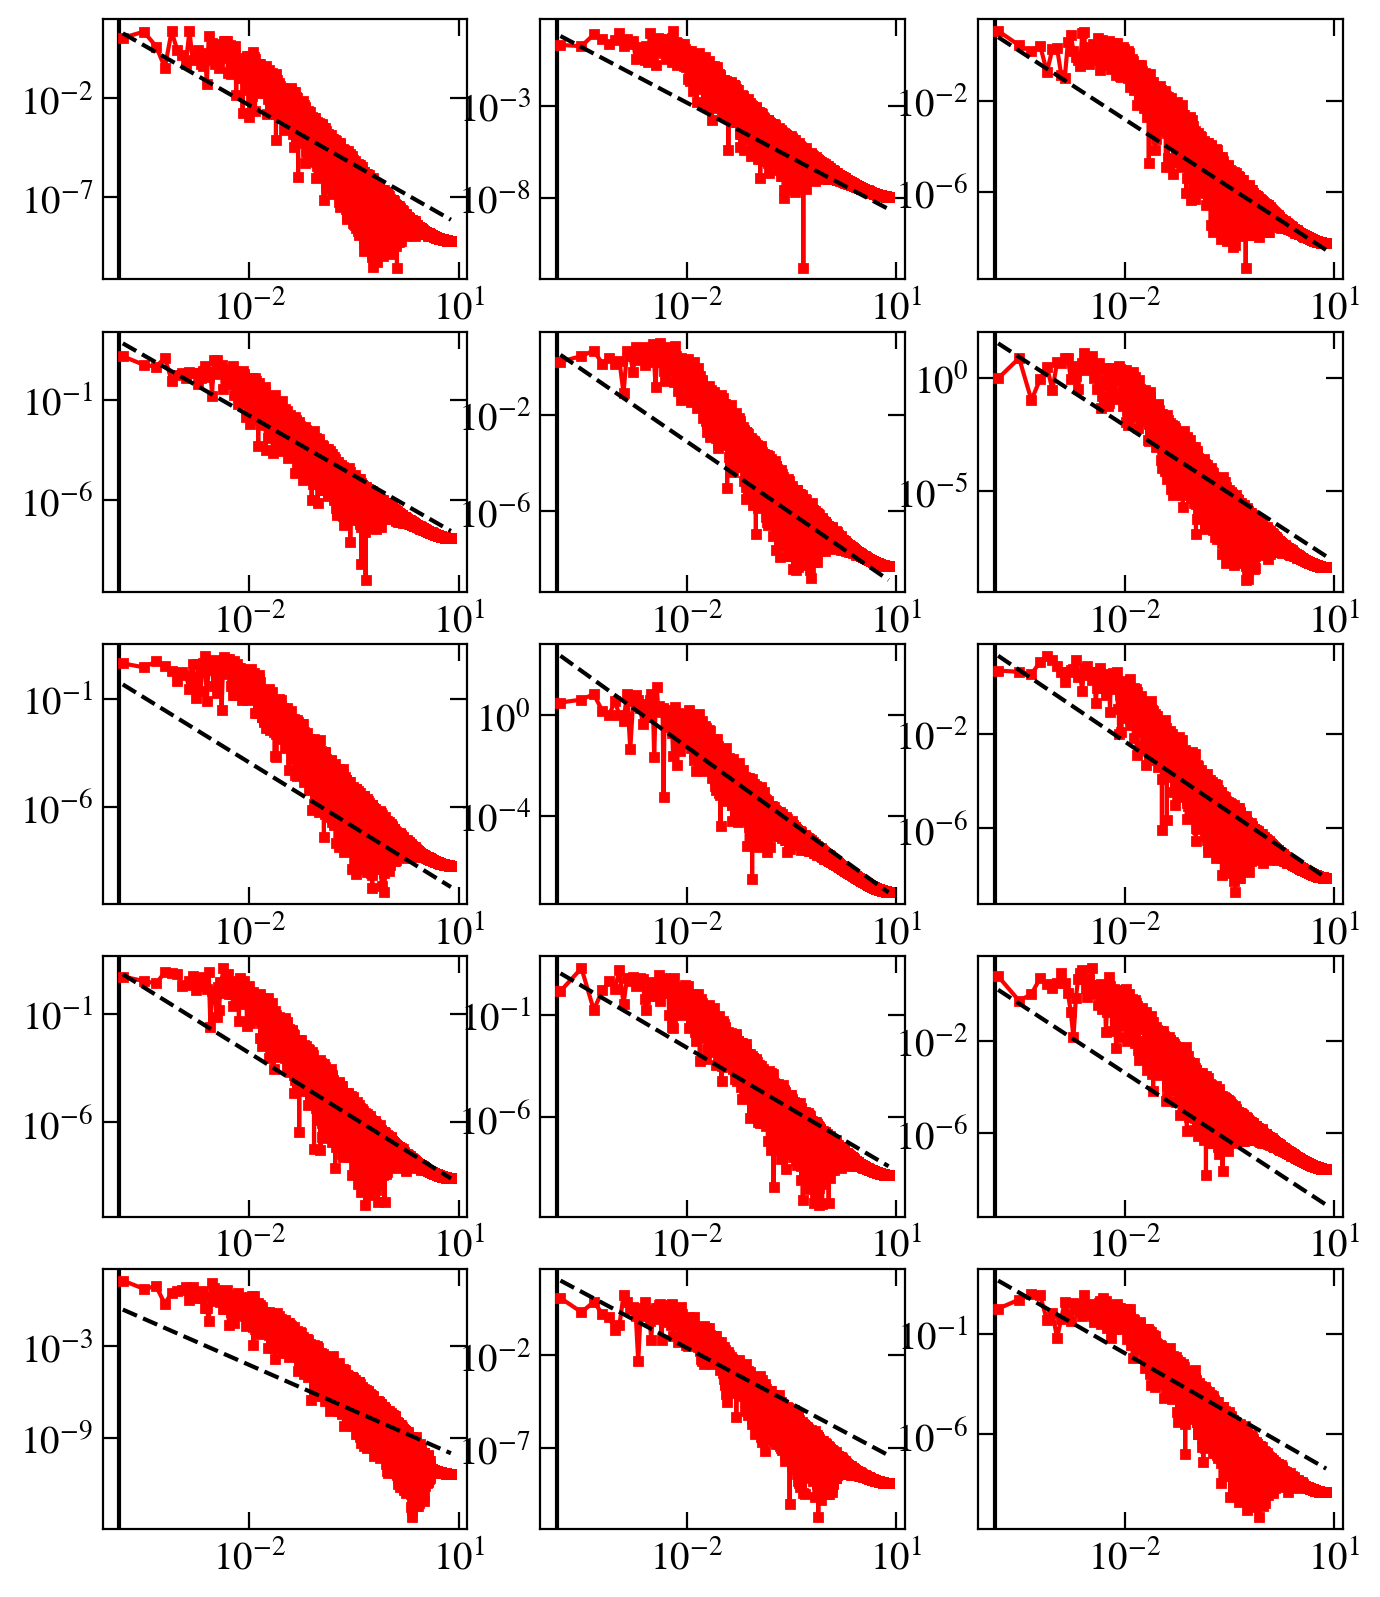

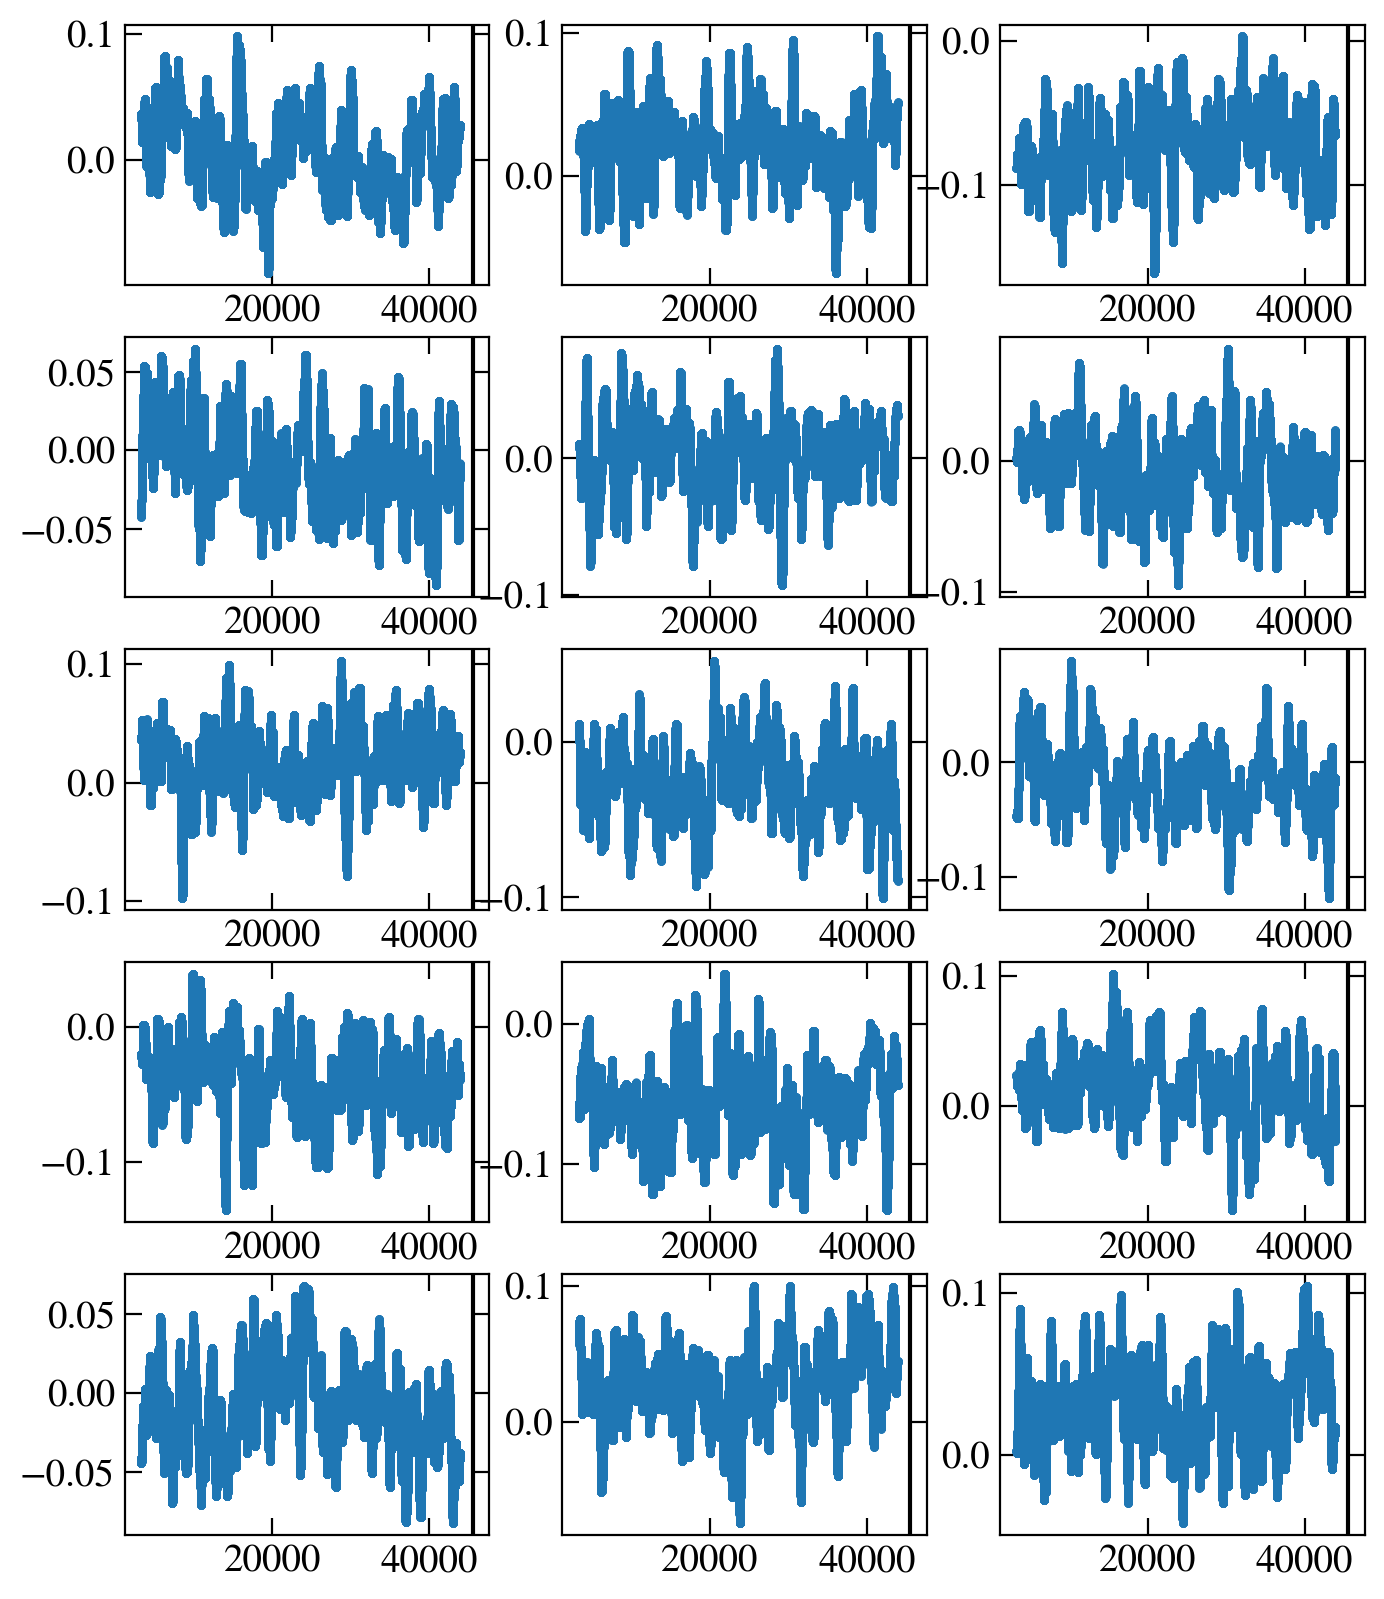

In [1797]:
colors_ls_cyc = itertools.cycle(colors_ls)
from scipy import signal


L = 13
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(1.0, 2.9, 0.1)
from scipy.signal.windows import blackman
w = blackman(N)

DIM = 1

nrows = 5
fig, axis = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis = axis.flatten()

fig_raw, axis_raw = plt.subplots( nrows=nrows, ncols=3, figsize=(8,2*nrows), dpi = 200)
axis_raw = axis_raw.flatten()

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])

gx = 1.6
L = 14
dim = 2**L
name_out = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        dE = np.mean( np.array(file.get('bandwidth')) )
        wH = np.array(file.get('wH_typ'))[-2]
        tH = 2 * np.pi / wH
        
        e_max = e_max = ( np.sqrt(2 * np.log(dim)) - np.log(np.log(dim) * 4 * np.pi) / np.sqrt(2*np.log(dim)) / 2 ) * (np.sqrt(1 + dim**(1-gx)))
        dE_analytical = 2 * e_max if gx >= 1 else (4 * np.sqrt(1 + dim**(1-gx)))
        print(tH, 2 * np.pi * dim / (np.sqrt(1 + dim**(1-gx))) / 2, "||||", dE, dE_analytical)
else:
    print(name_out)
for ii, ax in enumerate(axis_raw):
    ax.axvline(x=tH, ls='-', color='k')
    axis[ii].axvline(x=wH, ls='-', color='k')
    
    
name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        times  = np.array(file.get('times'))
        T = times[1] - times[0]
        N = times.size
        Q_raw  = np.array(file.get('quench data'))
        for ii, ax in enumerate(axis_raw):
            ax.plot(times, Q_raw[ii], lw=1, marker='o', markersize=2)
            
            xf = 2 * np.pi * fftfreq(N, T)[1:N//2]
            yf = np.abs( 2 / np.sqrt(N) * np.abs(fft(Q_raw[ii])[1:N//2]) )**2
            # xf, yf = signal.welch(Q_raw[ii], 1/T, scaling='spectrum', average='median')

            # print(T, times[-1] - times[0], np.min(xf))
            axis[ii].plot(xf, yf, color='red', marker='s', markersize=3)
            
            axis[ii].plot(xf, _resc_(xf, 1/xf**2, yf), ls='--', color='k')
            # axis[ii].plot(xf, _resc_(1/xf**1), ls=':', color='blue')
for ii, ax in enumerate(axis_raw):
    fig_help.set_plot_elements(ax, ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[ii], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='log', yscale='log')
# fig_help.set_plot_elements(axis, ylabel=r"$f(\omega)$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

## DISTRIBUTION OF LONG-TIME VALUES

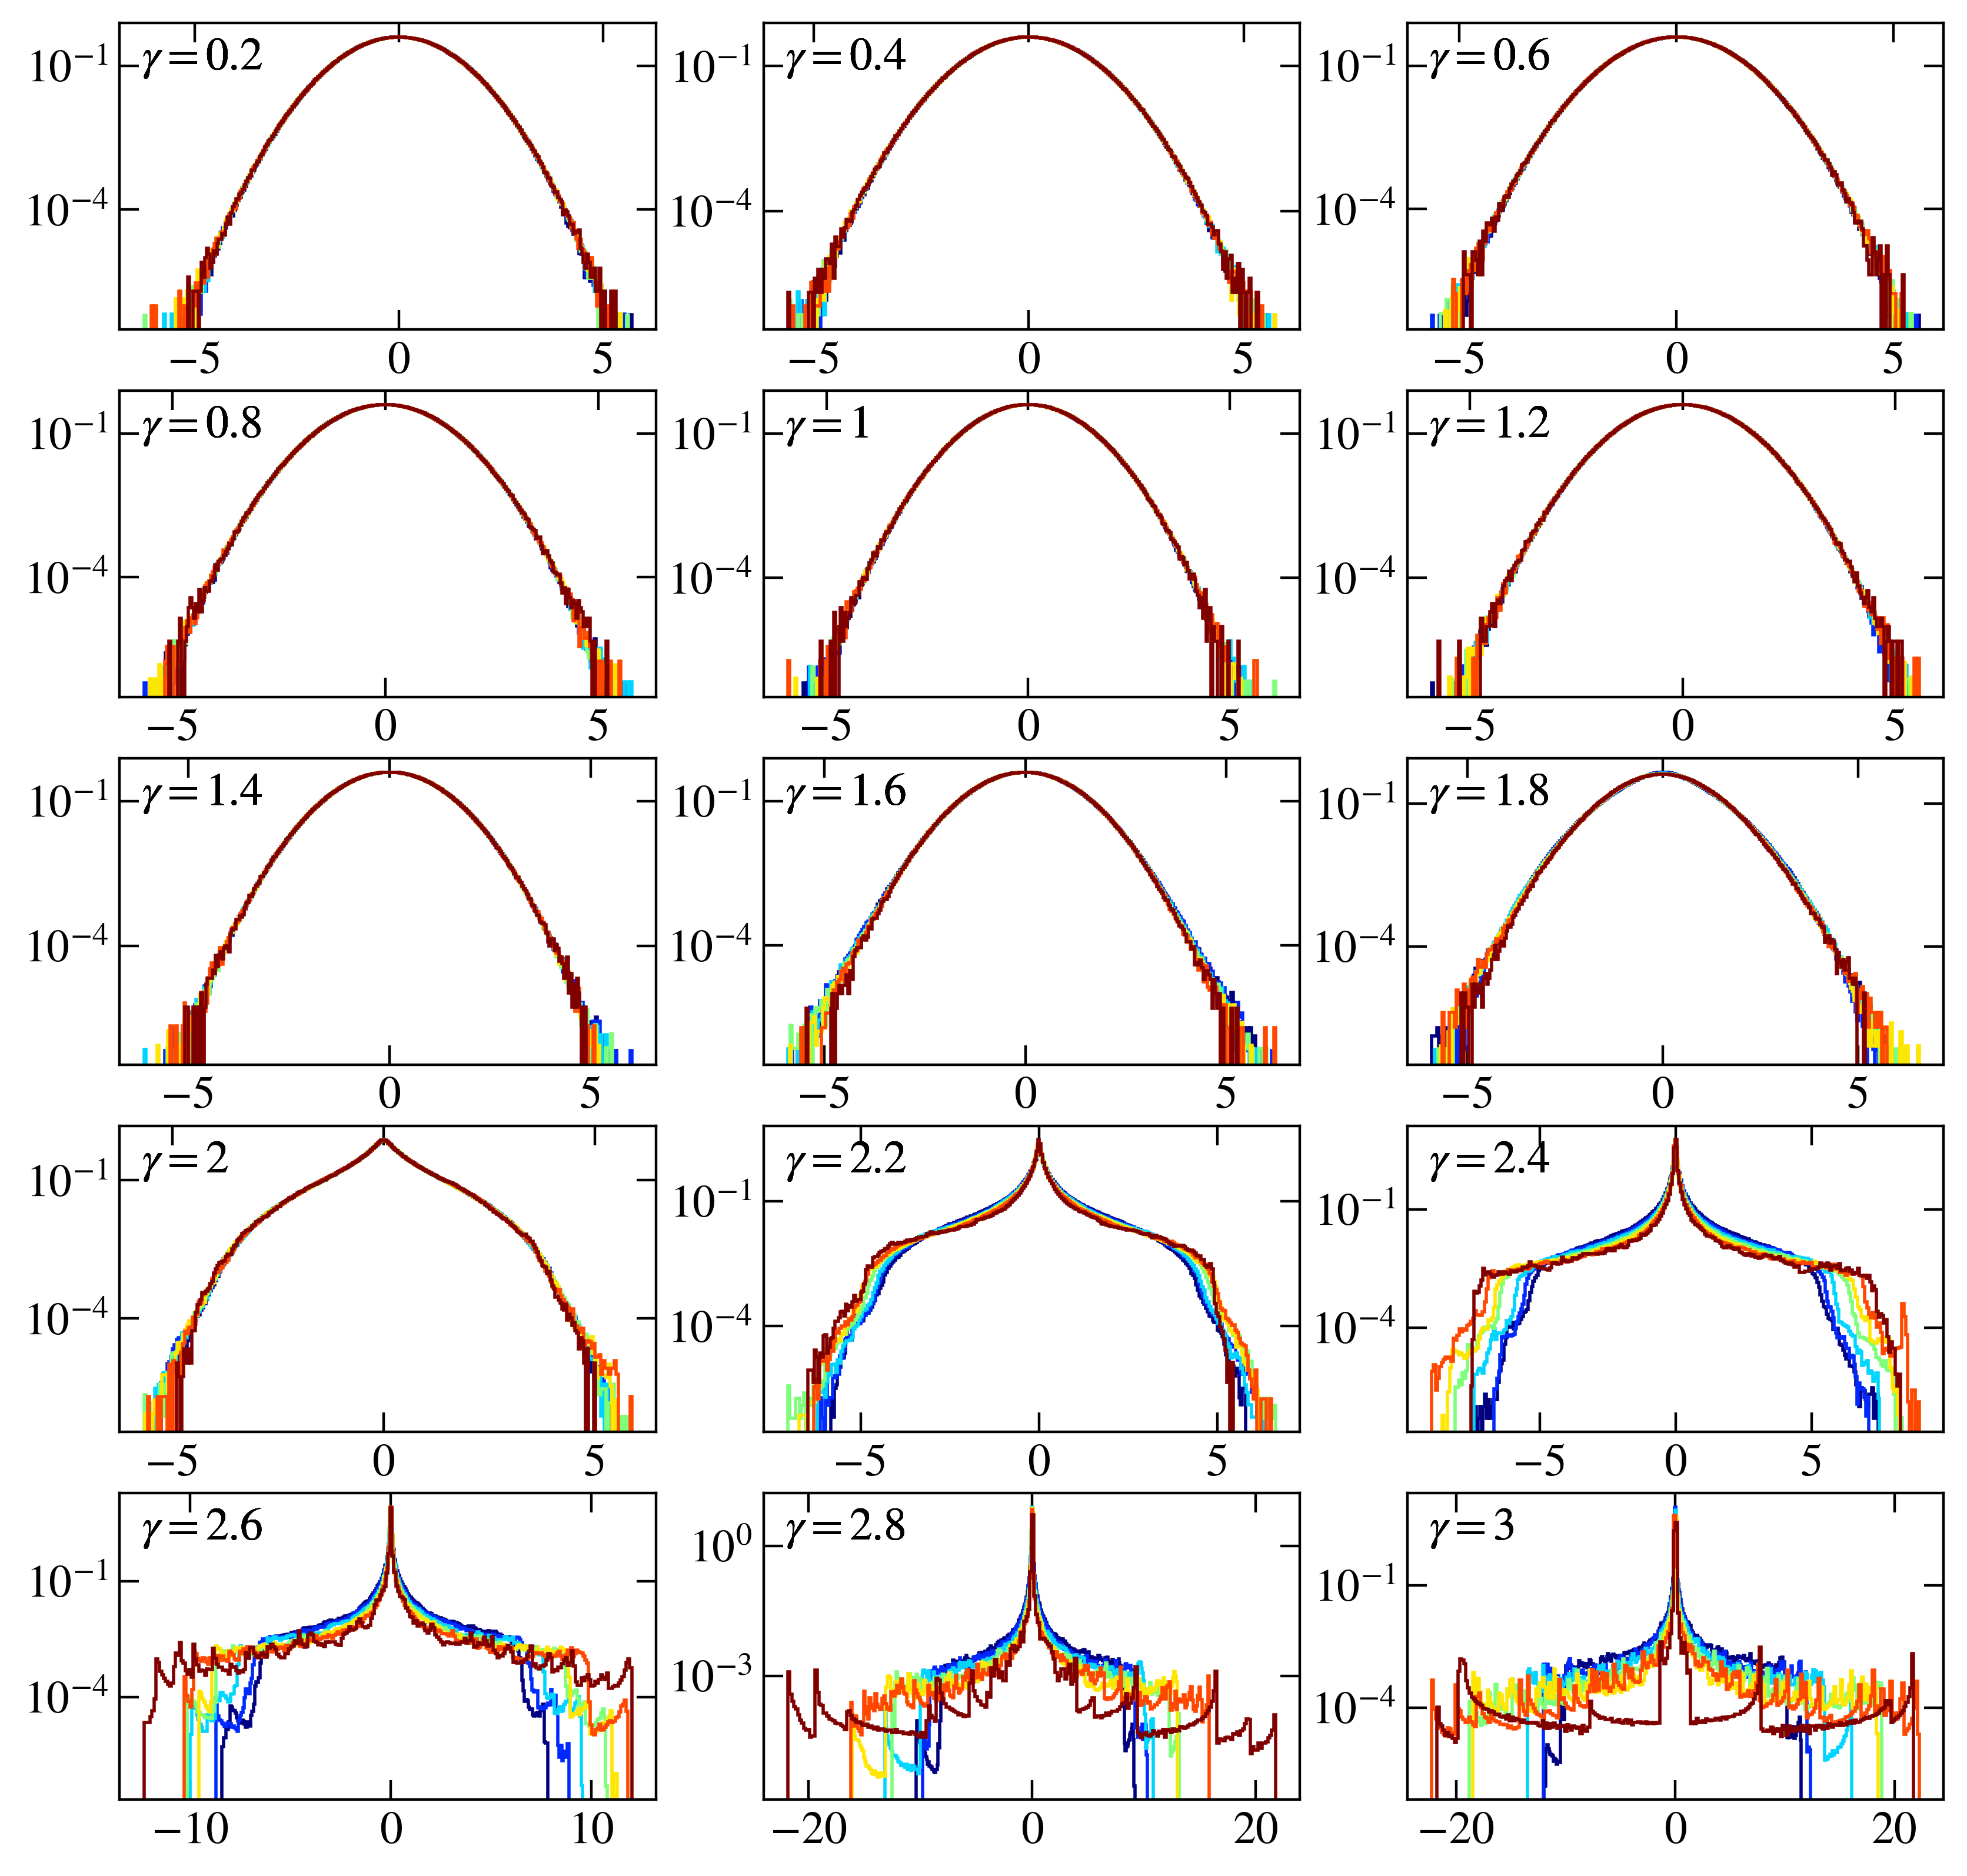

In [1647]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.2, 3.1, 0.2)
fig, axis = plt.subplots( nrows=5, ncols=3, figsize=(10,10), dpi = 400, sharex=False, sharey=False)
axis = axis.flatten()
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for iig, gx in enumerate(gammas):
    d2 = 1 if gx <= 1 else 2 - gx
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = 2**L
        # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        # if exists(name_out):
        #     with h5py.File(name_out, "r") as file:
        #         sec_mom = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
        #         bins  = np.array(file.get('fluct_bins_log')) - np.log(sec_mom)
        #         dist  = np.array(file.get('fluct_hist_log'))# * sec_mom
        #         axis[iig].stairs(dist, bins, color=col)
        # else:
        #     print(name_out)
        
        name_out = base_dir(model=modello, d=DIM) + 'Quench/' +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                sec_mom = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2)
                bins = np.array(file.get('LTVALS/L=%d/bins'%L))# / sec_mom
                hist = np.array(file.get('LTVALS/L=%d/hist'%L))# * sec_mom
                axis[iig].stairs(hist, bins, color=col)
                
        axis[iig].annotate(r" $\gamma=%g$"%gx, fontsize=14, xy=(0.02, 0.85), xycoords='axes fraction')
    # axis[iig].plot(bins, np.exp(-bins**2) / np.sqrt(np.pi), color='k', ls='--')
    fig_help.set_plot_elements(axis[iig], ylabel=r"", xlabel=r"", font_size=14, set_legend=0, xscale='linear', yscale='log')
    # axis[iig].set_xlim(-4, None)

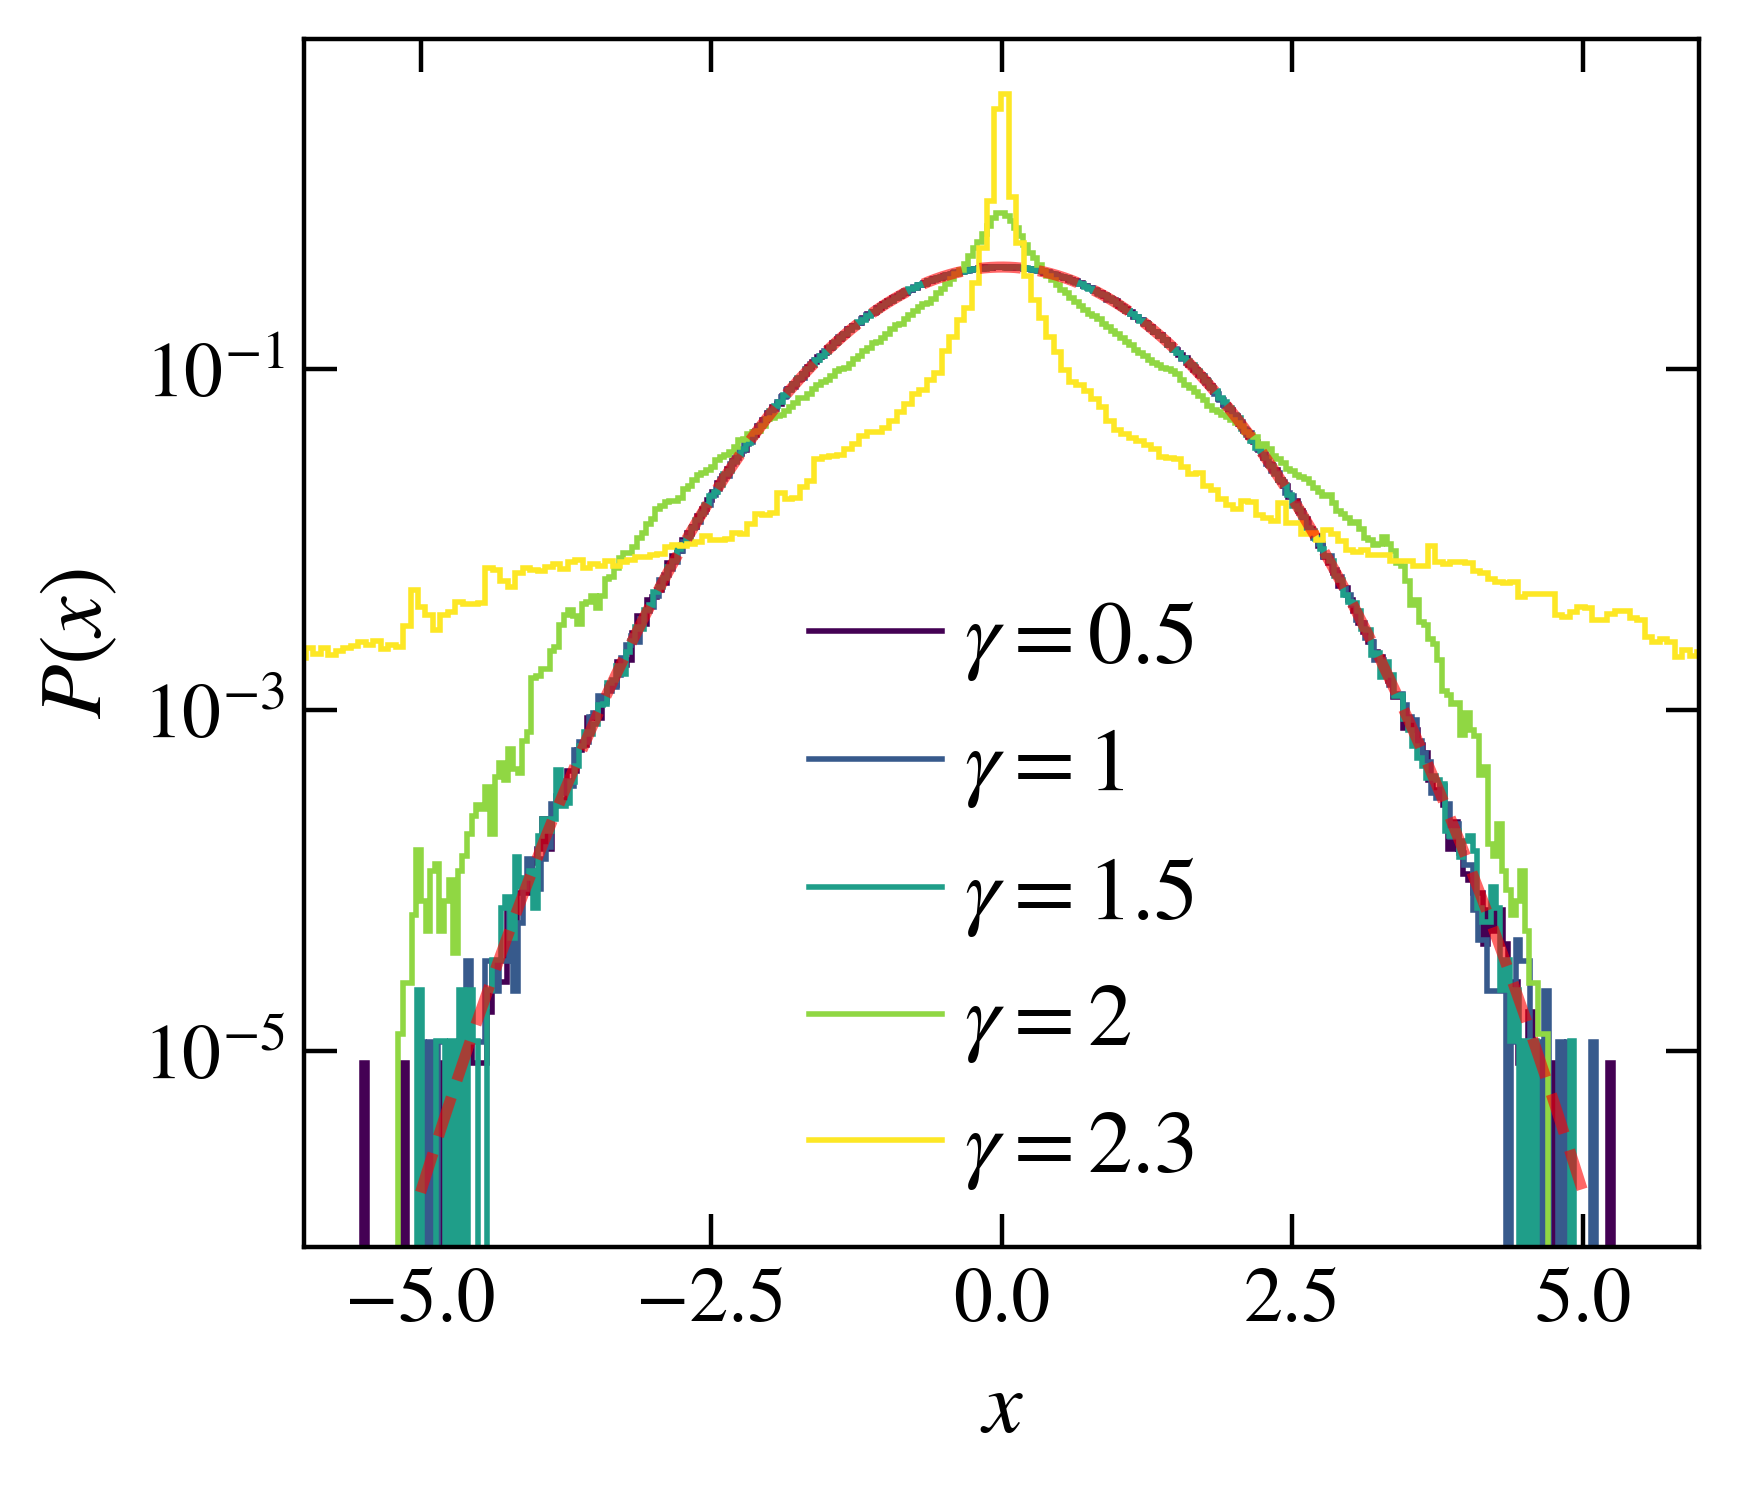

In [1649]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 15
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/'

sizes = np.arange(8, 17, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.4, 2.1, 0.2)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,4), dpi = 400, sharex=False, sharey=False)

gammas = [0.5, 1.0, 1.5, 2.0, 2.3]
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
s_m.set_array([])


for iig, gx in enumerate(gammas):
    d2 = 1 if gx <= 1 else 2 - gx
    col = s_m.to_rgba(gx)
    dim = 2**L
    # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    # if exists(name_out):
    #     with h5py.File(name_out, "r") as file:
    #         sec_mom = np.sqrt(np.array(file.get('second_moment')) - np.array(file.get('first_moment'))**2)
    #         bins  = np.array(file.get('fluct_bins')) / sec_mom#np.sqrt(2 * dim**d2)
    #         hist  = np.array(file.get('fluct_hist')) * sec_mom#np.sqrt(2 * dim**d2)
    #         # axis.stairs(hist, bins, color=col, label=r"$\gamma=%g$"%gx)
    # else:
    #     print(name_out)
    
    name_out = base_dir(model=modello, d=DIM) + 'Quench/' +  "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            try:
                sec_mom = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2)
                bins = np.array(file.get('LTVALS/L=%d/bins'%L))# / sec_mom
                hist = np.array(file.get('LTVALS/L=%d/hist'%L))# * sec_mom
                axis.stairs(hist, bins, color=col, label=r"$\gamma=%g$"%gx)
            except TypeError:
                print(name_out)

x = np.linspace(-5, 5, 1000)
axis.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), ls='--', color='red', lw=2, alpha=0.6)

axis.set_xlim(-6, 6)

fig_help.set_plot_elements(axis, ylabel=r"$P(x)$", xlabel=r"$x$", font_size=14, set_legend=0, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=16, loc='lower center')

fig.savefig("PLOTS_FADING/ANOMALOUS/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

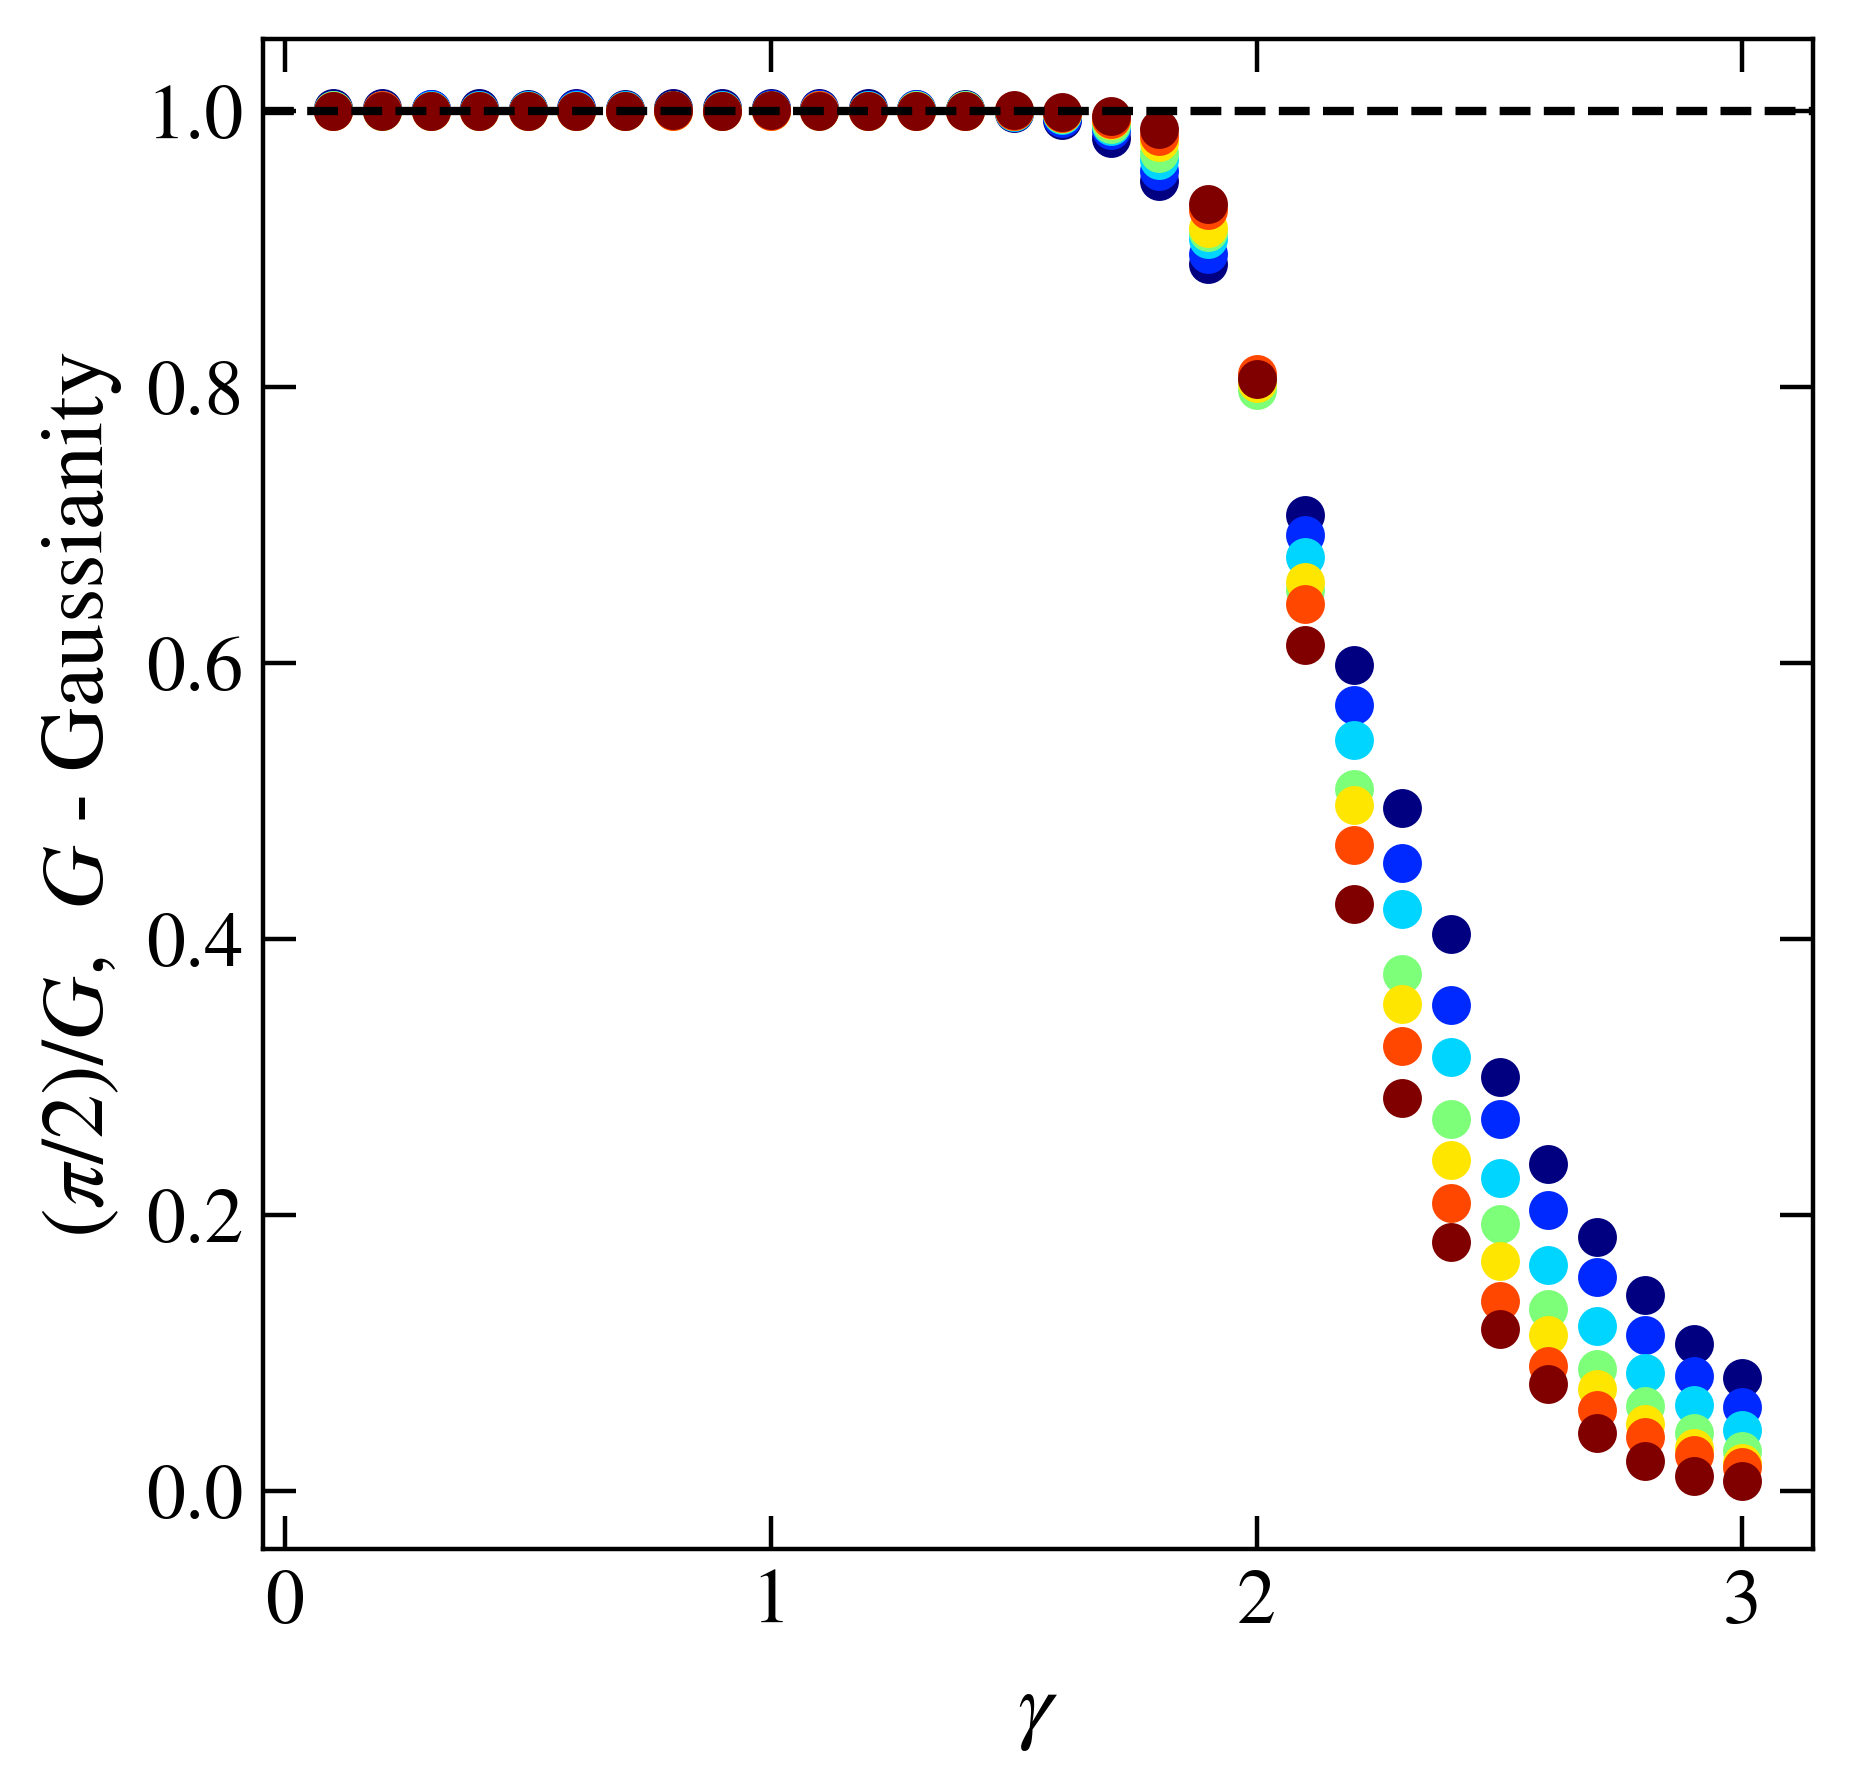

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 15, 1)

DIM = 1
gammas = np.arange(0.1, 3.01, 0.1)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 400, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for L in sizes:
    col = s_m.to_rgba(L)
    gauss = np.zeros(gammas.shape);gauss.fill(np.nan)
    for iig, gx in enumerate(gammas):
        dim = 2**L
        # name_out = prefix + info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                try:
                    gauss[iig] = np.array(file.get('LTVALS/L=%d/gauss'%L))
                except TypeError:
                    aadsada=1
        else:
            print(name_out)
    axis.scatter(gammas, np.pi/2/gauss, color=col)
    # axis.scatter(gammas, np.abs( gauss - np.pi/2 ), color=col)
axis.axhline(y=1, ls='--', color='k')
fig_help.set_plot_elements(axis, ylabel=r"$(\pi/2)/G$,  $G$ - Gaussianity", xlabel=r"$\gamma$", font_size=14, set_legend=0, xscale='linear', yscale='linear')

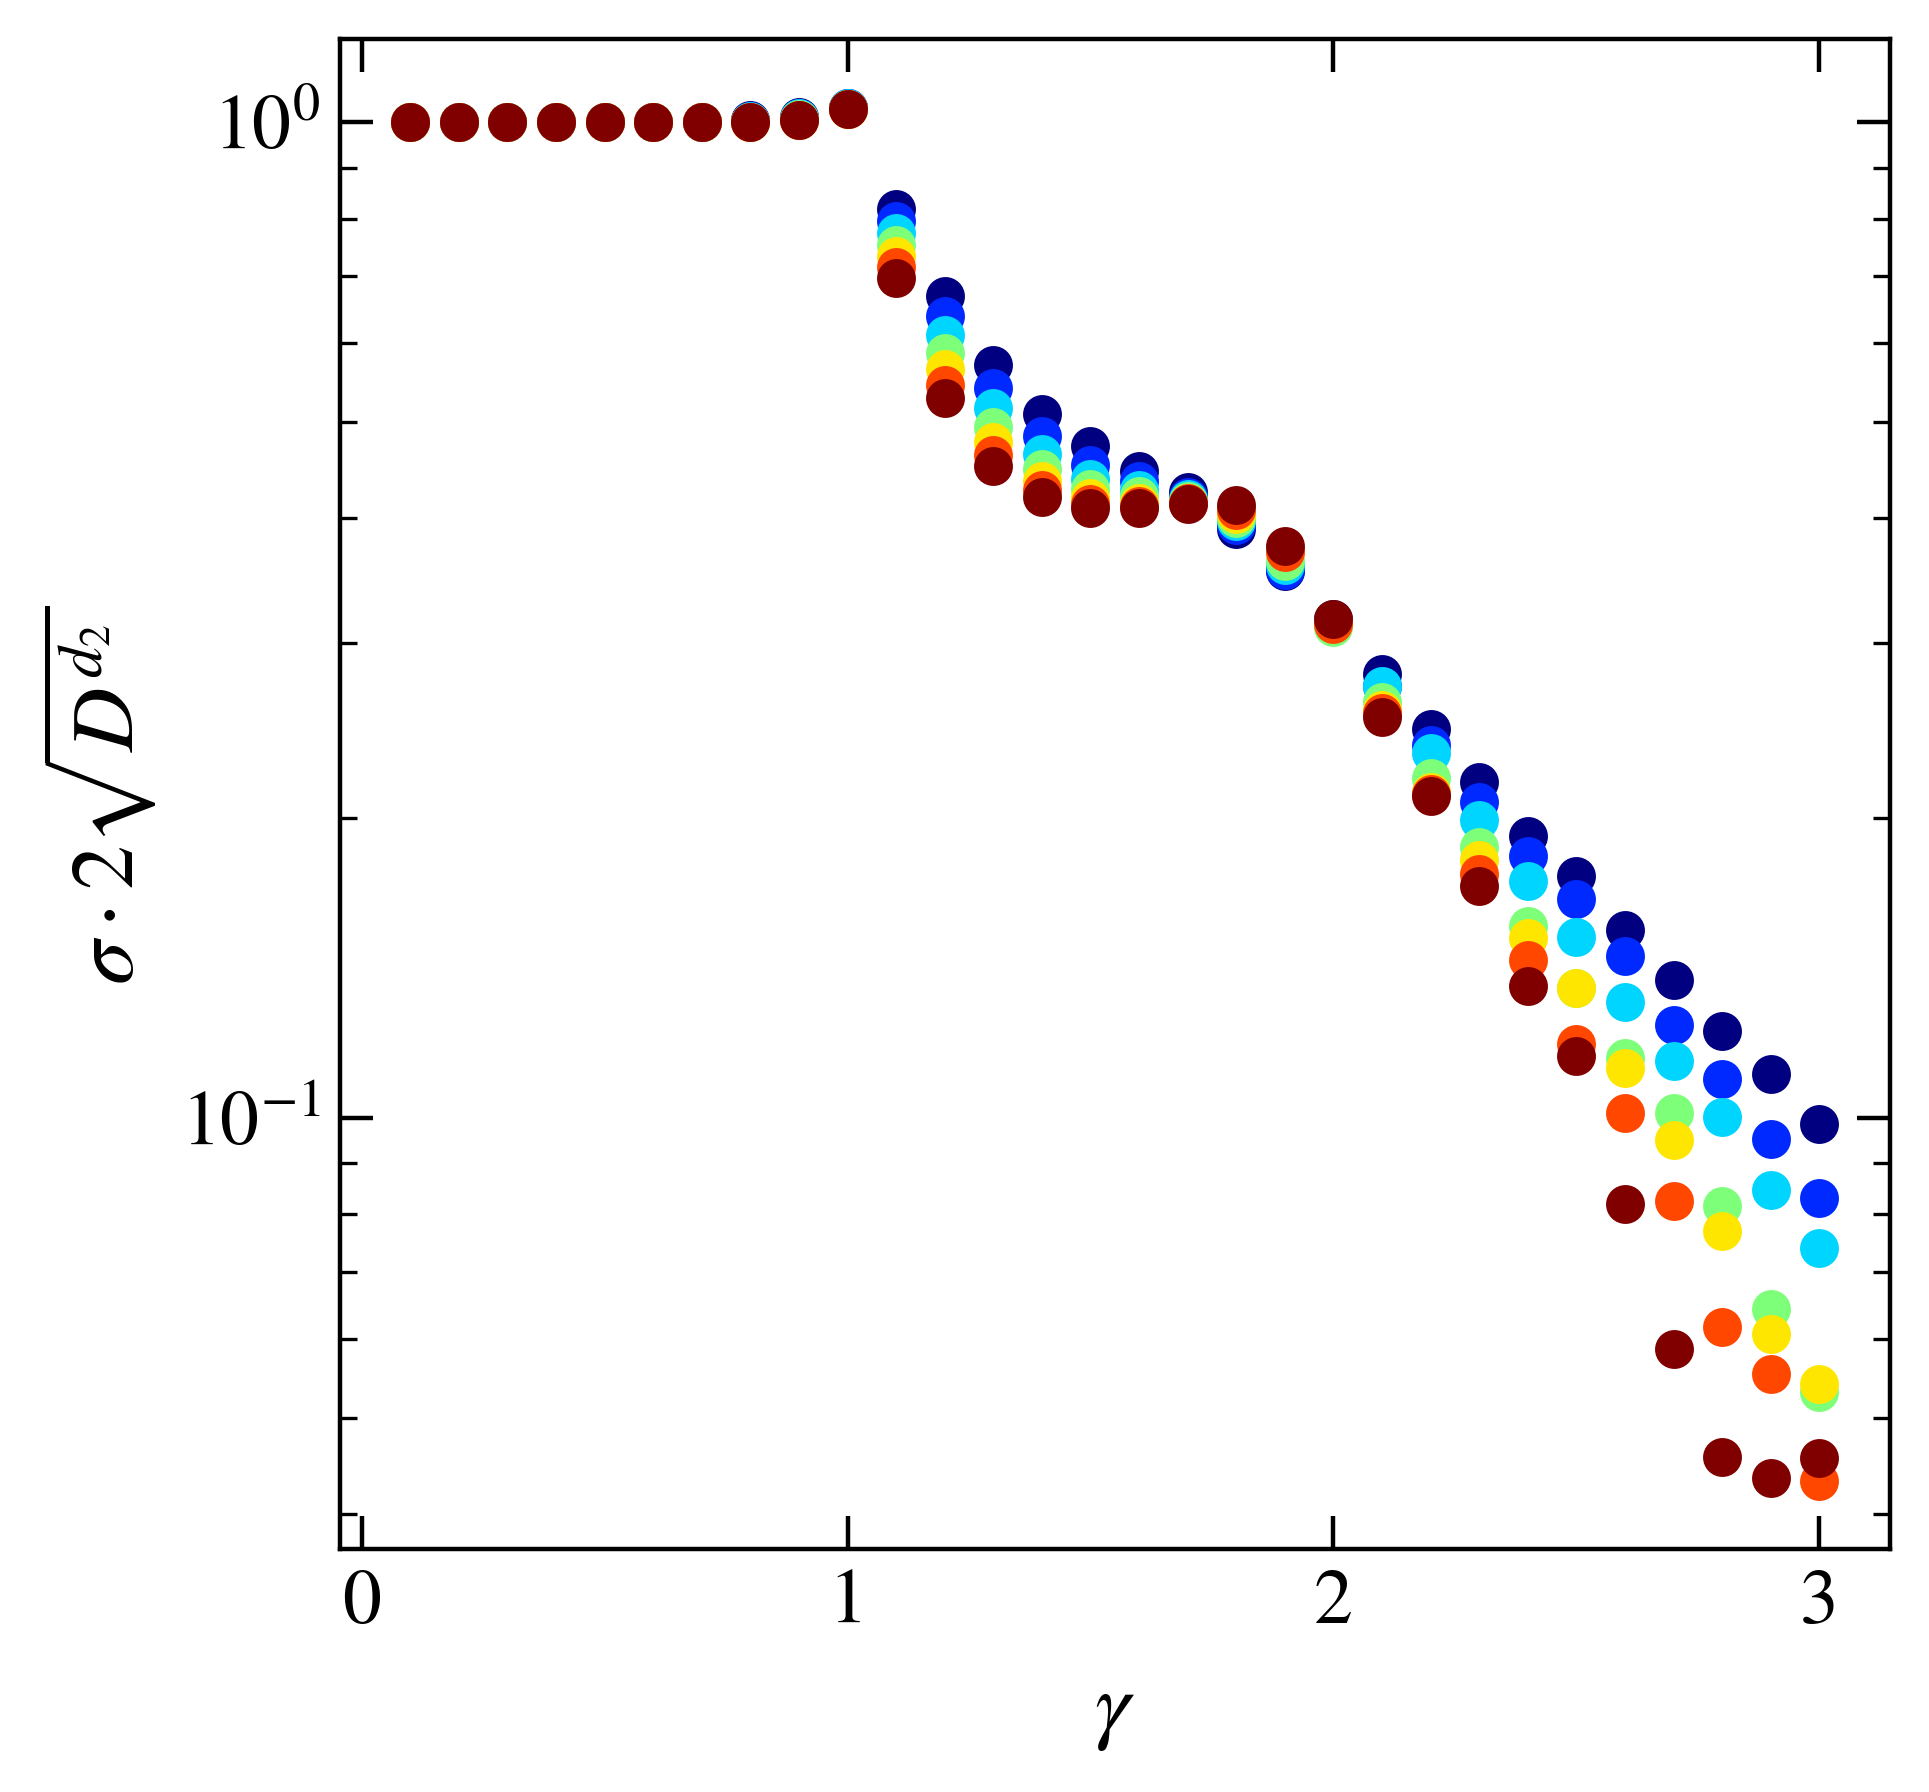

In [1657]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 12
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(8, 15, 1)
gammas = np.arange(2., 2.9, 0.1)

DIM = 1
gammas = np.arange(0.1, 3.1, 0.1)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 400, sharex=False, sharey=False)

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes)))
s_m.set_array([])


for L in sizes:
    col = s_m.to_rgba(L)
    vari = np.zeros(gammas.shape);gauss.fill(np.nan)
    for iig, gx in enumerate(gammas):
        d2 = 1 if gx <= 1 else 2-gx
        # if gx > 2: d2 = gx-2
        dim = 2**L
        name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                try:
                    vari[iig] = np.sqrt(np.array(file.get('LTVALS/L=%d/second_moment'%L)) - np.array(file.get('LTVALS/L=%d/first_moment'%L))**2) * 2 * np.sqrt(1 + dim**d2)
                except TypeError:
                    aadsada=1
        else:
            print(name_out)
    axis.scatter(gammas, vari, color=col)

fig_help.set_plot_elements(axis, ylabel=r"$\sigma\cdot 2\sqrt{D^{d_2}}$", xlabel=r"$\gamma$", font_size=14, set_legend=0, xscale='linear', yscale='log')